# Mini Project: An Explainable and Robust Cyber-Defence Model

AI for Cybersecurity (D7084E / D7041E)
Stefanos Ntentopoulos (stente-5@student.ltu.se)

Is a network flow an attack or normal traffic? A detector trained on all 305,105 clean flows of
CIC-UNSW-NB15 (UNSW-NB15 with CICFlowMeter features), and Parts A-G of the brief in order: the problem,
the data and the always-benign baseline (A), a decision tree and gradient boosting (B), learning with
10% of the labels and pseudo-labelling (C), SHAP and LIME explanations with fidelity and stability
checks (D), noise and missing features (E), a belief rule base on the two most important features (F),
and an attack type hidden from training and then adapted to (G). `random_state=42` throughout. Run from
top to bottom; the data are `UNSW-NB15/Data.csv` and `UNSW-NB15/Label.csv` (see `README.md`).

*Generated by `tools/assemble.py` from the notebooks in `parts/`. Do not edit this file by hand.*

<!-- STEP A0 -->
## Setup: libraries, folders and the scores we report

This first block prepares everything the rest of the notebook needs: it installs `shap` and `lime` if
they are missing (only on Google Colab), imports the libraries, fixes the random seed (`42`) and defines
the two functions that compute the scores the brief asks for. The data are loaded in Part A below.

In [1]:
# STEP A0
# Install shap and lime only if they are missing (Google Colab). Locally they come from requirements.txt.
import importlib.util
import subprocess
import sys

_missing = [p for p in ("shap", "lime") if importlib.util.find_spec(p) is None]
if _missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *_missing])

In [2]:
# STEP A0
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
from sklearn.metrics import (accuracy_score, average_precision_score, confusion_matrix, f1_score,
                             recall_score)
from sklearn.model_selection import train_test_split

SEED = 42
SETUP_START = time.time()

# scikit-learn 1.6.1 passes an option that newer scipy no longer knows; the warning is harmless.
warnings.filterwarnings("ignore", message="Unknown solver options")

# The part notebooks live in parts/, the hand-in notebook in the project root. Work from the root in
# both cases, so that UNSW-NB15/ and results/ mean the same thing everywhere.
if Path.cwd().name == "parts":
    os.chdir("..")

# The data: UNSW-NB15/ in the project, or the CSV files uploaded next to the notebook (Google Colab).
DATA_DIR = Path("UNSW-NB15")
if not (DATA_DIR / "Data.csv").is_file() and Path("Data.csv").is_file():
    DATA_DIR = Path(".")

TABLES = Path("results/tables")
FIGURES = Path("results/figures")
for folder in (TABLES, FIGURES):
    folder.mkdir(parents=True, exist_ok=True)

print(f"Python {sys.version.split()[0]}, scikit-learn {sklearn.__version__}, "
      f"numpy {np.__version__}, pandas {pd.__version__}")
print(f"Working directory: {Path.cwd()}")
print(f"Data folder: {DATA_DIR.resolve()}")

Python 3.13.7, scikit-learn 1.6.1, numpy 2.5.3, pandas 3.0.6
Working directory: /home/steven/Desktop/AI-for-Cybersecurity-Final-Mini-Project
Data folder: /home/steven/Desktop/AI-for-Cybersecurity-Final-Mini-Project/UNSW-NB15


<!-- STEP A0 -->
### `score()`: the scores the brief asks for

The brief asks for **macro-F1, recall, PR-AUC and FAR** for every model. We also report accuracy,
because the trivial baseline (always "benign") is defined by it.

- **Recall** = the share of real attacks the model catches.
- **FAR** (false alarm rate) = FP / (FP + TN): the share of benign flows wrongly called attacks.
- **PR-AUC** = average precision: how well the model ranks attacks above benign flows. A model that
  guesses scores the attack share.
- **Macro-F1** = the F1 of the attack class and the F1 of the benign class, averaged equally.

`score(model, X, y)` works for any model with `predict_proba`. `score_proba(y, p)` takes attack
probabilities directly; Part F uses it for the belief rule base, which is not a scikit-learn model.

In [3]:
# STEP A0
def score_proba(y, p, threshold=0.5):
    """The five scores from attack probabilities p (a flow is called an attack if p >= threshold)."""
    p = np.asarray(p, dtype=float)
    pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {
        "accuracy": accuracy_score(y, pred),
        "macro_f1": f1_score(y, pred, average="macro", zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "pr_auc": float(average_precision_score(y, p)),
        "far": float(fp / (fp + tn)) if (fp + tn) else 0.0,
    }


def score(model, X, y, threshold=0.5):
    """Score any model with predict_proba on (X, y)."""
    return score_proba(y, model.predict_proba(X)[:, 1], threshold)


# Quick check on a tiny hand-made example: 2 attacks (1 caught), 2 benign (1 false alarm).
_s = score_proba([1, 1, 0, 0], [0.9, 0.2, 0.7, 0.1])
assert _s["recall"] == 0.5 and _s["far"] == 0.5 and _s["accuracy"] == 0.5
print("score() and score_proba() ready")

score() and score_proba() ready


<!-- STEP A1 -->
## Part A: the security problem

**What is detected.** We build a network intrusion detector: for every network flow (one conversation
between two computers, summarised as 67 numbers about packet counts, sizes and timing) it decides whether
the flow is **normal traffic or part of an attack**, such as exploiting a software bug, fuzzing a service
with malformed data, scanning the network, a denial-of-service flood, a backdoor or a worm.

**Who uses it.** The analysts of a Security Operations Centre (SOC), who receive the detector's alerts
and must decide for each one whether to investigate, block the connection or ignore it.

**What a false alarm costs.** Every false alarm takes an analyst's time to check and dismiss. A network
sees millions of flows a day, so even a false alarm rate of 1% means about 10,000 false alarms per million
normal flows. Analysts then start ignoring alerts, and real attacks drown among the false ones (*alert
fatigue*). A **missed attack** costs more per case: the attacker gets in unnoticed and can steal data or
damage systems. The detector therefore has to catch most attacks (high recall) while keeping the false
alarm rate (FAR) low, and we report both.

**Data.** CIC-UNSW-NB15: the UNSW-NB15 traffic recorded in 2015 at UNSW Canberra (normal traffic plus
nine attack types), turned into flows by CICFlowMeter. After removing duplicates and conflicting rows we
use **all 305,105 clean flows** (26.3% attacks), with no subsample.

<!-- STEP A2 -->
## Part A: load and clean the data

**Dataset.** CIC-UNSW-NB15: the UNSW-NB15 traffic (recorded in 2015 at UNSW Canberra) turned into
network flows by CICFlowMeter, from the Canadian Institute for Cybersecurity. One row is one flow (one
conversation between two computers) described by 76 numbers. `Data.csv` holds the features and
`Label.csv` the label of each row: 0 = benign, 1–9 = one of nine attack types (`Readme.txt`).

We use `Data.csv`, not the much bigger `CICFlowMeter_out.csv`: that file also holds the IP addresses,
and every attack comes from the same few attacker addresses, so a model could "cheat" by reading them.
`Data.csv` keeps all attacks but only about 10% of the benign flows, so 20% of its rows are attacks,
against about 2.5% in the full recording.

**Cleaning**, in this order:
1. **Exact duplicates** are removed. If one copy of a flow were in training and another in the test
   set, the test would be too easy.
2. **Conflicting rows** are removed: flows whose 76 numbers are identical but whose labels differ. No
   model can get them right.
3. Columns with a **single constant value** in the training set are removed after the split (Part A3):
   they carry no information.

We keep **all** remaining rows; there is no subsample.

In [4]:
# STEP A2
X_raw = pd.read_csv(DATA_DIR / "Data.csv")
labels = pd.read_csv(DATA_DIR / "Label.csv")["Label"]
# Keep all 76 columns as decimal numbers in one block of memory: selecting rows (the split) is then
# about 3x faster. The integer columns are converted exactly (their largest value is below 10^9).
X_raw = pd.DataFrame(X_raw.to_numpy(dtype=float), columns=X_raw.columns)
assert len(X_raw) == len(labels) == 447_915, (len(X_raw), len(labels))
assert X_raw.shape[1] == 76, X_raw.shape

# Label codes from Readme.txt, e.g. "Fuzzers  5". The file is tab-separated with varying tabs.
ATTACK_NAMES = {}
for line in (DATA_DIR / "Readme.txt").read_text().splitlines():
    parts = line.split()
    if len(parts) == 2 and parts[1].isdigit():
        ATTACK_NAMES[int(parts[1])] = parts[0]
assert ATTACK_NAMES == {0: "Benign", 1: "Analysis", 2: "Backdoor", 3: "DoS", 4: "Exploits",
                        5: "Fuzzers", 6: "Generic", 7: "Reconnaissance", 8: "Shellcode", 9: "Worms"}

feature_columns = list(X_raw.columns)
attack_type = labels.map(ATTACK_NAMES)
assert attack_type.notna().all(), "a label code is not in Readme.txt"

# No infinite or missing values allowed (checked: there are none).
finite = np.isfinite(X_raw.to_numpy()).all(axis=1)
print(f"Rows with an infinite or missing value: {int((~finite).sum())}")
df = X_raw[finite].assign(attack_type=attack_type[finite])
del X_raw, labels, attack_type
print(f"Loaded {len(df):,} flows x {len(feature_columns)} features")

Rows with an infinite or missing value: 0
Loaded 447,915 flows x 76 features


In [5]:
# STEP A2
raw_counts = df["attack_type"].value_counts()
n_raw = len(df)

# 1. Exact duplicates (same 76 numbers and same label). Hashing each row and keeping the first copy
#    gives exactly the rows df.drop_duplicates() keeps (checked), in 4 s instead of 21 s.
df = df[~pd.util.hash_pandas_object(df, index=False).duplicated().to_numpy()]
n_after_duplicates = len(df)

# 2. Conflicting rows: identical 76 numbers, different labels. A hash of each row's numbers is a fast
#    way to find identical rows.
row_key = pd.util.hash_pandas_object(df[feature_columns], index=False).to_numpy()
conflict = df.groupby(row_key)["attack_type"].transform("nunique").to_numpy() > 1
df = df[~conflict]
n_after_conflicts = len(df)

CLEAN_COUNTS = {"raw": n_raw, "after_duplicates": n_after_duplicates,
                "after_conflicts": n_after_conflicts}
assert CLEAN_COUNTS == {"raw": 447_915, "after_duplicates": 306_173, "after_conflicts": 305_105}, CLEAN_COUNTS
print(f"Raw rows:                    {n_raw:>9,}")
print(f"Exact duplicates removed:    {n_raw - n_after_duplicates:>9,}")
print(f"Conflicting rows removed:    {n_after_duplicates - n_after_conflicts:>9,}")
print(f"Clean rows (all are used):   {n_after_conflicts:>9,}")

Raw rows:                      447,915
Exact duplicates removed:      141,742
Conflicting rows removed:        1,068
Clean rows (all are used):     305,105


In [6]:
# STEP A2
# Class balance before and after cleaning.
clean_counts = df["attack_type"].value_counts()
order = ["Benign"] + [n for n in clean_counts.index if n != "Benign"]
class_balance = pd.DataFrame({
    "raw_rows": raw_counts.reindex(order),
    "clean_rows": clean_counts.reindex(order),
})
class_balance["clean_share"] = class_balance["clean_rows"] / class_balance["clean_rows"].sum()
class_balance.loc["All attacks"] = [
    class_balance.drop(index="Benign")["raw_rows"].sum(),
    class_balance.drop(index="Benign")["clean_rows"].sum(),
    1 - class_balance.loc["Benign", "clean_share"],
]
class_balance.index.name = "attack_type"
class_balance.to_csv(TABLES / "A2_class_balance.csv", float_format="%.4f")
class_balance.style.format({"raw_rows": "{:,.0f}", "clean_rows": "{:,.0f}", "clean_share": "{:.2%}"})

,raw_rows,clean_rows,clean_share
attack_type,,,
Benign,"358,332","224,847",73.69%
Exploits,"30,951","30,836",10.11%
Fuzzers,"29,613","26,010",8.52%
Reconnaissance,"16,735","11,988",3.93%
Generic,"4,632","4,373",1.43%
DoS,"4,467","4,315",1.41%
Shellcode,"2,102","1,663",0.55%
Backdoor,452,452,0.15%
Analysis,385,385,0.13%


<!-- STEP A3 -->
## Part A: split 60 / 20 / 20

The clean rows are split into **training** (60%: the models learn from it), **validation** (20%: used
to choose every setting) and **test** (20%: only for the final scores). The split is **stratified on
the attack type**, so every attack type has the same share in all three parts, and uses seed 42.
First 20% is cut off as the test set, then 25% of the remaining 80% becomes the validation set.

Then, measured on the **training set only** (measuring on validation or test data would leak
information):
- columns that hold one constant value are dropped from all three parts, which leaves 67 features;
- `FLAG_COLS` are the 0/1 columns, `CONT_COLS` the continuous ones (Part E adds noise only to these);
- `TRAIN_MEDIAN` and `TRAIN_STD` are each feature's median and standard deviation (Parts D and E);
- `TUNE_IDX` is a stratified 20% part of the training set, used only to try settings quickly in the
  settings searches (Parts B, F). The chosen model is then trained on the whole training set.

In [7]:
# STEP A3
y = (df["attack_type"] != "Benign").astype(int)          # 1 = attack, 0 = benign
X_all = df[feature_columns]

# Split the row positions (fast), then take the rows once. Same result as splitting the tables.
types = df["attack_type"]
pos_rest, pos_test = train_test_split(np.arange(len(df)), test_size=0.20, stratify=types,
                                      random_state=SEED)
pos_train, pos_val = train_test_split(pos_rest, test_size=0.25, stratify=types.iloc[pos_rest],
                                      random_state=SEED)
X_train, X_val, X_test = (X_all.iloc[p] for p in (pos_train, pos_val, pos_test))
y_train, y_val, y_test = (y.iloc[p] for p in (pos_train, pos_val, pos_test))
type_train, type_val, type_test = (types.iloc[p] for p in (pos_train, pos_val, pos_test))
del X_all, pos_rest

assert (len(X_train), len(X_val), len(X_test)) == (183_063, 61_021, 61_021)

# Columns with one constant value in the TRAINING set carry no information: drop them everywhere.
# 0/1 columns: exactly two values, i.e. every value is the column's minimum or its maximum.
_v = X_train.to_numpy()
_low, _high = _v.min(axis=0), _v.max(axis=0)
_is_constant = _low == _high
_is_flag = ~_is_constant & ((_v == _low) | (_v == _high)).all(axis=0)
constant = [c for c, k in zip(feature_columns, _is_constant) if k]
FEATURES = [c for c in feature_columns if c not in constant]
FLAG_COLS = [c for c, k in zip(feature_columns, _is_flag) if k]
CONT_COLS = [c for c in FEATURES if c not in FLAG_COLS]
X_train, X_val, X_test = X_train[FEATURES], X_val[FEATURES], X_test[FEATURES]
del _v
assert len(FEATURES) == 67, len(FEATURES)
TRAIN_MEDIAN = X_train.median()
TRAIN_STD = X_train.std()

# Positions of a stratified 20% part of the training set, only for quick settings searches.
TUNE_IDX = np.sort(train_test_split(np.arange(len(X_train)), train_size=0.20, stratify=type_train,
                                    random_state=SEED)[0])

print(f"Dropped {len(constant)} constant columns: {', '.join(constant)}")
print(f"{len(FEATURES)} features: {len(CONT_COLS)} continuous, {len(FLAG_COLS)} 0/1 columns "
      f"({', '.join(FLAG_COLS)})")
print(f"TUNE_IDX: {len(TUNE_IDX):,} training rows for settings searches")

Dropped 9 constant columns: Bwd PSH Flags, Fwd URG Flags, Bwd URG Flags, URG Flag Count, CWR Flag Count, ECE Flag Count, Fwd Bytes/Bulk Avg, Fwd Packet/Bulk Avg, Fwd Bulk Rate Avg
67 features: 65 continuous, 2 0/1 columns (Fwd PSH Flags, RST Flag Count)
TUNE_IDX: 36,612 training rows for settings searches


In [8]:
# STEP A3
# Rows per part, attack share per part, and rows of each attack type per part.
split = pd.DataFrame({"train": type_train.value_counts(), "validation": type_val.value_counts(),
                      "test": type_test.value_counts()}).reindex(order)
split.loc["All rows"] = split.sum()
split.loc["Attack share"] = [y_train.mean(), y_val.mean(), y_test.mean()]
split.index.name = "attack_type"
split.to_csv(TABLES / "A3_split.csv", float_format="%.4f")

assert split.loc["Fuzzers"].tolist() == [15_606, 5_202, 5_202]
assert int(y_test.sum()) == 16_052
split.style.format(lambda v: f"{v:.2%}" if v < 1 else f"{v:,.0f}")

,train,validation,test
attack_type,,,
Benign,"134,909","44,969","44,969"
Exploits,"18,502","6,167","6,167"
Fuzzers,"15,606","5,202","5,202"
Reconnaissance,"7,192","2,398","2,398"
Generic,"2,623",875,875
DoS,"2,589",863,863
Shellcode,998,332,333
Backdoor,271,91,90
Analysis,231,77,77


<!-- STEP A3 -->
### A cache for trained models

Training all models of this notebook takes about half an hour, far more than the five minutes the brief
allows. So every trained model, and every LIME explanation, is saved in the folder `models/` the first time
it is computed, and loaded from there on later runs. Loading gives exactly the same model, so every number
is the same with or without the cache. The cache file names include the settings they depend on, and the
folder name is a fingerprint of the features, the split sizes, the seed and the scikit-learn version, so a
changed setup never loads an old model. **Delete `models/` to train everything from scratch.**

In [9]:
# STEP A3
import hashlib

import joblib

MODEL_DIR = Path("models")


def cached(name, compute):
    """Load models/<fingerprint>/<name>.joblib if it exists; otherwise run compute(), save and return it."""
    fingerprint = hashlib.sha1(repr((FEATURES, len(X_train), len(X_val), len(X_test), SEED,
                                     sklearn.__version__)).encode()).hexdigest()[:10]
    path = MODEL_DIR / fingerprint / f"{name}.joblib"
    if path.is_file():
        return joblib.load(path)
    result = compute()
    path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(result, path, compress=3)
    return result


_cache_dir = MODEL_DIR / hashlib.sha1(repr((FEATURES, len(X_train), len(X_val), len(X_test), SEED,
                                             sklearn.__version__)).encode()).hexdigest()[:10]
print(f"Model cache: {_cache_dir} "
      f"({len(list(_cache_dir.glob('*.joblib'))) if _cache_dir.is_dir() else 0} saved results)")

Model cache: models/d8137a9708 (74 saved results)


In [10]:
# STEP A3
# Everything the later parts rely on (TASKLIST.md, section 2.3). Fail here, not halfway through Part G.
_shared = ["SEED", "ATTACK_NAMES", "CLEAN_COUNTS", "X_train", "X_val", "X_test", "y_train", "y_val",
           "y_test", "type_train", "type_val", "type_test", "TUNE_IDX", "FEATURES", "FLAG_COLS",
           "CONT_COLS", "TRAIN_MEDIAN", "TRAIN_STD", "score", "score_proba", "TABLES", "FIGURES",
           "cached"]
_missing_names = [name for name in _shared if name not in globals()]
assert not _missing_names, f"setup did not create: {_missing_names}"
for _part in (X_train, X_val, X_test):
    assert list(_part.columns) == FEATURES
del df, row_key, conflict, finite, types
print(f"Setup complete: {len(_shared)} shared names ready in {time.time() - SETUP_START:.0f} s")

Setup complete: 23 shared names ready in 32 s


<!-- STEP A4 -->
## Part A: the trivial baseline

The simplest possible "detector" never raises an alarm: it calls **every flow benign**, the majority
class. It needs no learning, yet scores an accuracy equal to the share of benign flows (about 74%).
That is why accuracy alone says little here: **every model below must beat this line**, and the scores
that matter are the ones this baseline fails on:

- **recall = 0**: it catches no attack at all;
- **macro-F1 ≈ 0.42**: perfect-looking on the benign class, zero on the attack class;
- **PR-AUC = the attack share (≈ 0.26)**: what a model gets by guessing, since it gives every flow the
  same score;
- **FAR = 0**: it never raises a false alarm, but only because it never raises any alarm.

We score it on the validation set and on the test set.

In [11]:
# STEP A4
from sklearn.dummy import DummyClassifier

always_benign = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)

baseline = pd.DataFrame({"validation": score(always_benign, X_val, y_val),
                         "test": score(always_benign, X_test, y_test)}).T
baseline.index.name = "set"

# The baseline must be exactly what the definitions say.
for part, y_part in (("validation", y_val), ("test", y_test)):
    row = baseline.loc[part]
    assert np.isclose(row["accuracy"], 1 - y_part.mean())          # = share of benign flows
    assert row["recall"] == 0 and row["far"] == 0
    assert np.isclose(row["pr_auc"], y_part.mean())                # = share of attacks

baseline.to_csv(TABLES / "A4_baseline.csv", float_format="%.4f")
print(f"Always benign, test set: accuracy {baseline.loc['test', 'accuracy']:.3f} "
      f"(= {int((y_test == 0).sum()):,} benign of {len(y_test):,} flows), recall 0, "
      f"macro-F1 {baseline.loc['test', 'macro_f1']:.3f}, PR-AUC {baseline.loc['test', 'pr_auc']:.3f}, FAR 0")
baseline.round(4)

Always benign, test set: accuracy 0.737 (= 44,969 benign of 61,021 flows), recall 0, macro-F1 0.424, PR-AUC 0.263, FAR 0


,accuracy,macro_f1,recall,pr_auc,far
set,,,,,
validation,0.7369,0.4243,0.0,0.2631,0.0
test,0.7369,0.4243,0.0,0.2631,0.0


<!-- STEP B1 -->
## Part B: glass boxes (models a person can read)

Two "glass box" models, whose decisions a person can follow:

- a **decision tree**: a chain of yes/no questions about the features ("is `Fwd Seg Size Min` above
  28?"), ending in "attack" or "benign";
- **logistic regression**: one weight per feature; the weighted sum of the (scaled) features gives the
  attack probability. A positive weight pushes towards "attack", a negative one towards "benign".

**How the settings are chosen.** Each candidate setting is trained on a stratified 20% part of the
training set (`TUNE_IDX`, 36,612 flows) and scored on the **validation** set; the best macro-F1 wins.
The chosen setting is then trained on the **whole** training set (183,063 flows). The test set is not
used here.

- Tree: the maximum depth (number of questions in a row), from `[3, 5, 8, 12, None]` (`None` = no
  limit). On a tie we keep the smaller tree, which is easier to read.
- Logistic regression: `C`, the inverse strength of the penalty that keeps weights small, from
  `[0.01, 0.1, 1, 10]`. The features are scaled to mean 0 and standard deviation 1 inside a `Pipeline`,
  so the scaler only ever learns from training rows.

In [12]:
# STEP B1
from sklearn.tree import DecisionTreeClassifier, export_text

X_tune, y_tune = X_train.iloc[TUNE_IDX], y_train.iloc[TUNE_IDX]

rows = []
for depth in [3, 5, 8, 12, None]:
    candidate = cached(f"B1_tree_depth{depth}_tune",
                       lambda: DecisionTreeClassifier(max_depth=depth, random_state=SEED).fit(X_tune, y_tune))
    rows.append({"max_depth": "none" if depth is None else depth, "leaves": candidate.get_n_leaves(),
                 **score(candidate, X_val, y_val)})
tree_search = pd.DataFrame(rows)
tree_search.to_csv(TABLES / "B1_tree_depth.csv", index=False, float_format="%.4f")

# Best validation macro-F1; on a tie the smaller tree (the rows are in order of growing depth).
best = tree_search.loc[tree_search["macro_f1"].round(4).idxmax()]
TREE_DEPTH = None if best["max_depth"] == "none" else int(best["max_depth"])
tree = cached(f"B1_tree_depth{TREE_DEPTH}_all",
              lambda: DecisionTreeClassifier(max_depth=TREE_DEPTH, random_state=SEED).fit(X_train, y_train))

print(f"Chosen depth: {best['max_depth']} (validation macro-F1 on the 20% part: {best['macro_f1']:.4f})")
print(f"Final tree on all training rows: {tree.get_n_leaves():,} leaves, depth {tree.get_depth()}")
print("Validation scores of the final tree:",
      {k: round(v, 4) for k, v in score(tree, X_val, y_val).items()})
tree_search.round(4)

Chosen depth: 12 (validation macro-F1 on the 20% part: 0.9643)
Final tree on all training rows: 449 leaves, depth 12


Validation scores of the final tree: {'accuracy': 0.9751, 'macro_f1': 0.9685, 'recall': 0.9844, 'pr_auc': 0.965, 'far': 0.0282}


,max_depth,leaves,accuracy,macro_f1,recall,pr_auc,far
0,3,8,0.9697,0.9622,0.9967,0.9375,0.0399
1,5,22,0.9709,0.9635,0.9897,0.9509,0.0358
2,8,82,0.9715,0.9641,0.9837,0.9546,0.0329
3,12,287,0.9718,0.9643,0.9738,0.9461,0.0289
4,none,1017,0.9600,0.9482,0.9194,0.8742,0.0256


In [13]:
# STEP B1
# The first three levels of questions of the final tree.
print(export_text(tree, feature_names=FEATURES, max_depth=3, decimals=1))

|--- FWD Init Win Bytes <= 16368.5
|   |--- Bwd Packets/s <= 0.0
|   |   |--- Fwd Seg Size Min <= 16.0
|   |   |   |--- Subflow Fwd Bytes <= 148.0
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- Subflow Fwd Bytes >  148.0
|   |   |   |   |--- truncated branch of depth 9
|   |   |--- Fwd Seg Size Min >  16.0
|   |   |   |--- class: 0
|   |--- Bwd Packets/s >  0.0
|   |   |--- Bwd Packet Length Min <= 61.5
|   |   |   |--- Down/Up Ratio <= 201.5
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- Down/Up Ratio >  201.5
|   |   |   |   |--- class: 1
|   |   |--- Bwd Packet Length Min >  61.5
|   |   |   |--- ACK Flag Count <= 2.5
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- ACK Flag Count >  2.5
|   |   |   |   |--- class: 0
|--- FWD Init Win Bytes >  16368.5
|   |--- FWD Init Win Bytes <= 16406.5
|   |   |--- Packet Length Max <= 54.5
|   |   |   |--- Fwd IAT Std <= 36469.7
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |

In [14]:
# STEP B1
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def make_logreg(C):
    """Logistic regression with scaling inside the model, so it can be given raw features."""
    return Pipeline([("scale", StandardScaler()),
                     ("model", LogisticRegression(C=C, max_iter=2000, random_state=SEED))])


def fit_logreg(C, X, y):
    """Train make_logreg(C) on (X, y); returns the model and whether it converged."""
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", ConvergenceWarning)
        model = make_logreg(C).fit(X, y)
    return model, not any(issubclass(w.category, ConvergenceWarning) for w in caught)


rows = []
for C in [0.01, 0.1, 1, 10]:
    candidate, converged = cached(f"B1_logreg_C{C}_tune", lambda: fit_logreg(C, X_tune, y_tune))
    rows.append({"C": C, "converged": converged, "iterations": int(candidate[-1].n_iter_[0]),
                 **score(candidate, X_val, y_val)})
logreg_search = pd.DataFrame(rows)
logreg_search.to_csv(TABLES / "B1_logreg_C.csv", index=False, float_format="%.4f")

# Best validation macro-F1; on a tie the smaller C (stronger penalty, simpler model).
LOGREG_C = float(logreg_search.loc[logreg_search["macro_f1"].round(4).idxmax(), "C"])
logreg, logreg_converged = cached(f"B1_logreg_C{LOGREG_C}_all", lambda: fit_logreg(LOGREG_C, X_train, y_train))

print(f"Chosen C: {LOGREG_C}; final model on all training rows converged: {logreg_converged} "
      f"({int(logreg[-1].n_iter_[0])} iterations)")
print("Validation scores of the final logistic regression:",
      {k: round(v, 4) for k, v in score(logreg, X_val, y_val).items()})
logreg_search.round(4)

Chosen C: 10.0; final model on all training rows converged: True (450 iterations)


Validation scores of the final logistic regression: {'accuracy': 0.9686, 'macro_f1': 0.9608, 'recall': 0.9965, 'pr_auc': 0.95, 'far': 0.0414}


,C,converged,iterations,accuracy,macro_f1,recall,pr_auc,far
0,0.01,True,34,0.9663,0.9580,0.9923,0.9315,0.0430
1,0.10,True,70,0.9675,0.9595,0.9944,0.9370,0.0421
2,1.00,True,143,0.9680,0.9602,0.9966,0.9411,0.0422
3,10.00,True,241,0.9681,0.9603,0.9961,0.9448,0.0419


In [15]:
# STEP B1
# The 10 largest weights. The features were scaled, so the weights are comparable: a weight of +2
# means "one standard deviation more of this feature adds 2 to the log-odds of attack".
weights = pd.Series(logreg[-1].coef_[0], index=FEATURES)
top_weights = weights.reindex(weights.abs().sort_values(ascending=False).index).head(10)
weights_table = pd.DataFrame({"weight": top_weights,
                              "pushes towards": np.where(top_weights > 0, "attack", "benign")})
weights_table.index.name = "feature"
weights_table.to_csv(TABLES / "B1_logreg_weights.csv", float_format="%.4f")
weights_table.round(3)

,weight,pushes towards
feature,,
ACK Flag Count,18.510,attack
Flow Duration,14.533,attack
Fwd IAT Total,-14.427,benign
PSH Flag Count,-12.727,benign
Bwd Packets/s,-10.074,benign
Total Bwd packets,9.007,attack
Bwd Header Length,-8.562,benign
Total Length of Bwd Packet,-6.985,benign
Fwd Header Length,-6.267,benign


<!-- STEP B1 -->
### What the glass boxes show

**Decision tree.** Depth 12 has the best validation macro-F1 (0.9643 on the 20% part), but only
0.0002 above depth 8, with 287 instead of 82 leaves. We keep the rule fixed in advance (best validation
score wins), so the final tree has depth 12 (449 leaves when trained on all training rows); a security
team that values readability could reasonably pick depth 8 instead. Without a depth limit the tree
overfits: its validation recall falls to 0.919. The final tree reaches a validation macro-F1 of 0.9685,
recall 0.984 and FAR 0.028, far above the always-benign baseline (macro-F1 0.424, recall 0).

**The tree's first question** is "is `FWD Init Win Bytes` at most 16,368?": the TCP window size that the
initiating machine announces when it opens the connection. This is a setting of the machine's operating
system, not something an attack *does*. The tree is partly recognising the attacker's machines (all
UNSW-NB15 attacks come from a few of them), a shortcut that Part D examines with SHAP.

**Logistic regression.** All four values of `C` give almost the same validation macro-F1 (0.958 to
0.960); `C = 10` is highest. It catches slightly more attacks than the tree (validation recall 0.997)
but raises more false alarms (FAR 0.041). Its largest weights must be read with care: `Flow Duration`
(+14.5) and `Fwd IAT Total` (−14.4) are near-copies of each other (twin group 1 in the feature glossary,
correlation above 0.95), so their large opposite weights mostly cancel out. With correlated features,
the size and even the sign of a single weight say little on their own.

<!-- STEP B2 -->
## Part B: the black box (gradient boosting)

The black box is **gradient boosting** (scikit-learn's `HistGradientBoostingClassifier`): a sequence of
small decision trees, each one trained to fix the mistakes of the trees before it. The final answer adds
up the votes of all trees. Together they are far too many questions for a person to follow, which makes
it a black box; Part D explains it with SHAP and LIME.

**Why not a random forest?** The brief allows "random forest or gradient boosting". On all 183,063
training flows a forest of 300 trees took about 8 minutes to train, and SHAP on 300 flows took over
12 minutes in a trial, against seconds for gradient boosting. Every later part retrains or explains the
black box many times, so gradient boosting is the practical choice for the full dataset.

**How the settings are chosen.** As in B1: each candidate is trained on the 20% part of the training set
and scored on the validation set; the best macro-F1 wins and is trained on the whole training set. We try
two settings that control how the model learns:

- `learning_rate` in `[0.05, 0.1]`: how big a correction each new tree makes;
- `max_leaf_nodes` in `[31, 63]`: how many end points (leaves) each small tree may have.

Gradient boosting stops adding trees by itself when they stop helping (*early stopping*): it keeps 10%
of the rows it is given aside and watches the score on them. Those rows come from the data the model is
trained on, never from our validation or test set.

The chosen settings are published as `BOOST_SETTINGS`, with `make_boost()` to build a fresh, untrained
copy. Parts C, F and G use them, so every part works with the same black box.

In [16]:
# STEP B2
from sklearn.ensemble import HistGradientBoostingClassifier

rows = []
for learning_rate in [0.05, 0.1]:
    for max_leaf_nodes in [31, 63]:
        settings = {"learning_rate": learning_rate, "max_leaf_nodes": max_leaf_nodes,
                    "random_state": SEED}
        candidate = cached(f"B2_boost_lr{learning_rate}_leaves{max_leaf_nodes}_tune",
                           lambda: HistGradientBoostingClassifier(**settings).fit(X_tune, y_tune))
        rows.append({"learning_rate": learning_rate, "max_leaf_nodes": max_leaf_nodes,
                     "trees": candidate.n_iter_, **score(candidate, X_val, y_val)})
boost_search = pd.DataFrame(rows)
boost_search.to_csv(TABLES / "B2_boost_grid.csv", index=False, float_format="%.4f")

# Best validation macro-F1; on a tie the first row (smaller learning rate, smaller trees).
best = boost_search.loc[boost_search["macro_f1"].round(4).idxmax()]
BOOST_SETTINGS = {"learning_rate": float(best["learning_rate"]),
                  "max_leaf_nodes": int(best["max_leaf_nodes"]), "random_state": SEED}
BOOST_TAG = f"lr{BOOST_SETTINGS['learning_rate']}_leaves{BOOST_SETTINGS['max_leaf_nodes']}"   # for cache names


def make_boost():
    """A new, untrained gradient boosting model with the settings chosen on validation."""
    return HistGradientBoostingClassifier(**BOOST_SETTINGS)


boost = cached(f"B2_boost_{BOOST_TAG}_all", lambda: make_boost().fit(X_train, y_train))
MODELS = {"tree": tree, "logreg": logreg, "boosting": boost}

print(f"Chosen settings: {BOOST_SETTINGS}")
print(f"Final model on all training rows: {boost.n_iter_} trees")
print("Validation scores of the final model:",
      {k: round(v, 4) for k, v in score(boost, X_val, y_val).items()})
boost_search.round(4)

Chosen settings: {'learning_rate': 0.1, 'max_leaf_nodes': 31, 'random_state': 42}
Final model on all training rows: 100 trees


Validation scores of the final model: {'accuracy': 0.9772, 'macro_f1': 0.9713, 'recall': 0.9924, 'pr_auc': 0.9807, 'far': 0.0282}


,learning_rate,max_leaf_nodes,trees,accuracy,macro_f1,recall,pr_auc,far
0,0.05,31,100,0.9756,0.9693,0.9910,0.9766,0.0299
1,0.05,63,100,0.9756,0.9692,0.9882,0.9761,0.0289
2,0.10,31,71,0.9762,0.9700,0.9907,0.9768,0.0290
3,0.10,63,71,0.9756,0.9691,0.9864,0.9756,0.0283


<!-- STEP B2 -->
### What the black box shows

All four settings score within 0.001 of each other on validation (macro-F1 0.969 to 0.970), so the
choice hardly matters; `learning_rate = 0.1` with `max_leaf_nodes = 31` is best (these are also
scikit-learn's defaults). Trained on all training rows, gradient boosting reaches a validation
**macro-F1 of 0.9713, recall 0.992, PR-AUC 0.981 and FAR 0.028**: the best of the three models on
macro-F1 and PR-AUC, with the recall of logistic regression and the false alarm rate of the tree.

The margin over the glass boxes is small (macro-F1 +0.003 over the tree, +0.011 over logistic regression).
On this dataset the black box buys little accuracy; the question in Part D is whether it at least looks at
sensible evidence.

The final model used all **100 trees** it is allowed (`max_iter = 100`, the default): early stopping did
not stop it, so it might gain a little from more trees. We did not search the number of trees; that is a
possible extra check.

<!-- STEP B3 -->
## Part B: scores on the test set, next to the trivial baseline

All settings are now fixed (B1, B2), so the models are scored on the **test set** for the first time.
Nothing below changes a model or a setting. The same table on the validation set is shown first, so
the two can be compared: if a model scored much worse on test than on validation, the settings would
have been tuned too closely to the validation set.

The four scores the brief asks for are macro-F1, recall, PR-AUC and FAR (false alarm rate); accuracy is
shown because the always-benign baseline is defined by it.

In [17]:
# STEP B3
def scores_table(X, y):
    """The always-benign baseline and the three Part B models, scored on (X, y)."""
    rows = {"always benign": score(always_benign, X, y)}
    rows.update({name: score(model, X, y) for name, model in MODELS.items()})
    table = pd.DataFrame(rows).T[["macro_f1", "recall", "pr_auc", "far", "accuracy"]]
    table.index.name = "model"
    return table


val_scores = scores_table(X_val, y_val)
test_scores = scores_table(X_test, y_test)
val_scores.to_csv(TABLES / "B3_val_scores.csv", float_format="%.4f")
test_scores.to_csv(TABLES / "B3_test_scores.csv", float_format="%.4f")

print("Validation set")
print(val_scores.round(4).to_string())
print("\nTest set")
print(test_scores.round(4).to_string())
print("\nTest minus validation (a large drop would mean the settings were tuned too closely to validation)")
print((test_scores - val_scores).round(4).to_string())

Validation set
               macro_f1  recall  pr_auc     far  accuracy
model                                                    
always benign    0.4243  0.0000  0.2631  0.0000    0.7369
tree             0.9685  0.9844  0.9650  0.0282    0.9751
logreg           0.9608  0.9965  0.9500  0.0414    0.9686
boosting         0.9713  0.9924  0.9807  0.0282    0.9772

Test set
               macro_f1  recall  pr_auc     far  accuracy
model                                                    
always benign    0.4243  0.0000  0.2631  0.0000    0.7369
tree             0.9690  0.9849  0.9677  0.0279    0.9755
logreg           0.9608  0.9962  0.9527  0.0413    0.9686
boosting         0.9718  0.9923  0.9814  0.0276    0.9776

Test minus validation (a large drop would mean the settings were tuned too closely to validation)
               macro_f1  recall  pr_auc     far  accuracy
model                                                    
always benign    0.0000  0.0000  0.0000  0.0000    0.0000
tree  

<!-- STEP B3 -->
### What the test scores show

| Model (test set) | Macro-F1 | Recall | PR-AUC | FAR |
|---|---|---|---|---|
| Always benign | 0.424 | 0 | 0.263 | 0 |
| Decision tree | 0.969 | 0.985 | 0.968 | 0.028 |
| Logistic regression | 0.961 | 0.996 | 0.953 | 0.041 |
| Gradient boosting | **0.972** | 0.992 | **0.981** | **0.028** |

**All three models are far above the trivial baseline**: they catch 98–99.6% of the attacks, where the
baseline catches none, and their macro-F1 is more than twice the baseline's 0.424.

**Test and validation agree** to within 0.003 on every score. The settings chosen on validation were not
tuned too closely to it, and the test scores are a fair estimate for flows like these.

**Gradient boosting is the best model overall**, but only just: 0.003 macro-F1 above the decision tree.
Logistic regression catches the most attacks (recall 0.996) but pays with the most false alarms (FAR
0.041, against 0.028).

**What these numbers mean in practice.** On the 61,021 test flows, gradient boosting misses about 1 in
130 attacks (about 124 of 16,052) and raises a false alarm on about 1 in 36 benign flows (about 1,240 of
44,969). In real traffic benign flows are far more common than in this dataset (about 97.5% instead of
74%), so the same FAR would produce many more false alarms per real attack caught; step B4 puts a number
on this.

<!-- STEP B4 -->
## Part B: where the models go wrong

A single recall of 0.99 hides *which* attacks are missed, and a false alarm rate of 0.03 hides how many
alarms that means in a real network. Three views of the test-set mistakes:

1. **Confusion matrices**: for each model, how many benign flows and attacks were called benign or
   attack. Each cell shows the count and its share of the row (the true class).
2. **Recall per attack type**: which kinds of attack slip through. Attack types with fewer than 100 test
   flows (Backdoor, Analysis, Worms) give less precise numbers: one flow more or less moves their recall
   by 1–2 points.
3. **False alarms per day**: the test-set scores applied to a network with realistic traffic, where
   only about 2.5% of flows are attacks (in the full UNSW-NB15 recording, 89,583 of 3,540,241 flows),
   not 26% as in our dataset.

The figures use one colour and one marker shape per model, the same in every figure of this project:
gradient boosting blue circles, decision tree orange squares, logistic regression aqua triangles.

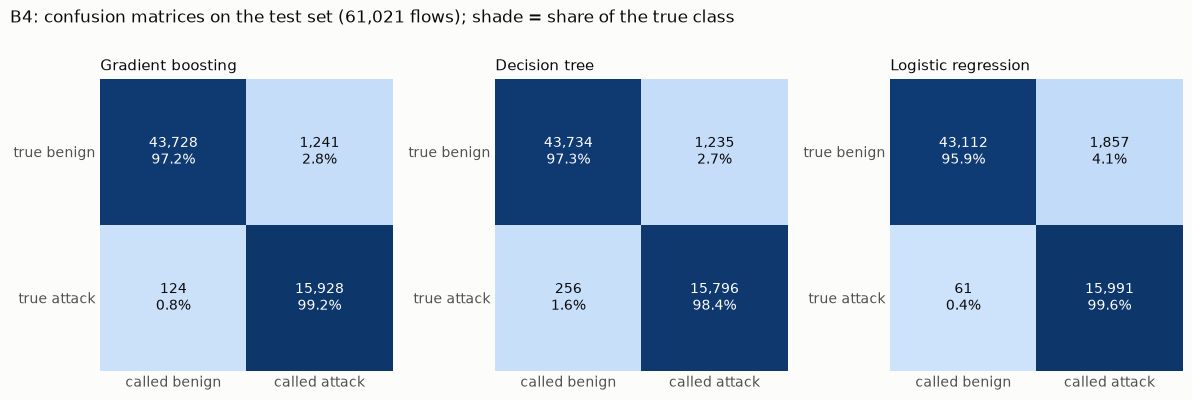

,true_benign_called_benign,true_benign_called_attack,true_attack_called_benign,true_attack_called_attack
model,,,,
boosting,43728,1241,124,15928
tree,43734,1235,256,15796
logreg,43112,1857,61,15991


In [18]:
# STEP B4
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Figure style for the whole project: one colour and marker per model (validated colour-blind-safe set),
# text in ink colours, light grid, no box around the plot.
MODEL_LABELS = {"boosting": "Gradient boosting", "tree": "Decision tree", "logreg": "Logistic regression"}
MODEL_COLORS = {"boosting": "#2a78d6", "tree": "#eb6834", "logreg": "#1baf7a"}
MODEL_MARKERS = {"boosting": "o", "tree": "s", "logreg": "^"}
INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE_RAMP = LinearSegmentedColormap.from_list(
    "blue_ramp", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])


def style_axes(ax, grid_axis="y"):
    ax.set_facecolor(SURFACE)
    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelcolor=INK_2)


ORDER = ["boosting", "tree", "logreg"]
test_pred = {name: MODELS[name].predict(X_test) for name in ORDER}

# 1. Confusion matrices on the test set.
rows = []
for name in ORDER:
    tn, fp, fn, tp = confusion_matrix(y_test, test_pred[name], labels=[0, 1]).ravel()
    rows.append({"model": name, "true_benign_called_benign": tn, "true_benign_called_attack": fp,
                 "true_attack_called_benign": fn, "true_attack_called_attack": tp})
confusion = pd.DataFrame(rows).set_index("model")
confusion.to_csv(TABLES / "B4_confusion.csv")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.9), facecolor=SURFACE)
for ax, name in zip(axes, ORDER):
    r = confusion.loc[name]
    counts = np.array([[r.true_benign_called_benign, r.true_benign_called_attack],
                       [r.true_attack_called_benign, r.true_attack_called_attack]])
    share = counts / counts.sum(axis=1, keepdims=True)
    ax.imshow(share, cmap=BLUE_RAMP, vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{counts[i, j]:,}\n{share[i, j]:.1%}", ha="center", va="center", fontsize=10,
                    color="white" if share[i, j] > 0.5 else INK)
    ax.set_xticks([0, 1], ["called benign", "called attack"])
    ax.set_yticks([0, 1], ["true benign", "true attack"])
    ax.tick_params(length=0, labelcolor=INK_2)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(MODEL_LABELS[name], color=INK, fontsize=11, loc="left")
fig.suptitle("B4: confusion matrices on the test set (61,021 flows); shade = share of the true class",
             color=INK, x=0.01, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(FIGURES / "B4_confusion.png", dpi=150, facecolor=SURFACE)
plt.show()
confusion

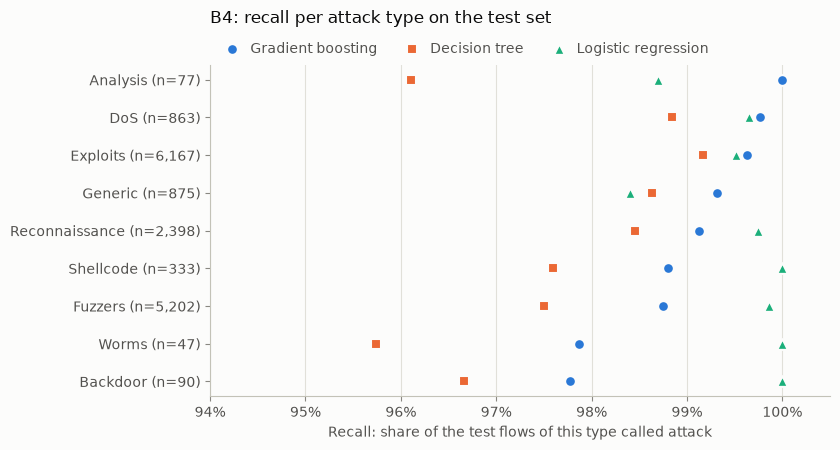

,test_flows,boosting,tree,logreg,note
attack_type,,,,,
Backdoor,90,0.9778,0.9667,1.0000,few flows: less precise
Worms,47,0.9787,0.9574,1.0000,few flows: less precise
Fuzzers,5202,0.9875,0.9750,0.9987,
Shellcode,333,0.9880,0.9760,1.0000,
Reconnaissance,2398,0.9912,0.9846,0.9975,
Generic,875,0.9931,0.9863,0.9840,
Exploits,6167,0.9963,0.9917,0.9951,
DoS,863,0.9977,0.9884,0.9965,
Analysis,77,1.0000,0.9610,0.9870,few flows: less precise


In [19]:
# STEP B4
# 2. Recall per attack type on the test set (benign row: share wrongly called attack = FAR).
rows = []
for attack in type_test.unique():
    mask = (type_test == attack).to_numpy()
    row = {"attack_type": attack, "test_flows": int(mask.sum())}
    for name in ORDER:
        row[name] = float(test_pred[name][mask].mean())     # share called "attack"
    rows.append(row)
per_type = pd.DataFrame(rows).set_index("attack_type")
per_type["note"] = np.where(per_type.index == "Benign", "share called attack = FAR",
                            np.where(per_type["test_flows"] < 100, "few flows: less precise", ""))
attacks = per_type.drop(index="Benign").sort_values("boosting")
per_type = pd.concat([attacks, per_type.loc[["Benign"]]])
per_type.to_csv(TABLES / "B4_recall_per_type.csv", float_format="%.4f")

# Dot plot: one row per attack type, one marker per model (worst-detected type at the bottom).
fig, ax = plt.subplots(figsize=(8.5, 4.6), facecolor=SURFACE)
style_axes(ax, grid_axis="x")
ypos = np.arange(len(attacks))
for name in ORDER:
    ax.scatter(attacks[name], ypos, s=60, marker=MODEL_MARKERS[name], color=MODEL_COLORS[name],
               edgecolor=SURFACE, linewidth=1.5, label=MODEL_LABELS[name], zorder=3)
ax.set_yticks(ypos, [f"{t} (n={n:,})" for t, n in zip(attacks.index, attacks["test_flows"])])
low = np.floor(attacks[ORDER].min().min() * 20) / 20
ax.set_xlim(low - 0.01, 1.005)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("Recall: share of the test flows of this type called attack", color=INK_2)
ax.set_title("B4: recall per attack type on the test set", color=INK, loc="left", fontsize=12, pad=30)
# Legend in one row between the title and the plot, so it never covers a marker.
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncol=3, frameon=False, labelcolor=INK_2,
          handletextpad=0.3, columnspacing=1.5, borderaxespad=0.2)
fig.tight_layout()
fig.savefig(FIGURES / "B4_recall_per_type.png", dpi=150, facecolor=SURFACE)
plt.show()
per_type.round(4)

In [20]:
# STEP B4
# 3. False alarms per day in a network with realistic traffic. In the full UNSW-NB15 recording
#    (CICFlowMeter_out.csv) 89,583 of 3,540,241 flows are attacks; our dataset keeps only ~10% of the
#    benign flows. We assume the same attack-type mix as in the test set.
REAL_ATTACK_SHARE = 89_583 / 3_540_241
FLOWS_PER_DAY = 1_000_000

rows = []
for name in ORDER:
    s = score(MODELS[name], X_test, y_test)
    attacks_per_day = FLOWS_PER_DAY * REAL_ATTACK_SHARE
    benign_per_day = FLOWS_PER_DAY - attacks_per_day
    caught = s["recall"] * attacks_per_day
    false_alarms = s["far"] * benign_per_day
    tp, fp = confusion.loc[name, "true_attack_called_attack"], confusion.loc[name, "true_benign_called_attack"]
    rows.append({"model": name, "recall": s["recall"], "far": s["far"],
                 "attacks_per_day": attacks_per_day, "caught_per_day": caught,
                 "missed_per_day": attacks_per_day - caught, "false_alarms_per_day": false_alarms,
                 "precision_test_set": tp / (tp + fp),
                 "precision_real_traffic": caught / (caught + false_alarms)})
alarms = pd.DataFrame(rows).set_index("model")
alarms.to_csv(TABLES / "B4_alarms_per_day.csv", float_format="%.4f")

print(f"Real traffic: {REAL_ATTACK_SHARE:.2%} attacks; {FLOWS_PER_DAY:,} flows per day")
alarms.style.format({"recall": "{:.4f}", "far": "{:.4f}", "attacks_per_day": "{:,.0f}",
                     "caught_per_day": "{:,.0f}", "missed_per_day": "{:,.0f}",
                     "false_alarms_per_day": "{:,.0f}", "precision_test_set": "{:.1%}",
                     "precision_real_traffic": "{:.1%}"})

Real traffic: 2.53% attacks; 1,000,000 flows per day


,recall,far,attacks_per_day,caught_per_day,missed_per_day,false_alarms_per_day,precision_test_set,precision_real_traffic
model,,,,,,,,
boosting,0.9923,0.0276,"25,304","25,109",195,"26,898",92.8%,48.3%
tree,0.9849,0.0279,"25,304","24,921",383,"27,180",92.7%,47.8%
logreg,0.9962,0.0413,"25,304","25,208",96,"40,250",89.6%,38.5%


<!-- STEP B4 -->
### What the mistakes show

**Confusion matrices.** On the 61,021 test flows, gradient boosting misses 124 attacks and raises 1,241
false alarms. The decision tree raises about as many false alarms (1,235) but misses twice as many
attacks (256). Logistic regression misses only 61 attacks but pays with 1,857 false alarms (50% more).
The models trade missed attacks against false alarms; none is best on both.

**Recall per attack type.** Every model catches at least 95.7% of every attack type. For gradient
boosting the weakest types are Backdoor (97.8%) and Worms (97.9%), but with only 90 and 47 test flows
these numbers move by 1–2 points per flow, so they are not precise. Among the large types, **Fuzzers**
is the weakest (98.75% of 5,202 flows): with about 65 missed flows it accounts for about half of all
attacks gradient boosting misses. Fuzzing sends random or malformed data, which can look much like
ordinary traffic; Part G returns to Fuzzers. Logistic regression reaches 100% on Backdoor, Worms and
Shellcode, but it calls more of everything an attack, which is also why its FAR is highest.

**False alarms per day in realistic traffic.** In the full UNSW-NB15 recording only 2.53% of flows are
attacks. Applied to a network with 1,000,000 flows a day (about 25,300 attacks), gradient boosting would
catch about 25,100 attacks and miss about 195, but also raise **about 26,900 false alarms**. Then only
**48% of its alerts would be real attacks**, against 93% on our test set, where attacks are ten times
more common. For logistic regression only 39% of alerts would be real. The test-set scores therefore
flatter the models: in a real SOC, more than half of the alerts would be false, which is exactly the
alert fatigue described in Part A. Lowering the FAR matters more than raising recall further. (This
estimate assumes the same mix of attack types and the same FAR as on the test set, and one alert per
flow; real systems group related alerts.)

<!-- STEP C1 -->
## Part C: learning with fewer labels

Labelling network flows is expensive: an analyst has to look at each one. Part C asks how good the
detector can be when only a small share of the training flows have a label, and whether the many
*unlabelled* flows can still help.

**Step C1: keep 10% of the labels.** We pretend that only 10% of the 183,063 training flows were
labelled by an analyst (18,306 flows, drawn at random but keeping every attack type's share). The other
90% (164,757 flows) keep their features but lose their labels. Their true labels are kept aside as
`y_hidden` **only to count, in C2, how many of the model's guesses were right**. They are never given to
a model to learn from.

**The lower line.** The black box (gradient boosting with the settings from B2) trained on the 18,306
labelled flows alone. Any method that also uses the unlabelled flows must beat this to count as help.
The **upper line** is the Part B model trained on all 183,063 labels. The validation and test sets are
the same as in Part B.

In [21]:
# STEP C1
# 10% of the TRAINING flows keep their label (stratified on the attack type, seed 42).
X_lab, X_unlab, y_lab, y_hidden = train_test_split(X_train, y_train, train_size=0.10,
                                                   stratify=type_train, random_state=SEED)
# y_hidden: the labels of the unlabelled 90%. Only used to count how many pseudo-labels are right
# (step C2). Never passed to .fit().

assert (len(X_lab), len(X_unlab)) == (18_306, 164_757), (len(X_lab), len(X_unlab))
assert X_lab.index.isin(X_train.index).all() and X_unlab.index.isin(X_train.index).all()
assert not X_lab.index.isin(X_val.index).any() and not X_lab.index.isin(X_test.index).any()
assert not X_lab.index.isin(X_unlab.index).any()

composition = pd.DataFrame({"labelled (10%)": type_train.loc[X_lab.index].value_counts(),
                            "unlabelled (90%)": type_train.loc[X_unlab.index].value_counts()})
composition.loc["Attack share"] = [y_lab.mean(), y_hidden.mean()]
print(f"Labelled: {len(X_lab):,} flows ({int(y_lab.sum()):,} attacks); "
      f"unlabelled: {len(X_unlab):,} flows")
composition.style.format(lambda v: f"{v:.2%}" if v < 1 else f"{v:,.0f}")

Labelled: 18,306 flows (4,815 attacks); unlabelled: 164,757 flows


,labelled (10%),unlabelled (90%)
attack_type,,
Benign,"13,491","121,418"
Exploits,"1,850","16,652"
Fuzzers,"1,561","14,045"
Reconnaissance,719,"6,473"
Generic,262,"2,361"
DoS,259,"2,330"
Shellcode,100,898
Backdoor,27,244
Analysis,23,208


In [22]:
# STEP C1
# The lower line: the same black box, trained on the 10% labelled flows only.
boost_few = cached(f"C1_boost_few_{BOOST_TAG}", lambda: make_boost().fit(X_lab, y_lab))

c1_val = pd.DataFrame({"lower line: boosting, 10% labels": score(boost_few, X_val, y_val),
                       "upper line: boosting, all labels": score(boost, X_val, y_val)}).T
c1_val = c1_val[["macro_f1", "recall", "pr_auc", "far", "accuracy"]]
c1_val.loc["difference (lower - upper)"] = c1_val.iloc[0] - c1_val.iloc[1]
c1_val.index.name = "model (validation set)"
c1_val.to_csv(TABLES / "C1_lower_line_val.csv", float_format="%.4f")
print(f"Lower line: {boost_few.n_iter_} trees")
c1_val.round(4)

Lower line: 82 trees


,macro_f1,recall,pr_auc,far,accuracy
model (validation set),,,,,
"lower line: boosting, 10% labels",0.9679,0.9862,0.9743,0.0296,0.9746
"upper line: boosting, all labels",0.9713,0.9924,0.9807,0.0282,0.9772
difference (lower - upper),-0.0034,-0.0062,-0.0064,0.0014,-0.0027


<!-- STEP C1 -->
### What the lower line shows

The labelled 10% (18,306 flows, 4,815 of them attacks) has the same mix of attack types as the full
training set. Trained on them alone, gradient boosting reaches a validation **macro-F1 of 0.9679,
recall 0.986, PR-AUC 0.974 and FAR 0.030**, against 0.9713 / 0.992 / 0.981 / 0.028 with all labels.

**Losing 90% of the labels costs very little**: 0.003 macro-F1 and 0.006 recall (on the 16,052
validation attacks, about 100 more missed). The lower line is still almost as good as the decision tree
trained on all labels (0.9685) and better than logistic regression on all labels (0.9608).

This sets the bar for step C2: the unlabelled 90% can win back **at most** the gap of 0.003 macro-F1
between the lower and the upper line. With 18,306 labelled flows the model already has plenty of examples
of every common attack type, so we expect pseudo-labelling to help little, if at all.

<!-- STEP C2 -->
## Part C: pseudo-labelling (semi-supervised learning)

**The idea.** The model trained on the labelled 10% looks at the unlabelled flows. Where it is **very
sure** (attack probability at least the *cutoff*, or at most 1 − cutoff), it writes down its guess as a
label, a *pseudo-label*. Those flows join the training data and the model is retrained. This is repeated
for **2 rounds**; then the final model is trained on the labelled flows plus all pseudo-labelled ones.

Pseudo-labelling can only help if the guesses are **right** and also **new**: flows the model already
gets right add little, and wrong guesses teach it mistakes.

**Choosing the cutoff on validation.** We try cutoffs of 0.99, 0.95 and 0.90 (stricter cutoffs add fewer
but safer guesses) and keep the one with the best validation macro-F1; on a tie, the strictest. For each
round we record how many guesses were added (attack / benign), how many flows are still unlabelled, and
how many guesses were right. That last check uses the hidden labels `y_hidden` **after** the guesses are
made; they are never used for training.

In [23]:
# STEP C2
def pseudo_label(cutoff, rounds=2):
    """Pseudo-labelling from the labelled 10%. Returns the final model and one record per round."""
    X_now, y_now = X_lab, y_lab
    pool = X_unlab
    history = []
    for round_no in range(1, rounds + 1):
        model = make_boost().fit(X_now, y_now)
        p = model.predict_proba(pool)[:, 1]
        sure = (p >= cutoff) | (p <= 1 - cutoff)
        guess = pd.Series((p[sure] >= 0.5).astype(int), index=pool.index[sure])
        right = guess == y_hidden.loc[guess.index]                   # check only, never trained on
        history.append({"cutoff": cutoff, "round": round_no, "added": len(guess),
                        "added_attack": int(guess.sum()), "added_benign": int((guess == 0).sum()),
                        "guesses_right": float(right.mean()) if len(guess) else np.nan,
                        "wrong_guesses": int((~right).sum()),
                        "still_unlabelled": int((~sure).sum())})
        X_now = pd.concat([X_now, pool[sure]])
        y_now = pd.concat([y_now, guess])
        pool = pool[~sure]
        if len(pool) == 0:
            break
    model = make_boost().fit(X_now, y_now)                            # final model: labels + guesses
    return model, history


pseudo_models, round_rows, cutoff_rows = {}, [], []
for cutoff in [0.99, 0.95, 0.90]:
    model, history = cached(f"C2_pseudo_cutoff{cutoff}_{BOOST_TAG}", lambda: pseudo_label(cutoff))
    pseudo_models[cutoff] = model
    round_rows += history
    added = sum(h["added"] for h in history)
    wrong = sum(h["wrong_guesses"] for h in history)
    cutoff_rows.append({"cutoff": cutoff, "guesses_added": added,
                        "share_of_unlabelled": added / len(X_unlab),
                        "guesses_right": 1 - wrong / added if added else np.nan,
                        "wrong_guesses": wrong, **score(model, X_val, y_val)})

c2_rounds = pd.DataFrame(round_rows)
c2_cutoff = pd.DataFrame(cutoff_rows)
c2_rounds.to_csv(TABLES / "C2_rounds.csv", index=False, float_format="%.4f")
c2_cutoff.to_csv(TABLES / "C2_cutoff.csv", index=False, float_format="%.4f")

# Best validation macro-F1; on a tie the first row, i.e. the strictest cutoff.
CUTOFF = float(c2_cutoff.loc[c2_cutoff["macro_f1"].round(4).idxmax(), "cutoff"])
boost_pseudo = pseudo_models[CUTOFF]
print(f"Chosen cutoff: {CUTOFF}")
print("\nPer round:")
print(c2_rounds.round(4).to_string(index=False))
c2_cutoff.round(4)

Chosen cutoff: 0.95

Per round:
 cutoff  round  added  added_attack  added_benign  guesses_right  wrong_guesses  still_unlabelled
   0.99      1 130834         14576        116258         0.9989            147             33923
   0.99      2   5584          5406           178         0.9654            193             28339
   0.95      1 143824         27268        116556         0.9947            769             20933
   0.95      2   6503          6315           188         0.9040            624             14430
   0.90      1 151719         34962        116757         0.9905           1444             13038
   0.90      2   7371          7113           258         0.8662            986              5667


,cutoff,guesses_added,share_of_unlabelled,guesses_right,wrong_guesses,accuracy,macro_f1,recall,pr_auc,far
0,0.99,136418,0.8280,0.9975,340,0.9744,0.9677,0.9870,0.9739,0.0301
1,0.95,150327,0.9124,0.9907,1393,0.9746,0.9681,0.9899,0.9727,0.0308
2,0.90,159090,0.9656,0.9847,2430,0.9746,0.9680,0.9922,0.9733,0.0317


<!-- STEP C2 -->
### What pseudo-labelling did

**The chosen cutoff is 0.95.** Its final model was trained on the 18,306 labelled flows plus 150,327
pseudo-labelled ones (91% of the unlabelled flows). Validation macro-F1 is 0.9681, against 0.9679 for
the lower line: **practically no gain**. All three cutoffs land within 0.0004 of each other.

**The guesses were almost all right, but mostly not new.** In round 1 (cutoff 0.95) the model added
143,824 guesses, 99.5% of them right, and 116,556 of them benign. These are flows the model was already
sure about, so learning from them teaches it little it did not know.

**Round 2 adds harder and less reliable guesses.** After retraining, the newly confident flows are mostly
attacks (6,315 of 6,503), and only 90% of them are right (87% at cutoff 0.90). The flows that only become
"sure" after a round are exactly the borderline ones, where the model is most often wrong.

**A looser cutoff trades false alarms for recall.** From cutoff 0.99 to 0.90, validation recall rises
from 0.987 to 0.992 (more attack guesses in the training data), but FAR rises from 0.030 to 0.032 and
PR-AUC falls. Macro-F1, which weighs both, hardly moves.

Step C3 compares the lower line, the pseudo-labelling model and the upper line side by side.

<!-- STEP C3 -->
## Part C: did the unlabelled data help?

The three models side by side on the **validation** set: the lower line (10% labels), pseudo-labelling
(10% labels + the unlabelled flows) and the upper line (all labels). The last row shows how much of the
gap between the lower and the upper line pseudo-labelling closed (100% = as good as having all labels;
for FAR, lower is better, so closing the gap means reducing it).

In [24]:
# STEP C3
c3 = pd.DataFrame({"lower line: 10% labels": score(boost_few, X_val, y_val),
                   f"pseudo-labelling (cutoff {CUTOFF})": score(boost_pseudo, X_val, y_val),
                   "upper line: all labels": score(boost, X_val, y_val)}).T
c3 = c3[["macro_f1", "recall", "pr_auc", "far", "accuracy"]]
lower, pseudo, upper = c3.iloc[0], c3.iloc[1], c3.iloc[2]
c3.loc["pseudo-labelling minus lower line"] = pseudo - lower
c3.loc["share of the gap closed"] = (pseudo - lower) / (upper - lower)
c3.index.name = "validation set"
c3.to_csv(TABLES / "C3_did_it_help_val.csv", float_format="%.4f")
c3.round(4)

,macro_f1,recall,pr_auc,far,accuracy
validation set,,,,,
lower line: 10% labels,0.9679,0.9862,0.9743,0.0296,0.9746
pseudo-labelling (cutoff 0.95),0.9681,0.9899,0.9727,0.0308,0.9746
upper line: all labels,0.9713,0.9924,0.9807,0.0282,0.9772
pseudo-labelling minus lower line,0.0001,0.0037,-0.0016,0.0013,0.0000
share of the gap closed,0.0393,0.6000,-0.2581,-0.9194,0.0185


<!-- STEP C3 -->
### Verdict: no, the unlabelled data did not help

**Plainly: pseudo-labelling did not make the detector better.** On the validation set it raised
macro-F1 from 0.9679 to 0.9681, which closes only about 4% of the gap to the model trained with all
labels (0.9713). That difference is too small to matter: a different random 10% of labels could easily
move the score by as much (optional extra X2 measures this).

**It changed the balance, not the quality.** Pseudo-labelling caught more attacks (recall 0.986 → 0.990,
60% of the gap closed) but raised more false alarms (FAR 0.0296 → 0.0308, *further* from the upper
line's 0.0282) and ranked attacks slightly worse (PR-AUC 0.974 → 0.973). It added many attack
pseudo-labels in round 2, about 10% of them wrong, which pushes the model towards calling more flows
attacks. In a real SOC, where false alarms are the main cost (step B4), that trade is not an improvement.

**Why it did not help:**
1. **There was little left to gain.** 10% of this dataset is still 18,306 labelled flows, enough
   examples of every common attack type: the lower line is only 0.003 macro-F1 below the upper line.
2. **The confident guesses were not new.** 99.5% of the round-1 guesses were right, but they were flows
   the model already classified correctly, mostly benign. Adding them repeats what the model knows.
3. **The new guesses were less reliable.** The flows that became "sure" only in round 2 were the
   borderline ones, and about 1 in 10 of those guesses was wrong.

**When could it help?** With far fewer labels (a few hundred instead of 18,306), the lower line would be
weaker and there would be more to gain; optional extra X2 repeats Part C with 1% and 5% of the labels.
Step C4 checks the same comparison on the test set.

<!-- STEP C4 -->
## Part C: the results table (all models, test set)

The report's main table: every model of Parts A–C with the four scores the brief asks for, on the **same
test set**, next to the trivial baseline. All settings were fixed on validation before this step; nothing
here is chosen. The Part B rows must equal the B3 test table, which the code checks.

In [25]:
# STEP C4
all_models = {
    "always benign (trivial baseline)": always_benign,
    "decision tree, all labels": tree,
    "logistic regression, all labels": logreg,
    "gradient boosting, all labels (upper line)": boost,
    "gradient boosting, 10% labels (lower line)": boost_few,
    f"gradient boosting, 10% labels + pseudo-labels (cutoff {CUTOFF})": boost_pseudo,
}
results = pd.DataFrame({name: score(model, X_test, y_test) for name, model in all_models.items()}).T
results = results[["macro_f1", "recall", "pr_auc", "far", "accuracy"]]
results.index.name = "model (test set)"
results.to_csv(TABLES / "C4_all_models_test.csv", float_format="%.4f")

# The Part B rows must match the B3 test table.
b3 = pd.read_csv(TABLES / "B3_test_scores.csv", index_col="model")
for b3_name, c4_name in [("always benign", "always benign (trivial baseline)"),
                         ("tree", "decision tree, all labels"),
                         ("logreg", "logistic regression, all labels"),
                         ("boosting", "gradient boosting, all labels (upper line)")]:
    assert np.allclose(b3.loc[b3_name, results.columns], results.loc[c4_name], atol=1e-4), b3_name
print("Part B rows match the B3 test table")
results.round(4)

Part B rows match the B3 test table


,macro_f1,recall,pr_auc,far,accuracy
model (test set),,,,,
always benign (trivial baseline),0.4243,0.0000,0.2631,0.0000,0.7369
"decision tree, all labels",0.9690,0.9849,0.9677,0.0279,0.9755
"logistic regression, all labels",0.9608,0.9962,0.9527,0.0413,0.9686
"gradient boosting, all labels (upper line)",0.9718,0.9923,0.9814,0.0276,0.9776
"gradient boosting, 10% labels (lower line)",0.9688,0.9872,0.9755,0.0290,0.9753
"gradient boosting, 10% labels + pseudo-labels (cutoff 0.95)",0.9685,0.9894,0.9735,0.0301,0.9750


In [26]:
# STEP C4
# The C3 verdict, repeated on the test set.
lower = results.loc["gradient boosting, 10% labels (lower line)"]
pseudo = results.loc[f"gradient boosting, 10% labels + pseudo-labels (cutoff {CUTOFF})"]
upper = results.loc["gradient boosting, all labels (upper line)"]
c4_check = pd.DataFrame({"pseudo-labelling minus lower line": pseudo - lower,
                         "share of the gap closed": (pseudo - lower) / (upper - lower)}).T
c4_check.index.name = "test set"
c4_check.round(4)

,macro_f1,recall,pr_auc,far,accuracy
test set,,,,,
pseudo-labelling minus lower line,-0.0003,0.0022,-0.0020,0.0011,-0.0002
share of the gap closed,-0.0864,0.4321,-0.3331,-0.7813,-0.1034


<!-- STEP C4 -->
### What the results table shows

| Model (test set, 61,021 flows) | Macro-F1 | Recall | PR-AUC | FAR |
|---|---|---|---|---|
| Always benign (trivial baseline) | 0.424 | 0.000 | 0.263 | 0.000 |
| Decision tree, all labels | 0.969 | 0.985 | 0.968 | 0.028 |
| Logistic regression, all labels | 0.961 | 0.996 | 0.953 | 0.041 |
| Gradient boosting, all labels (upper line) | **0.972** | 0.992 | **0.981** | **0.028** |
| Gradient boosting, 10% labels (lower line) | 0.969 | 0.987 | 0.976 | 0.029 |
| Gradient boosting, 10% labels + pseudo-labels | 0.969 | 0.989 | 0.974 | 0.030 |

**Every model is far above the trivial baseline**, even with only 10% of the labels.

**Gradient boosting with all labels is the best model**, but the margins are small: 0.003 macro-F1 over
the decision tree and over the same model with only 10% of the labels.

**The C3 verdict holds on the test set, and is slightly stronger.** Pseudo-labelling is a little *worse*
than the lower line (macro-F1 0.9685 against 0.9688, PR-AUC 0.974 against 0.976): it catches a few more
attacks (recall +0.002) but raises more false alarms (FAR +0.001). **The unlabelled data did not
help**, on validation or on test.

<!-- STEP D1 -->
## Part D: global explanation with SHAP

**What SHAP does.** For one flow, SHAP splits the model's output into one contribution per feature:
"`Fwd Seg Size Min` pushed this flow towards *attack* by 2.1, `Bwd Packets/s` pushed it towards *benign*
by 0.4, ...". The contributions add up exactly to the model's output for that flow, starting from a
*base value* (the model's average output). Averaging the size of each feature's contributions over many
flows gives a **global ranking**: which features the model relies on most.

**For gradient boosting the unit is log-odds**, not probability: 0 means 50% attack, +2 about 88%, −2
about 12%. Larger in absolute value means a stronger push. We use `TreeExplainer`, the exact and fast SHAP
method for tree models.

**Which flows.** 1,000 random flows of the **validation** set (seed 42). Part F picks its two features
from this ranking, and choosing anything must not look at the test set.

The feature meanings come from the glossary written in step T4 (`results/tables/T4_feature_glossary.csv`).

In [27]:
# STEP D1
import sys

import matplotlib.pyplot as plt
import shap

sys.path.insert(0, "src")
import xai_tools  # noqa: E402  SHAP/LIME helpers from Lab 3 (src/xai_tools.py)

GLOSSARY = pd.read_csv(TABLES / "T4_feature_glossary.csv", index_col="feature")

EXPLAIN_VAL = X_val.sample(1000, random_state=SEED)          # 1,000 random validation flows
explainer = shap.TreeExplainer(boost)
sv = explainer(EXPLAIN_VAL)
assert sv.values.shape == (1000, len(FEATURES)), sv.values.shape

# Check that the contributions add up: base value + sum of SHAP values = the model's log-odds output.
assert np.allclose(sv.base_values + sv.values.sum(axis=1), boost.decision_function(EXPLAIN_VAL), atol=1e-6)
# The base value is the model's average output in log-odds. It is not the average probability:
# benign flows get very negative log-odds and pull the average far below 0.
print(f"Base value (average model output): {float(np.mean(sv.base_values)):.2f} log-odds")
print(f"The 1,000 flows: {int(y_val.loc[EXPLAIN_VAL.index].sum())} attacks, "
      f"{int((y_val.loc[EXPLAIN_VAL.index] == 0).sum())} benign")

shap_global = (pd.Series(np.abs(sv.values).mean(axis=0), index=FEATURES)
               .sort_values(ascending=False))
top = pd.DataFrame({"mean_abs_shap": shap_global,
                    "share_of_total": shap_global / shap_global.sum()}).head(10)
top["cumulative_share"] = top["share_of_total"].cumsum()
top = top.join(GLOSSARY[["meaning", "direction", "group_proposed"]])
top.index.name = "feature"
top.to_csv(TABLES / "D1_shap_top.csv", float_format="%.4f")
top.style.format({"mean_abs_shap": "{:.3f}", "share_of_total": "{:.1%}", "cumulative_share": "{:.1%}"})

Base value (average model output): -6.73 log-odds
The 1,000 flows: 260 attacks, 740 benign


,mean_abs_shap,share_of_total,cumulative_share,meaning,direction,group_proposed
feature,,,,,,
Fwd Seg Size Min,3.614,42.0%,42.0%,Smallest header size seen in the initiator's packets; depends on the initiator's operating system and TCP options,forward,Free
FWD Init Win Bytes,1.842,21.4%,63.4%,TCP window size in the initiator's first packet: how much data it accepts at once. Set by the initiator's operating system (0 = not TCP or not recorded),forward,Free
Bwd Packets/s,1.113,12.9%,76.4%,How fast the responder sent packets,backward,Fixed
Total Length of Bwd Packet,0.265,3.1%,79.4%,Total payload bytes the responder sent back,backward,Fixed
Packet Length Max,0.183,2.1%,81.6%,"Largest packet payload in the conversation, either direction",both,Fixed
Bwd Packet Length Min,0.170,2.0%,83.5%,Smallest packet payload the responder sent,backward,Fixed
Flow Bytes/s,0.127,1.5%,85.0%,Data rate of the whole conversation (bytes / duration),both,Fixed
Bwd Packet Length Mean,0.095,1.1%,86.1%,Average packet payload the responder sent,backward,Fixed
Packet Length Mean,0.090,1.0%,87.2%,"Average packet payload, both directions together",both,Fixed


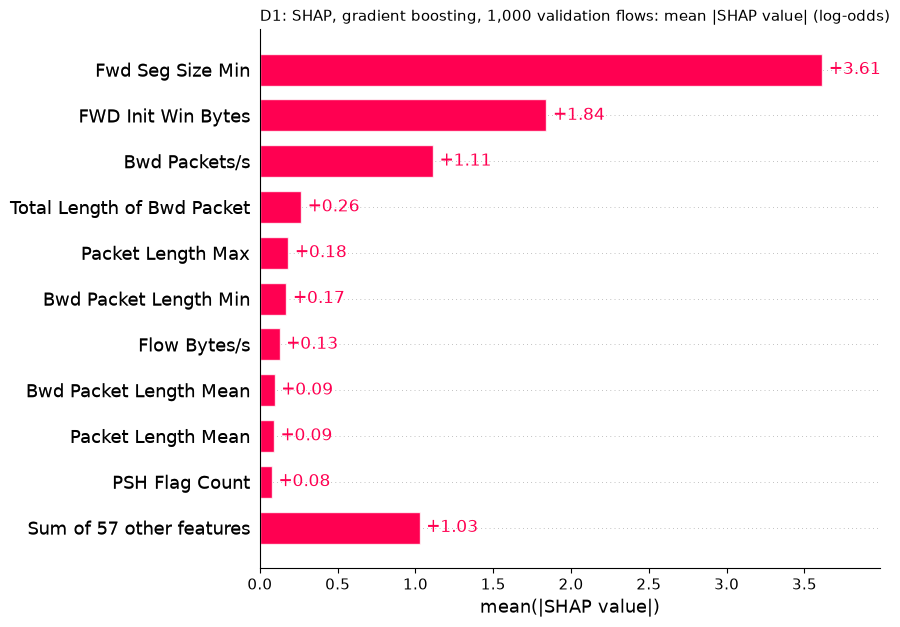

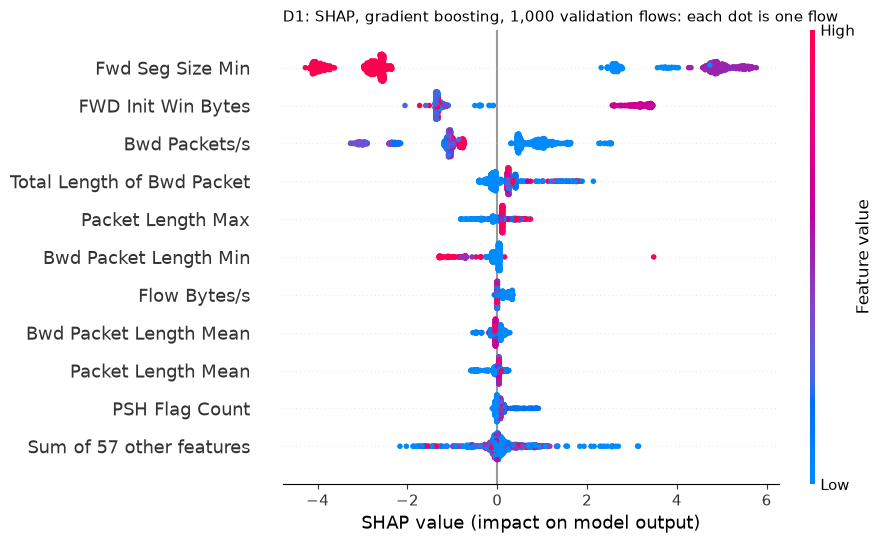

In [28]:
# STEP D1
# Bar plot: average size of each feature's contribution. Beeswarm: one dot per flow, coloured by the
# feature's value (red = high, blue = low); dots to the right push towards "attack".
shap.plots.bar(sv, max_display=11, show=False)
plt.title("D1: SHAP, gradient boosting, 1,000 validation flows: mean |SHAP value| (log-odds)",
          loc="left", fontsize=11)
plt.savefig(FIGURES / "D1_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

shap.plots.beeswarm(sv, max_display=11, show=False)
plt.title("D1: SHAP, gradient boosting, 1,000 validation flows: each dot is one flow", loc="left",
          fontsize=11)
plt.savefig(FIGURES / "D1_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
# STEP D1
# The two top features in the training data: how many flows have each value, and how many of them are
# attacks. (Used in the interpretation below.)
rows = []
for feature, values in [("Fwd Seg Size Min", [8, 20, 32]), ("FWD Init Win Bytes", [0, 16383, 5792])]:
    for value in values:
        has = (X_train[feature] == value).to_numpy()
        rows.append({"feature": feature, "value": value, "training_flows": int(has.sum()),
                     "attack_share": float(y_train.to_numpy()[has].mean())})
fingerprint_table = pd.DataFrame(rows)
fingerprint_table.to_csv(TABLES / "D1_fingerprint_values.csv", index=False, float_format="%.4f")
attacks_train = (y_train == 1).to_numpy()
with_window = int((attacks_train & (X_train["FWD Init Win Bytes"] == 16383).to_numpy()).sum())
print(f"Training attacks with FWD Init Win Bytes = 16,383: {with_window:,} of {int(attacks_train.sum()):,} "
      f"({with_window / attacks_train.sum():.1%})")
fingerprint_table.style.format({"training_flows": "{:,}", "attack_share": "{:.1%}"})

Training attacks with FWD Init Win Bytes = 16,383: 45,850 of 48,154 (95.2%)


,feature,value,training_flows,attack_share
0,Fwd Seg Size Min,8,"25,518",9.0%
1,Fwd Seg Size Min,20,"51,290",89.4%
2,Fwd Seg Size Min,32,"106,079",0.0%
3,FWD Init Win Bytes,0,"25,518",9.0%
4,FWD Init Win Bytes,16383,"50,962",90.0%
5,FWD Init Win Bytes,5792,"87,387",0.0%


<!-- STEP D1 -->
### What the global SHAP picture shows

**Three features carry three quarters of the model's reasoning.** `Fwd Seg Size Min` (42% of the total
SHAP weight), `FWD Init Win Bytes` (21%) and `Bwd Packets/s` (13%) together account for 76%; the other
64 features share the rest. (The base value, the model's average output, is −6.7 log-odds; that every
contribution adds up exactly to the model's output is checked in the code.)

**The top two describe the attacker's machine, not the attack.** Both are TCP settings that the operating
system of the initiating computer chooses when it opens a connection. In the training data (code cell above):

| Value | Training flows | Share that are attacks |
|---|---:|---:|
| `Fwd Seg Size Min` = 20 bytes | 51,290 | 89% |
| `Fwd Seg Size Min` = 32 bytes | 106,079 | 0% |
| `FWD Init Win Bytes` = 16,383 | 50,962 | 90% |
| `FWD Init Win Bytes` = 5,792 | 87,387 | 0% |

95% of all training attacks (45,850 of 48,154) open their connection with a window of exactly 16,383 bytes.
In the beeswarm this shows as two well-separated clouds per feature: one value pushes strongly towards
"attack", the other strongly towards "benign". In UNSW-NB15 all attacks were generated by a few attacker
machines with their own TCP settings, while the normal traffic came from other machines. The model has
learned to **recognise those machines**: a *shortcut* that works on this dataset but says nothing about
what an attack does.

**Do the features make sense to a security person? Only partly.**
- `Fwd Seg Size Min` and `FWD Init Win Bytes`: no, not as evidence of an attack. They are a fingerprint of
  the machine. An attacker using another operating system, or changing two TCP settings on their own
  machine, would no longer look like this, and a normal computer that happens to share these settings
  would look like an attacker. A security person would use them to recognise *known* machines, not
  attacks in general.
- `Bwd Packets/s` (how fast the other side replies), `Total Length of Bwd Packet`, `Packet Length Max`,
  `Bwd Packet Length Min` and `Flow Bytes/s`: yes. They describe the conversation itself: scans and
  floods get few or no replies from the victim, exploits and fuzzing send unusual packet sizes. These are
  the kind of evidence an analyst would look at.

This shortcut is the most important finding of Part D. It explains why the models in Part B are so
accurate, it is what an attacker could fake most cheaply (step E4), and it reappears in Parts F and G.
The optional extra X6 tests how well the model does without the TCP-settings features.

<!-- STEP D2 -->
## Part D: three flows to explain

The brief asks for three local explanations: **a confident correct detection, a confident correct
negative, and a mistake**. We pick them from the **test** set with the black box's attack probability:

- **detection**: the true attack with the highest attack probability;
- **negative**: the true benign flow with the lowest attack probability;
- **mistake**: the wrongly classified flow the model was most sure about (probability furthest from 0.5).
  It can be a false alarm (benign called attack) or a missed attack.

When several flows tie (many get a probability of practically 1 or 0), the first one in test-set order is
taken, so the choice is reproducible. Explaining test flows is allowed: it changes no model or setting.
The positions are stored in `CASES` and used by D3–D6 and by Part F.

In [30]:
# STEP D2
p_test = boost.predict_proba(X_test)[:, 1]
pred_test = (p_test >= 0.5).astype(int)
y_true = y_test.to_numpy()

caught = np.flatnonzero((y_true == 1) & (pred_test == 1))
cleared = np.flatnonzero((y_true == 0) & (pred_test == 0))
wrong = np.flatnonzero(pred_test != y_true)

# argmax / argmin return the first position on a tie (test-set order), so the choice is reproducible.
CASES = {"detection": int(caught[np.argmax(p_test[caught])]),
         "negative": int(cleared[np.argmin(p_test[cleared])]),
         "mistake": int(wrong[np.argmax(np.abs(p_test[wrong] - 0.5))])}

print(f"Test flows: {len(caught):,} correct detections, {len(cleared):,} correct negatives, "
      f"{len(wrong):,} mistakes ({int((y_true[wrong] == 0).sum()):,} false alarms, "
      f"{int((y_true[wrong] == 1).sum()):,} missed attacks)")
print(f"Ties: {int((p_test[caught] == p_test[caught].max()).sum())} detections share the highest "
      f"probability, {int((p_test[cleared] == p_test[cleared].min()).sum())} negatives the lowest")

TOP3 = list(shap_global.index[:3])
cases = pd.DataFrame([{
    "case": name, "test_position": pos, "attack_type": type_test.iloc[pos],
    "true_label": "attack" if y_true[pos] == 1 else "benign",
    "called": "attack" if pred_test[pos] == 1 else "benign",
    "attack_probability": p_test[pos],
    **{f: X_test.iloc[pos][f] for f in TOP3},
} for name, pos in CASES.items()]).set_index("case")
cases.to_csv(TABLES / "D2_cases.csv", float_format="%.6g")
cases

Test flows: 15,928 correct detections, 43,728 correct negatives, 1,365 mistakes (1,241 false alarms, 124 missed attacks)
Ties: 1 detections share the highest probability, 1 negatives the lowest


,test_position,attack_type,true_label,called,attack_probability,Fwd Seg Size Min,FWD Init Win Bytes,Bwd Packets/s
case,,,,,,,,
detection,50065,Exploits,attack,attack,9.995756e-01,20.0,16383.0,22.675749
negative,47114,Benign,benign,benign,2.061596e-07,8.0,0.0,2006.018054
mistake,10048,Benign,benign,attack,9.989081e-01,20.0,16383.0,23.214244


In [31]:
# STEP D2
# How much of the model's behaviour on the test set follows the attacker fingerprint
# (Fwd Seg Size Min = 20 and FWD Init Win Bytes = 16,383, see D1)?
fingerprint = ((X_test["Fwd Seg Size Min"] == 20) & (X_test["FWD Init Win Bytes"] == 16383)).to_numpy()
false_alarm = (y_true == 0) & (pred_test == 1)
missed = (y_true == 1) & (pred_test == 0)
fp_check = pd.DataFrame({
    "flows": [int((fingerprint & (y_true == 1)).sum()), int((fingerprint & (y_true == 0)).sum()),
              int((~fingerprint & (y_true == 1)).sum()), int((~fingerprint & (y_true == 0)).sum())],
    "called attack": [float(pred_test[fingerprint & (y_true == 1)].mean()),
                      float(pred_test[fingerprint & (y_true == 0)].mean()),
                      float(pred_test[~fingerprint & (y_true == 1)].mean()),
                      float(pred_test[~fingerprint & (y_true == 0)].mean())],
}, index=pd.MultiIndex.from_tuples([("fingerprint", "attack"), ("fingerprint", "benign"),
                                    ("no fingerprint", "attack"), ("no fingerprint", "benign")],
                                   names=["test flows with", "true label"]))
fp_check.to_csv(TABLES / "D2_fingerprint_check.csv", float_format="%.4f")
print(f"False alarms with the fingerprint: {int((false_alarm & fingerprint).sum()):,} of {int(false_alarm.sum()):,}")
print(f"Missed attacks without the fingerprint: {int((missed & ~fingerprint).sum()):,} of {int(missed.sum()):,}")
fp_check.style.format({"flows": "{:,}", "called attack": "{:.1%}"})

False alarms with the fingerprint: 1,197 of 1,241
Missed attacks without the fingerprint: 4 of 124


<!-- STEP D2 -->
### The three flows and what they already show

| Case | Test position | Type | Called | Attack probability | `Fwd Seg Size Min` | `FWD Init Win Bytes` | `Bwd Packets/s` |
|---|---:|---|---|---:|---:|---:|---:|
| detection | 50,065 | Exploits | attack | 0.9996 | 20 | 16,383 | 22.7 |
| negative | 47,114 | Benign | benign | 0.0000002 | 8 | 0 | 2,006 |
| mistake | 10,048 | **Benign** | **attack** | 0.9989 | 20 | 16,383 | 23.2 |

**The mistake is a false alarm that looks exactly like the detection** on the three most important
features: the same attacker fingerprint (`Fwd Seg Size Min` = 20, `FWD Init Win Bytes` = 16,383) and
almost the same reply rate. The model is 99.9% sure it is an attack. The negative has a completely
different profile (no TCP window at all, which usually means the flow is not a TCP connection, and a fast
reply rate). D3 explains all three with SHAP and LIME.

**The fingerprint explains almost all false alarms** (second table above):
- **1,197 of the 1,241 false alarms (96%)** are benign flows with the attacker fingerprint. Of the 1,731
  benign test flows that carry it, 69% are called attacks; of the 43,238 benign flows without it, only
  0.1%. These benign flows probably come from the same kind of machines as the attacks (in the full
  recording, 1.6% of benign flows come from the attacker addresses), so the model cannot tell them apart.
- **The model is not *only* the fingerprint.** The 749 attacks without it are still caught 99.5% of the
  time, through the behaviour features (reply rate, packet sizes). And 120 of the 124 missed attacks *do*
  carry the fingerprint: among fingerprint flows, the behaviour features decide, and that is where both
  kinds of mistake happen.

So the fingerprint sorts flows into "attacker-like machine" or not, and within the attacker-like group the
behaviour features do the fine work. A benign computer that shares the attacker's TCP settings is very
likely to be flagged.

<!-- STEP D3 -->
## Part D: local explanations of the three flows, with SHAP and with LIME

Each of the three flows from D2 is explained twice:

- **SHAP waterfall**: starts at the base value (the model's average output) and adds each feature's
  contribution until it reaches this flow's output. Bars to the right push towards *attack*, to the left
  towards *benign*. Units are log-odds (D1). SHAP for trees is exact: it describes the model itself.
- **LIME**: makes 5,000 slightly changed copies of the flow, asks the model about each, and fits a
  simple straight-line model to those answers. Its explanation is a list of conditions such as
  "`Fwd Seg Size Min` ≤ 20" with a weight: positive pushes towards attack. Units are probability. LIME
  turns each continuous feature into ranges (quartiles of the training data) before fitting.
  Its **fit score** (R², 0 to 1) says how well the straight line matches the model around this flow;
  below 0.5, LIME's explanation should not be trusted much.

Then we compare the **top 3 features** of each method for each flow.

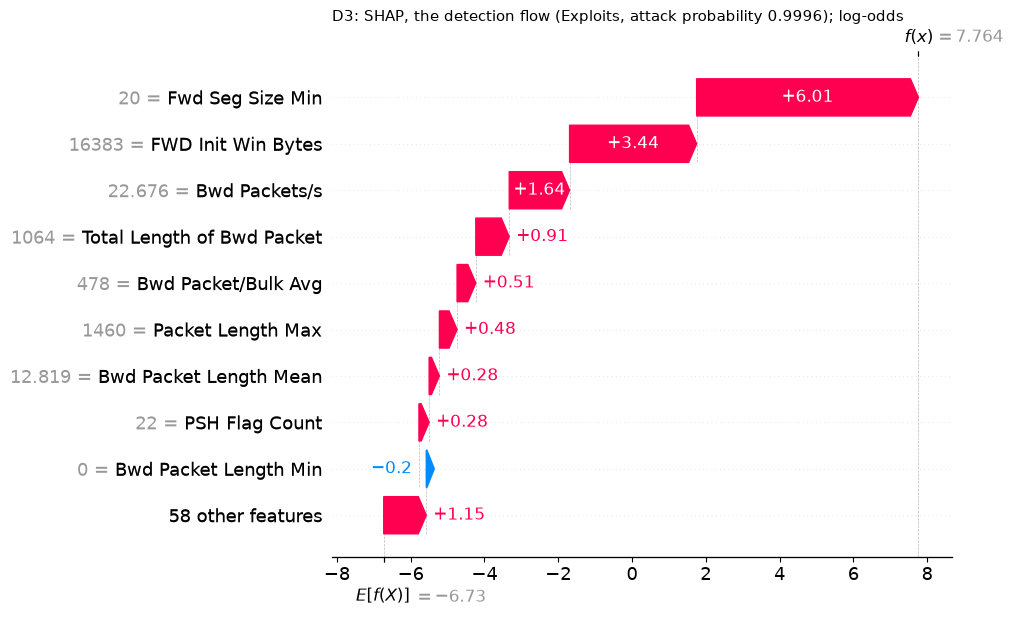

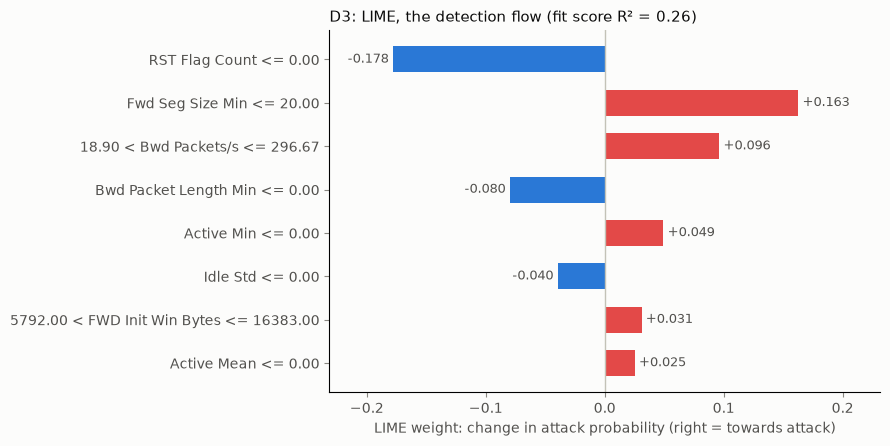

detection: LIME conditions (weight in attack probability):
   -0.178  RST Flag Count <= 0.00
   +0.163  Fwd Seg Size Min <= 20.00
   +0.096  18.90 < Bwd Packets/s <= 296.67
   -0.080  Bwd Packet Length Min <= 0.00
   +0.049  Active Min <= 0.00
   -0.040  Idle Std <= 0.00
   +0.031  5792.00 < FWD Init Win Bytes <= 16383.00
   +0.025  Active Mean <= 0.00


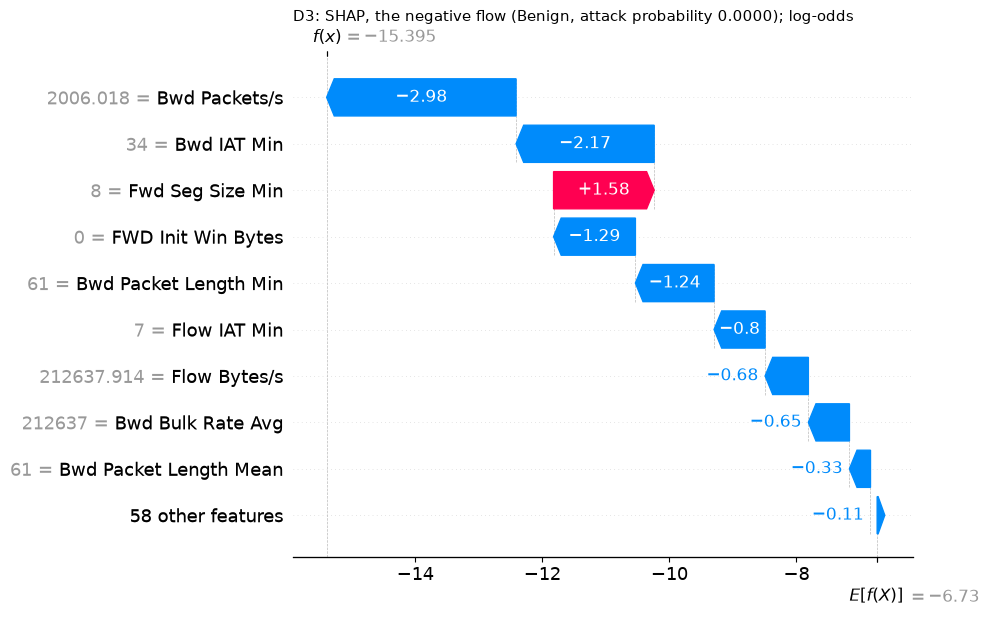

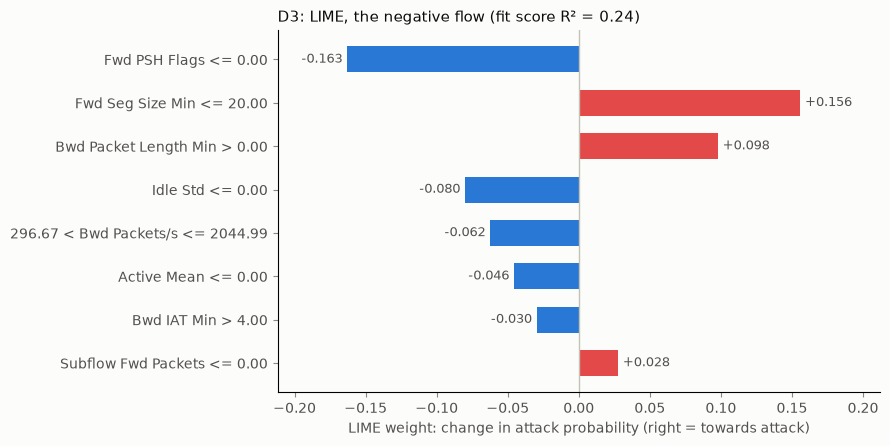

negative: LIME conditions (weight in attack probability):
   -0.163  Fwd PSH Flags <= 0.00
   +0.156  Fwd Seg Size Min <= 20.00
   +0.098  Bwd Packet Length Min > 0.00
   -0.080  Idle Std <= 0.00
   -0.062  296.67 < Bwd Packets/s <= 2044.99
   -0.046  Active Mean <= 0.00
   -0.030  Bwd IAT Min > 4.00
   +0.028  Subflow Fwd Packets <= 0.00


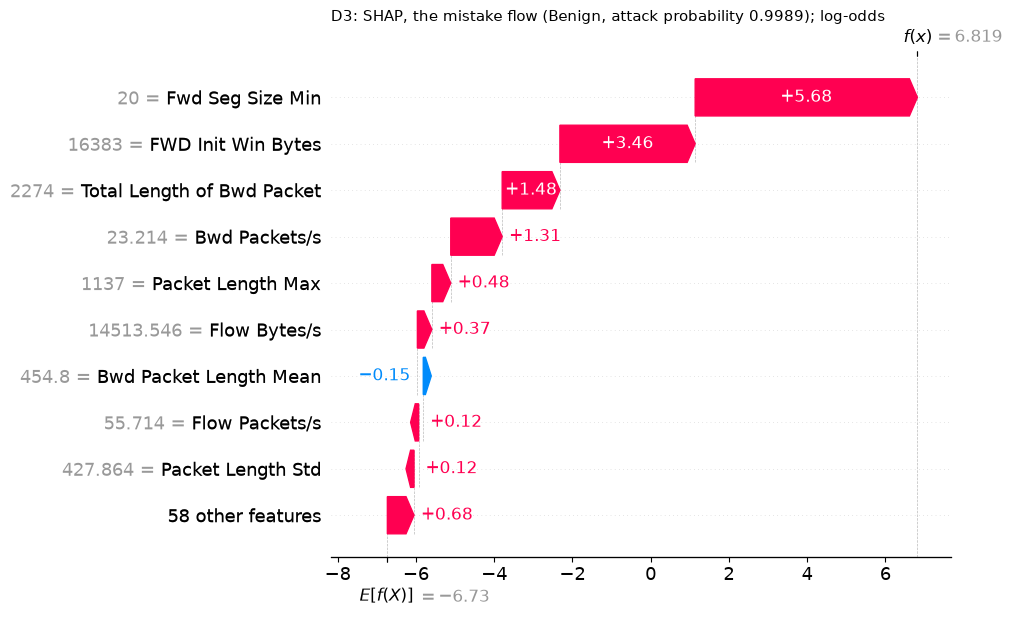

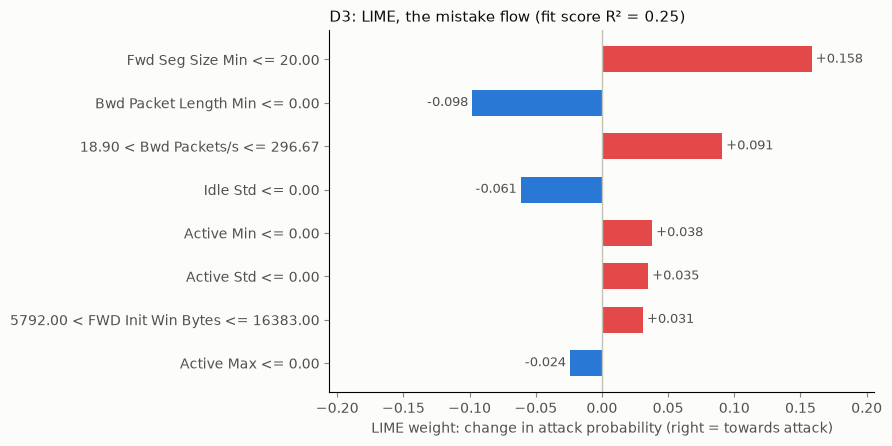

mistake: LIME conditions (weight in attack probability):
   +0.158  Fwd Seg Size Min <= 20.00
   -0.098  Bwd Packet Length Min <= 0.00
   +0.091  18.90 < Bwd Packets/s <= 296.67
   -0.061  Idle Std <= 0.00
   +0.038  Active Min <= 0.00
   +0.035  Active Std <= 0.00
   +0.031  5792.00 < FWD Init Win Bytes <= 16383.00
   -0.024  Active Max <= 0.00


,attack_type,attack_probability,SHAP_top3,LIME_top3,shared_in_top3,LIME_fit_score,LIME_local_prediction
case,,,,,,,
detection,Exploits,9.995756e-01,"Fwd Seg Size Min, FWD Init Win Bytes, Bwd Pack...","RST Flag Count, Fwd Seg Size Min, Bwd Packets/s",2,0.259469,0.246893
negative,Benign,2.061596e-07,"Bwd Packets/s, Bwd IAT Min, Fwd Seg Size Min","Fwd PSH Flags, Fwd Seg Size Min, Bwd Packet Le...",1,0.238867,0.172661
mistake,Benign,9.989081e-01,"Fwd Seg Size Min, FWD Init Win Bytes, Total Le...","Fwd Seg Size Min, Bwd Packet Length Min, Bwd P...",1,0.253149,0.236865


In [32]:
# STEP D3
from lime.lime_tabular import LimeTabularExplainer


def predict_fn(a):
    """The black box for LIME and the xai_tools helpers: they pass plain numbers, the model wants a table."""
    return boost.predict_proba(pd.DataFrame(a, columns=FEATURES))


def d3_lime():
    """LIME for the three flows, one explainer with seed 42, in the order of CASES (as computed in D3)."""
    lime_explainer = LimeTabularExplainer(X_train.to_numpy(), feature_names=FEATURES,
                                          class_names=["benign", "attack"], discretize_continuous=True,
                                          random_state=SEED)
    return {name: xai_tools.lime_explain(lime_explainer, predict_fn, X_test.iloc[pos].to_numpy(),
                                         num_features=8, num_samples=5000)[1]
            for name, pos in CASES.items()}


# Building a LIME explainer on 183,063 rows takes about 40 s, so the results are cached (H4).
lime_d3 = cached("D3_lime", d3_lime)

# Same colours as SHAP's plots: red = pushes towards attack, blue = towards benign (a validated
# diverging pair; LIME's own red/green plot is hard to read for colour-blind readers).
TO_ATTACK, TO_BENIGN = "#e34948", "#2a78d6"


def plot_lime(summary, title, path):
    """Horizontal bars of LIME's conditions and weights, the largest at the top, values written out."""
    conditions = summary["conditions"][::-1]
    labels = [c for c, _ in conditions]
    weights = np.array([w for _, w in conditions])
    fig, ax = plt.subplots(figsize=(9, 0.42 * len(labels) + 1.2), facecolor="#fcfcfb")
    ax.set_facecolor("#fcfcfb")
    ax.barh(labels, weights, color=np.where(weights > 0, TO_ATTACK, TO_BENIGN), height=0.6)
    ax.axvline(0, color="#c3c2b7", linewidth=1)
    span = np.abs(weights).max()
    for i, w in enumerate(weights):
        ax.text(w + (0.02 if w > 0 else -0.02) * span, i, f"{w:+.3f}", va="center",
                ha="left" if w > 0 else "right", color="#52514e", fontsize=9)
    ax.set_xlim(-1.3 * span, 1.3 * span)
    ax.set_xlabel("LIME weight: change in attack probability (right = towards attack)", color="#52514e")
    ax.set_title(title, loc="left", fontsize=11, color="#0b0b0b")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.tick_params(colors="#898781", labelcolor="#52514e")
    fig.tight_layout()
    fig.savefig(path, dpi=150, facecolor="#fcfcfb")
    plt.show()

case_shap, case_lime, rows = {}, {}, []
for name, pos in CASES.items():
    x = X_test.iloc[[pos]]
    one = explainer(x)[0]                                   # SHAP for this flow
    case_shap[name] = pd.Series(one.values, index=FEATURES)

    shap.plots.waterfall(one, max_display=10, show=False)
    plt.title(f"D3: SHAP, the {name} flow ({type_test.iloc[pos]}, attack probability "
              f"{p_test[pos]:.4f}); log-odds", loc="left", fontsize=11)
    plt.savefig(FIGURES / f"D3_shap_{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

    summary = lime_d3[name]
    case_lime[name] = summary
    plot_lime(summary, f"D3: LIME, the {name} flow (fit score R² = {summary['score']:.2f})",
              FIGURES / f"D3_lime_{name}.png")

    shap_top3 = list(case_shap[name].abs().sort_values(ascending=False).index[:3])
    lime_top3 = list(summary["weights"].abs().sort_values(ascending=False).index[:3])
    rows.append({"case": name, "attack_type": type_test.iloc[pos], "attack_probability": p_test[pos],
                 "SHAP_top3": ", ".join(shap_top3), "LIME_top3": ", ".join(lime_top3),
                 "shared_in_top3": xai_tools.topk_overlap(case_shap[name], summary["weights"], k=3),
                 "LIME_fit_score": summary["score"], "LIME_local_prediction": summary["local_pred"]})
    print(f"{name}: LIME conditions (weight in attack probability):")
    for condition, weight in summary["conditions"]:
        print(f"   {weight:+.3f}  {condition}")

top3 = pd.DataFrame(rows).set_index("case")
top3.to_csv(TABLES / "D3_top3.csv", float_format="%.4f")
top3

<!-- STEP D3 -->
### What the local explanations show

| Case | SHAP top 3 | LIME top 3 | Shared | LIME fit (R²) |
|---|---|---|---:|---:|
| detection (Exploits, p = 0.9996) | `Fwd Seg Size Min`, `FWD Init Win Bytes`, `Bwd Packets/s` | `RST Flag Count`, `Fwd Seg Size Min`, `Bwd Packets/s` | 2 | 0.26 |
| negative (Benign, p ≈ 0) | `Bwd Packets/s`, `Bwd IAT Min`, `Fwd Seg Size Min` | `Fwd PSH Flags`, `Fwd Seg Size Min`, `Bwd Packet Length Min` | 1 | 0.24 |
| mistake (Benign, p = 0.9989) | `Fwd Seg Size Min`, `FWD Init Win Bytes`, `Total Length of Bwd Packet` | `Fwd Seg Size Min`, `Bwd Packet Length Min`, `Bwd Packets/s` | 1 | 0.25 |

**SHAP tells a clear story.**
- **Detection and mistake are explained the same way.** For the false alarm, `Fwd Seg Size Min` = 20
  adds +5.7 log-odds and `FWD Init Win Bytes` = 16,383 adds +3.5: the attacker fingerprint alone takes
  the flow from far below to far above the decision line. The behaviour features add a little more
  (`Total Length of Bwd Packet` +1.5, `Bwd Packets/s` +1.3). **The model flags this benign flow because
  it comes from an attacker-like machine**, which is the shortcut from D1 and D2 seen on a single flow.
- **The negative is cleared by its behaviour.** A fast reply rate (`Bwd Packets/s` = 2,006, −3.0), quick
  replies (`Bwd IAT Min`, −2.2) and replies of 61 bytes (`Bwd Packet Length Min`, −1.2) push it far
  towards benign. `Fwd Seg Size Min` = 8 actually pushes *towards* attack (+1.6), but is outweighed.

**LIME agrees only partly, and its explanations are unreliable here.**
- **The fit scores are only 0.24–0.26.** LIME's straight line explains about a quarter of how the model
  behaves around these flows. Its local prediction for the detection is 0.25, while the model says 0.9996.
  By the rule from the explanation above (below 0.5: do not trust it much), none of the three LIME
  explanations should be trusted on its own.
- **LIME's ranges hide the difference the model uses.** For the negative flow, LIME's second-strongest
  condition is "`Fwd Seg Size Min` ≤ 20", pushing towards attack (+0.156). But this flow has the value 8.
  LIME splits each feature into quartile ranges of the training data, and 8 and 20 fall into the same
  range, although for the model they mean opposite things (20: 89% attacks in training; 8: 9%). The
  condition is true for the flow, but it describes the range, not the value.
- **LIME puts 0/1 flags near the top** (`RST Flag Count` for the detection, `Fwd PSH Flags` for the
  negative), which barely move the model in SHAP. Changing a flag from 0 to 1 is a big jump in LIME's
  random copies, so they get large weights in its line.

Both methods name `Fwd Seg Size Min` among the top features for all three flows. Beyond that they agree
on only one or two of three. Step D5 tests how stable LIME is, and step D6 checks these reasons for the
disagreement one by one.

<!-- STEP D4 -->
## Part D: fidelity, the deletion test

**Question.** Do the features SHAP calls most important really drive the model's decision? If they do,
removing them should change the prediction much more than removing the same number of features at
random.

**How.** We take 500 test flows that the model calls attacks (random, seed 42). For each flow we
replace its *k* most important features (by the size of its own SHAP values) with the **training
median** of each feature, an "ordinary" value, and measure how much the attack probability drops. We do
the same with *k* **random** features as the baseline, for k = 1, 3, 5 and 10. We also count how often
the decision flips from attack to benign.

A clearly bigger drop for SHAP than for random means the explanation is **faithful** to the model.
(`xai_tools.deletion_test` from Lab 3 does the replacing and measuring.)

In [33]:
# STEP D4
attack_called = np.flatnonzero(pred_test == 1)
rng = np.random.default_rng(SEED)
deletion_pos = np.sort(rng.choice(attack_called, size=500, replace=False))
X_del = X_test.iloc[deletion_pos]
shap_del = explainer(X_del).values                      # each flow's own SHAP values

deletion = xai_tools.deletion_test(predict_fn, X_del.to_numpy(), {"SHAP": shap_del},
                                   TRAIN_MEDIAN[FEATURES].to_numpy(), ks=(1, 3, 5, 10), seed=SEED)
deletion["method"] = deletion["method"].replace({"random": "random features"})
deletion.to_csv(TABLES / "D4_deletion.csv", index=False, float_format="%.4f")
print(f"500 flows called attack: {int(y_test.iloc[deletion_pos].sum())} true attacks, "
      f"{int((y_test.iloc[deletion_pos] == 0).sum())} false alarms; "
      f"mean attack probability before {p_test[deletion_pos].mean():.3f}")

# Which features does SHAP name first, and what is their training median?
first = pd.Series(np.array(FEATURES)[np.abs(shap_del).argmax(axis=1)]).value_counts()
print("\nFeature replaced at k = 1 (the flow's most important), with its training median:")
print(pd.DataFrame({"flows": first, "training_median": TRAIN_MEDIAN[first.index]}).to_string())
deletion.round(4)

500 flows called attack: 469 true attacks, 31 false alarms; mean attack probability before 0.921

Feature replaced at k = 1 (the flow's most important), with its training median:
                  flows  training_median
Fwd Seg Size Min    500             32.0


,method,k,mean_drop,std_drop,share_flipped
0,SHAP,1,0.9189,0.0927,1.000
1,SHAP,3,0.9209,0.0933,1.000
2,SHAP,5,0.9209,0.0933,1.000
3,SHAP,10,0.9209,0.0933,1.000
4,random features,1,0.0202,0.1307,0.028
5,random features,3,0.0720,0.2377,0.088
6,random features,5,0.1166,0.2910,0.138
7,random features,10,0.2244,0.3784,0.254


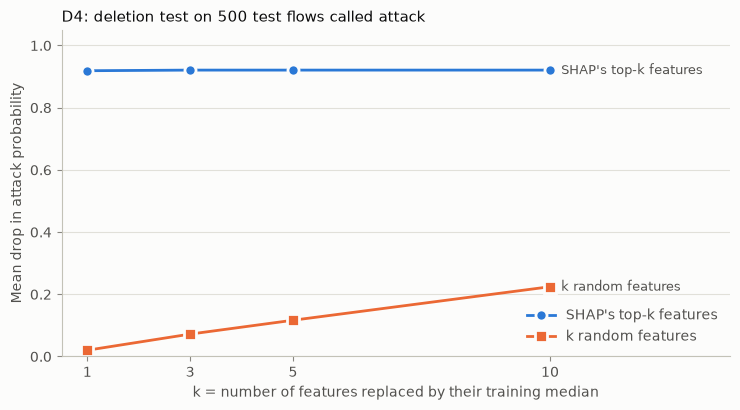

In [34]:
# STEP D4
fig, ax = plt.subplots(figsize=(7.5, 4.2), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
styles = {"SHAP": ("#2a78d6", "o", "SHAP's top-k features"),
          "random features": ("#eb6834", "s", "k random features")}
for method, (colour, marker, label) in styles.items():
    part = deletion[deletion["method"] == method]
    ax.plot(part["k"], part["mean_drop"], color=colour, marker=marker, linewidth=2, markersize=8,
            markeredgecolor="#fcfcfb", markeredgewidth=2, label=label)
    ax.annotate(label, xy=(part["k"].iloc[-1], part["mean_drop"].iloc[-1]), xytext=(8, 0),
                textcoords="offset points", va="center", color="#52514e", fontsize=9)
ax.set_xticks([1, 3, 5, 10])
ax.set_xlim(0.5, 13.5)
ax.set_ylim(0, 1.05)
ax.set_xlabel("k = number of features replaced by their training median", color="#52514e")
ax.set_ylabel("Mean drop in attack probability", color="#52514e")
ax.set_title("D4: deletion test on 500 test flows called attack", loc="left", fontsize=11, color="#0b0b0b")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("#c3c2b7")
ax.tick_params(colors="#898781", labelcolor="#52514e")
ax.legend(loc="lower right", frameon=False, labelcolor="#52514e")
fig.tight_layout()
fig.savefig(FIGURES / "D4_deletion.png", dpi=150, facecolor="#fcfcfb")
plt.show()

<!-- STEP D4 -->
### What the deletion test shows

| Features replaced (k) | SHAP's top-k: mean drop | flipped to benign | k random: mean drop | flipped to benign |
|---:|---:|---:|---:|---:|
| 1 | 0.919 | 100% | 0.020 | 2.8% |
| 3 | 0.921 | 100% | 0.072 | 8.8% |
| 5 | 0.921 | 100% | 0.117 | 13.8% |
| 10 | 0.921 | 100% | 0.224 | 25.4% |

**SHAP is faithful.** Replacing only the single feature SHAP ranks first flips every one of the 500
decisions from attack to benign, and the attack probability falls from 0.92 on average to almost 0.
Replacing ten random features changes a quarter of the decisions at most. The features SHAP points to
really are the ones the model's decisions depend on.

**But the result is also a warning about the model.** For all 500 flows the top feature is the same one,
`Fwd Seg Size Min`, and its training median is 32, the value of the *benign* machines (D1: 0% attacks in
training). So "replacing it with an ordinary value" means giving the flow a normal machine's TCP setting,
and **that single change is enough to make every attack look benign**. The other 66 features, including
all the behaviour features, cannot hold the decision on their own once the fingerprint is gone. This is
the shortcut from D1 seen as cause and effect, and it matters for Part E: an attacker who changes one TCP
setting on their own machine would likely evade this detector.

**Why the SHAP line is flat after k = 1.** After the first replacement the attack probability is already
near 0, so replacing more features has nothing left to change. The random line rises with k partly
because a random choice of 10 out of 67 features often includes `Fwd Seg Size Min` itself (in about 15%
of draws), which then flips the decision.

**Limits of this test.**
- The median is not a neutral value for this feature: it is the benign machines' setting. With a
  different "ordinary" value the drop could be smaller. The test shows that SHAP points at the decisive
  feature, not that the median is a fair stand-in.
- A flow with a changed header field but everything else unchanged may be a combination that never occurs
  in real traffic. The model has to answer anyway, so the test measures the model's reaction to edited
  flows, not to real ones.
- With one feature deciding everything, the test says little about how faithful SHAP is for the *other*
  features. The optional extra X6 (the model without the TCP-settings features) is the way to check that.

<!-- STEP D5 -->
## Part D: stability of LIME

**Question.** LIME uses randomness: it explains a flow by asking the model about 5,000 randomly changed
copies of it. If a second run with another random seed gives different top features, an analyst cannot
trust either run.

**How.** For each of the three flows from D2, LIME is run **10 times with seeds 0 to 9** (same settings
as in D3: 8 features, 5,000 samples). For each flow we report:

- **same top 3**: the share of the 10 runs whose top-3 features (by the size of their weight) are exactly
  the most common top-3 set;
- **mean overlap (Jaccard)**: for every pair of runs, the share of top-3 features they have in common,
  averaged (1 = always the same three features);
- the features that are in the top 3 of **all** 10 runs, and the fit score of each run.

For comparison, SHAP is run twice on the same flow: `TreeExplainer` is exact, so it should give identical
values every time.

In [35]:
# STEP D5
import itertools

from sklearn.utils import check_random_state


def lime_reseeded(lime, seed):
    """The same explainer, reset to a new seed: gives exactly what a new explainer with that seed gives
    (checked in H4), without the 40 s it takes to build one on all training rows."""
    rs = check_random_state(seed)
    lime.random_state = rs
    if getattr(lime, "discretizer", None) is not None:
        lime.discretizer.random_state = rs
    return lime


def lime_seed_runs(seeds, num_samples):
    """LIME on each of the three flows for each seed: {(case, seed): summary}."""
    lime = xai_tools.make_lime(X_train.to_numpy(), FEATURES, seed=0)
    return {(name, seed): xai_tools.lime_explain(lime_reseeded(lime, seed), predict_fn,
                                                 X_test.iloc[pos].to_numpy(), num_features=8,
                                                 num_samples=num_samples)[1]
            for name, pos in CASES.items() for seed in seeds}


d5_runs = cached("D5_lime_seeds", lambda: lime_seed_runs(range(10), 5000))

run_rows, summary_rows = [], []
for name, pos in CASES.items():
    tops, scores = [], []
    for seed in range(10):
        summary = d5_runs[(name, seed)]
        top3 = frozenset(summary["weights"].abs().sort_values(ascending=False).index[:3])
        tops.append(top3)
        scores.append(summary["score"])
        run_rows.append({"case": name, "seed": seed, "top3": ", ".join(sorted(top3)),
                         "fit_score": summary["score"]})
    most_common = max(set(tops), key=tops.count)
    jaccard = np.mean([len(a & b) / len(a | b) for a, b in itertools.combinations(tops, 2)])
    summary_rows.append({"case": name, "same_top3_as_most_common": tops.count(most_common) / len(tops),
                         "distinct_top3_sets": len(set(tops)), "mean_jaccard_top3": jaccard,
                         "most_common_top3": ", ".join(sorted(most_common)),
                         "in_top3_of_all_runs": ", ".join(sorted(frozenset.intersection(*tops))),
                         "fit_score_mean": np.mean(scores), "fit_score_min": np.min(scores),
                         "fit_score_max": np.max(scores)})

lime_runs = pd.DataFrame(run_rows)
lime_stability = pd.DataFrame(summary_rows).set_index("case")
lime_runs.to_csv(TABLES / "D5_lime_runs.csv", index=False, float_format="%.4f")
lime_stability.to_csv(TABLES / "D5_lime_stability.csv", float_format="%.4f")

# SHAP for comparison: two runs on the same flow.
shap_same = all(np.array_equal(explainer(X_test.iloc[[pos]]).values, explainer(X_test.iloc[[pos]]).values)
                for pos in CASES.values())
print(f"SHAP: two runs give identical values for all three flows: {shap_same}")
print("\nLIME top 3 per seed:")
print(lime_runs.pivot(index="seed", columns="case", values="top3").to_string())
lime_stability

SHAP: two runs give identical values for all three flows: True

LIME top 3 per seed:
case                                               detection                                                 mistake                                                negative
seed                                                                                                                                                                        
0     Bwd Packet Length Min, Bwd Packets/s, Fwd Seg Size Min  Bwd Packet Length Min, Bwd Packets/s, Fwd Seg Size Min  Bwd Packet Length Min, Bwd Packets/s, Fwd Seg Size Min
1     Bwd Packet Length Min, Bwd Packets/s, Fwd Seg Size Min  Bwd Packet Length Min, Bwd Packets/s, Fwd Seg Size Min  Bwd Packet Length Min, Bwd Packets/s, Fwd Seg Size Min
2     Bwd Packet Length Min, Bwd Packets/s, Fwd Seg Size Min  Bwd Packet Length Min, Bwd Packets/s, Fwd Seg Size Min       Bwd Packet Length Min, Fwd Seg Size Min, Idle Std
3     Bwd Packet Length Min, Bwd Packets/s, Fwd Se

,same_top3_as_most_common,distinct_top3_sets,mean_jaccard_top3,most_common_top3,in_top3_of_all_runs,fit_score_mean,fit_score_min,fit_score_max
case,,,,,,,,
detection,0.8,3,0.804444,"Bwd Packet Length Min, Bwd Packets/s, Fwd Seg ...",Fwd Seg Size Min,0.254037,0.241669,0.264720
negative,0.5,5,0.622222,"Bwd Packet Length Min, Bwd Packets/s, Fwd Seg ...","Bwd Packet Length Min, Fwd Seg Size Min",0.227259,0.217236,0.237370
mistake,0.8,3,0.804444,"Bwd Packet Length Min, Bwd Packets/s, Fwd Seg ...",Fwd Seg Size Min,0.255457,0.245596,0.267731


<!-- STEP D5 -->
### What the stability test shows

| Flow | Runs with the most common top 3 | Different top-3 sets | Mean overlap (Jaccard) | In the top 3 of all 10 runs | Fit score (R²) |
|---|---:|---:|---:|---|---|
| detection | 8 of 10 | 3 | 0.80 | `Fwd Seg Size Min` | 0.24 to 0.26 |
| negative | 5 of 10 | 5 | 0.62 | `Fwd Seg Size Min`, `Bwd Packet Length Min` | 0.22 to 0.24 |
| mistake | 8 of 10 | 3 | 0.80 | `Fwd Seg Size Min` | 0.25 to 0.27 |

**SHAP is perfectly stable**: two runs give identical values for all three flows, as expected from an exact
method. **LIME is only moderately stable.** For the detection and the mistake, 8 of 10 runs give the same
top 3; for the negative only half do, with five different top-3 sets. Only `Fwd Seg Size Min` is in the
top 3 of every run for every flow. The D3 explanation (seed 42) shows the same problem: for the detection
it named `RST Flag Count` in the top 3, which none of these 10 runs does. **An analyst who ran LIME once
could get a top 3 that a second run would not confirm.**

**Stable does not mean right.** Two observations show that LIME's answer here says more about LIME than
about the individual flows:
- **The most common top 3 is the same for all three flows** (`Bwd Packet Length Min`, `Bwd Packets/s`,
  `Fwd Seg Size Min`), although the detection is an attack, the negative a very different benign flow,
  and SHAP explains them with different features (D3). An explanation that is the same for very
  different flows is describing the model in general, not the flow.
- **The detection and the mistake get identical results, seed by seed.** LIME first turns every feature
  into one of four ranges (quartiles) and only sees which range a value falls in. These two flows fall
  into the same ranges on the features that matter, so LIME cannot tell them apart at all.

Together with the low fit scores in every run (0.22 to 0.27), this means LIME's straight line does not
capture what the model does near these flows. Step D6 tests why.

<!-- STEP D6 -->
## Part D: why do SHAP and LIME disagree?

D3 found that SHAP and LIME share only one or two of their top-3 features, and D5 that LIME gives almost
the same top 3 for very different flows. Four likely reasons, each tested with one experiment on the
three flows (LIME settings as in D3 unless stated):

1. **Discretisation.** By default LIME turns every feature into four ranges (quartiles of the training
   data) and only sees which range a value falls in. It also draws its random copies of the flow from
   the training data range by range, so the copies are not close to the flow. Test: LIME **without**
   discretisation, once with copies drawn around the training average (LIME's default) and once with
   copies drawn **around the flow itself** (`sample_around_instance=True`).
2. **Too few samples.** 5,000 random copies may be too few for 67 features. Test: 20,000 copies, seeds
   0 to 4, compared with the same seeds at 5,000 copies from D5.
3. **Correlated twin features.** If SHAP names one feature and LIME a near-copy of it, both are right.
   Test: the correlation (on the training set) between every SHAP-only and every LIME-only top-3 feature.
4. **Poor local fit.** If the model is far from a straight line near the flow, LIME's line cannot
   describe it. Test: LIME's fit score (R²) and its own prediction for the flow, compared with the
   model's probability, in every variant above.

For each variant we record LIME's top 3, how many it shares with SHAP's top 3, the fit score, and LIME's
local prediction next to the model's probability.

In [36]:
# STEP D6
# Experiments 1 and 4: discretisation, and the local fit of each LIME variant.
# Each variant gets a fresh explainer with seed 42, so the default variant reproduces D3 exactly
# (reusing D3's explainer would continue its random generator and give different copies).
VARIANT_SETTINGS = {
    "default (quartile ranges)": {"discretize_continuous": True},
    "no ranges, copies around the training average": {"discretize_continuous": False},
    "no ranges, copies around the flow": {"discretize_continuous": False, "sample_around_instance": True},
}


def d6_variants_lime():
    """{(variant, case): summary}; one explainer per variant with seed 42, cases in the order of CASES."""
    out = {}
    for variant, settings in VARIANT_SETTINGS.items():
        lime_obj = LimeTabularExplainer(X_train.to_numpy(), feature_names=FEATURES,
                                        class_names=["benign", "attack"], random_state=SEED, **settings)
        for name, pos in CASES.items():
            out[(variant, name)] = xai_tools.lime_explain(lime_obj, predict_fn, X_test.iloc[pos].to_numpy(),
                                                          num_features=8, num_samples=5000)[1]
    return out


d6_lime = cached("D6_lime_variants", d6_variants_lime)

rows = []
for variant in VARIANT_SETTINGS:
    for name, pos in CASES.items():
        summary = d6_lime[(variant, name)]
        lime_top3 = list(summary["weights"].abs().sort_values(ascending=False).index[:3])
        shap_top3 = list(case_shap[name].abs().sort_values(ascending=False).index[:3])
        rows.append({"experiment": "1 discretisation / 4 fit", "variant": variant, "case": name,
                     "LIME_top3": ", ".join(lime_top3), "SHAP_top3": ", ".join(shap_top3),
                     "shared_with_SHAP": len(set(lime_top3) & set(shap_top3)),
                     "fit_score": summary["score"], "LIME_local_prediction": summary["local_pred"],
                     "model_probability": summary["model_prob"]})
d6_variants = pd.DataFrame(rows)
d6_variants[["variant", "case", "shared_with_SHAP", "fit_score", "LIME_local_prediction",
             "model_probability", "LIME_top3"]].round(3)

,variant,case,shared_with_SHAP,fit_score,LIME_local_prediction,model_probability,LIME_top3
0,default (quartile ranges),detection,2,0.259,0.247,1.000,"RST Flag Count, Fwd Seg Size Min, Bwd Packets/s"
1,default (quartile ranges),negative,1,0.239,0.173,0.000,"Fwd PSH Flags, Fwd Seg Size Min, Bwd Packet Le..."
2,default (quartile ranges),mistake,1,0.253,0.237,0.999,"Fwd Seg Size Min, Bwd Packet Length Min, Bwd P..."
3,"no ranges, copies around the training average",detection,0,0.057,0.352,1.000,"Fwd Segment Size Avg, Fwd Act Data Pkts, Packe..."
4,"no ranges, copies around the training average",negative,2,0.121,0.128,0.000,"Bwd Packets/s, FWD Init Win Bytes, Fwd Seg Siz..."
5,"no ranges, copies around the training average",mistake,2,0.100,0.060,0.999,"Bwd Packets/s, Fwd Seg Size Min, FWD Init Win ..."
6,"no ranges, copies around the flow",detection,3,0.140,0.094,1.000,"Bwd Packets/s, Fwd Seg Size Min, FWD Init Win ..."
7,"no ranges, copies around the flow",negative,1,0.286,0.241,0.000,"Bwd Packets/s, Bwd Packet Length Min, Bwd Pack..."
8,"no ranges, copies around the flow",mistake,2,0.070,0.041,0.999,"FWD Init Win Bytes, Bwd Packets/s, Fwd Seg Siz..."


In [37]:
# STEP D6
# Experiment 2: more samples. Seeds 0 to 4 with 20,000 copies, against the same seeds with 5,000 (D5).
d6_runs_20k = cached("D6_lime_seeds_20000", lambda: lime_seed_runs(range(5), 20000))

rows = []
for name, pos in CASES.items():
    tops_20k, scores_20k = [], []
    for seed in range(5):
        summary = d6_runs_20k[(name, seed)]
        tops_20k.append(frozenset(summary["weights"].abs().sort_values(ascending=False).index[:3]))
        scores_20k.append(summary["score"])
    tops_5k = [frozenset(t.split(", ")) for t in
               lime_runs.query("case == @name and seed < 5").sort_values("seed")["top3"]]
    shap_top3 = set(case_shap[name].abs().sort_values(ascending=False).index[:3])
    for label, tops in (("5,000 samples", tops_5k), ("20,000 samples", tops_20k)):
        most_common = max(set(tops), key=tops.count)
        rows.append({"case": name, "samples": label,
                     "same_top3_as_most_common": tops.count(most_common) / len(tops),
                     "mean_jaccard_top3": np.mean([len(a & b) / len(a | b)
                                                   for a, b in itertools.combinations(tops, 2)]),
                     "mean_shared_with_SHAP": np.mean([len(t & shap_top3) for t in tops]),
                     "fit_score_mean": (np.mean(scores_20k) if label.startswith("20") else
                                        lime_runs.query("case == @name and seed < 5")["fit_score"].mean())})
d6_samples = pd.DataFrame(rows)
d6_samples.round(3)

,case,samples,same_top3_as_most_common,mean_jaccard_top3,mean_shared_with_SHAP,fit_score_mean
0,detection,"5,000 samples",0.8,0.80,2.0,0.256
1,detection,"20,000 samples",0.6,0.65,2.0,0.254
2,negative,"5,000 samples",0.6,0.65,1.6,0.229
3,negative,"20,000 samples",0.6,0.65,1.6,0.229
4,mistake,"5,000 samples",0.8,0.80,1.0,0.258
5,mistake,"20,000 samples",0.8,0.80,1.0,0.253


In [38]:
# STEP D6
# Experiment 3: twins. Correlation on the training set between each feature only SHAP has in its top 3
# and each feature only LIME has (default LIME, D3).
rows = []
for name in CASES:
    shap_top3 = set(case_shap[name].abs().sort_values(ascending=False).index[:3])
    lime_top3 = set(case_lime[name]["weights"].abs().sort_values(ascending=False).index[:3])
    for f_shap in sorted(shap_top3 - lime_top3):
        for f_lime in sorted(lime_top3 - shap_top3):
            rows.append({"case": name, "SHAP_only": f_shap, "LIME_only": f_lime,
                         "abs_correlation": abs(X_train[f_shap].corr(X_train[f_lime])),
                         "same_twin_group": (GLOSSARY.loc[f_shap, "twin_group"] == GLOSSARY.loc[f_lime, "twin_group"])
                                            if pd.notna(GLOSSARY.loc[f_shap, "twin_group"]) else False})
d6_twins = pd.DataFrame(rows)

# One table with every experiment for the report.
investigation = pd.concat([
    d6_variants.assign(experiment="1 discretisation and 4 local fit"),
    d6_samples.assign(experiment="2 number of samples"),
    d6_twins.assign(experiment="3 twins"),
], ignore_index=True)
investigation.to_csv(TABLES / "D6_investigation.csv", index=False, float_format="%.4f")
d6_twins.round(3)

,case,SHAP_only,LIME_only,abs_correlation,same_twin_group
0,detection,FWD Init Win Bytes,RST Flag Count,0.027,False
1,negative,Bwd IAT Min,Bwd Packet Length Min,0.001,False
2,negative,Bwd IAT Min,Fwd PSH Flags,0.068,False
3,negative,Bwd Packets/s,Bwd Packet Length Min,0.017,False
4,negative,Bwd Packets/s,Fwd PSH Flags,0.007,False
5,mistake,FWD Init Win Bytes,Bwd Packet Length Min,0.298,False
6,mistake,FWD Init Win Bytes,Bwd Packets/s,0.300,False
7,mistake,Total Length of Bwd Packet,Bwd Packet Length Min,0.053,False
8,mistake,Total Length of Bwd Packet,Bwd Packets/s,0.071,False


<!-- STEP D6 -->
### What the four experiments show

**1. Discretisation: part of the reason.** With LIME's default quartile ranges, LIME shares 2, 1 and 1 of
its top 3 with SHAP (detection, negative, mistake; the same as in D3). Without ranges, and with the random
copies drawn **around the flow itself**, LIME's top 3 for the detection becomes exactly SHAP's
(`Fwd Seg Size Min`, `FWD Init Win Bytes`, `Bwd Packets/s`, 3 of 3) and for the mistake 2 of 3. Both
now include `FWD Init Win Bytes`, which the default LIME never ranks highly, because its ranges put the
attacker value 16,383 and the benign value 5,792 into neighbouring ranges. So the ranges and the way LIME
draws its copies do hide what the model uses. But removing them does not make LIME *fit* better (point 4):
the fit scores get lower (0.06 to 0.29), and with copies around the training average LIME agrees with
SHAP on nothing for the detection.

**2. Too few samples: not the reason.** With 20,000 instead of 5,000 copies, stability does not improve
(same top 3 in 3 of 5 runs for the detection instead of 4 of 5, unchanged for the other two flows), the
overlap with SHAP's top 3 stays the same (2, 1.6 and 1 on average), and so does the fit (about 0.25).
More copies only estimate the same poorly fitting straight line more precisely.

**3. Twin features: not the reason.** Where SHAP and LIME name different features, the two are almost
unrelated: the correlation on the training set is at most 0.30 (`FWD Init Win Bytes` against
`Bwd Packets/s`), and no pair is in the same twin group of the glossary. The methods are not naming two
copies of one signal; they really point at different features.

**4. Poor local fit: the main reason.** In every variant LIME's fit score stays between 0.06 and 0.29,
and its own prediction for the flow is far from the model's: for the detection 0.25 (default), 0.35 and
0.09, where the model says 1.00. A straight line cannot describe this model near these flows, because the
model is not smooth there: it behaves like a switch. Changing `Fwd Seg Size Min` from 20 to 32 moves an
attack probability from almost 1 to almost 0 (D4), with nothing in between. LIME's line averages over
such jumps and ends up describing neither side.

**Conclusion.** SHAP and LIME disagree mainly because **LIME's straight line does not fit this
switch-like model** (reason 4), made worse by **LIME's quartile ranges and its random copies far from the
flow** (reason 1). More samples (reason 2) and correlated features (reason 3) do not explain it.

**Which method would we show an analyst? SHAP.** For tree models it is exact (its contributions add up to
the model's output, checked in D1), stable (identical on every run, D5) and faithful (removing its top
feature flips every decision, D4). LIME is unstable (D5), fits poorly in every variant tried here, and
gives nearly the same explanation for very different flows. LIME's conditions such as
"`Fwd Seg Size Min` ≤ 20" are easier to read, but here they are not reliable enough to act on. And both
methods, when they work, point at the same uncomfortable fact: the decision rests on the attacker
machines' TCP settings.

<!-- STEP E1 -->
## Part E: robustness to measurement noise

Everything so far tested the models on clean data. A real sensor measures slightly wrong: clocks drift,
packets are counted twice or missed. **How much measurement error can the models take before they stop
working?**

**How.** We add random **Gaussian noise** to every continuous feature of the **test** set. The size of
the noise is a share (the *level*) of that feature's **training** standard deviation: at level 0.10, a
feature with a standard deviation of 1,000 gets errors of typically ±100. The models are not retrained;
they see noisy versions of flows they were trained to judge on clean data.

- Levels: 0 (clean), 0.05, 0.10, 0.20, 0.50 and 1.00.
- The two 0/1 columns (`Fwd PSH Flags`, `RST Flag Count`) are left alone: a flag is either set or not.
- Values below 0 are set to 0: none of our features is ever negative (packet counts, sizes, times).
- The same noise (seed 42) is used for all three models at a given level, so they are compared on
  identical flows.

Step E3 reads the results: what broke first, and at which level we would stop trusting the model.

In [39]:
# STEP E1
def add_noise(X, level, seed=SEED):
    """Copy of X with Gaussian noise of width level * (training std) on every continuous column.

    The 0/1 columns are not touched, and values are clipped at 0 (no feature is ever negative).
    """
    noisy = X.copy()
    if level == 0:
        return noisy
    rng = np.random.default_rng(seed)
    values = noisy[CONT_COLS].to_numpy(dtype=float, copy=True)   # pandas 3 arrays are read-only
    values += rng.standard_normal(values.shape) * (level * TRAIN_STD[CONT_COLS].to_numpy())
    noisy[CONT_COLS] = np.maximum(values, 0.0)
    return noisy


# Checks: level 0 changes nothing, flags are untouched, nothing becomes negative.
_check = add_noise(X_test.iloc[:2000], 0.5)
assert add_noise(X_test.iloc[:2000], 0.0).equals(X_test.iloc[:2000])
assert _check[FLAG_COLS].equals(X_test.iloc[:2000][FLAG_COLS])
assert (_check.to_numpy() >= 0).all()

# What a noise level means for the three most important features (D1): the training median and the
# typical size of the noise at levels 0.05 and 0.20.
scale = pd.DataFrame({"training_median": TRAIN_MEDIAN, "training_std": TRAIN_STD,
                      "noise_at_0.05": 0.05 * TRAIN_STD, "noise_at_0.20": 0.20 * TRAIN_STD})
scale.loc[["Fwd Seg Size Min", "FWD Init Win Bytes", "Bwd Packets/s", "Flow Duration"]].round(1)

,training_median,training_std,noise_at_0.05,noise_at_0.20
Fwd Seg Size Min,32.0,8.7,0.4,1.7
FWD Init Win Bytes,5792.0,10661.0,533.0,2132.2
Bwd Packets/s,296.7,2159.0,108.0,431.8
Flow Duration,53666.0,5975445.4,298772.3,1195089.1


In [40]:
# STEP E1
NOISE_LEVELS = [0.0, 0.05, 0.10, 0.20, 0.50, 1.00]
MODELS_TAG = f"tree{tree.max_depth}_logregC{logreg[-1].C}_{BOOST_TAG}"     # for cache names (H4)


def noise_sweep(levels):
    """The three models on the noisy test set at each level."""
    rows = []
    for level in levels:
        X_noisy = add_noise(X_test, level)
        for name, model in MODELS.items():
            rows.append({"level": level, "model": name, **score(model, X_noisy, y_test)})
    return pd.DataFrame(rows)


# Scoring three models on 61,021 noisy flows per level takes a while, so the table is cached (H4).
noise_results = cached(f"E1_noise_{MODELS_TAG}", lambda: noise_sweep(NOISE_LEVELS))
noise_results.to_csv(TABLES / "E1_noise.csv", index=False, float_format="%.4f")

for metric in ["macro_f1", "recall", "far", "pr_auc"]:
    print(metric)
    print(noise_results.pivot(index="model", columns="level", values=metric)
          .loc[["boosting", "tree", "logreg"]].round(4).to_string(), "\n")

macro_f1
level       0.00    0.05    0.10    0.20    0.50    1.00
model                                                   
boosting  0.9718  0.6618  0.5878  0.5147  0.4563  0.4497
tree      0.9690  0.4727  0.4626  0.4627  0.4601  0.4682
logreg    0.9608  0.9164  0.8477  0.7619  0.6513  0.5847 

recall
level       0.00    0.05    0.10    0.20    0.50    1.00
model                                                   
boosting  0.9923  0.3035  0.1962  0.1043  0.0422  0.0406
tree      0.9849  0.0835  0.0715  0.0850  0.1227  0.1480
logreg    0.9962  0.8490  0.6794  0.5304  0.4117  0.3684 

far
level       0.00    0.05    0.10    0.20    0.50    1.00
model                                                   
boosting  0.0276  0.0217  0.0220  0.0229  0.0324  0.0471
tree      0.0279  0.0816  0.0832  0.1096  0.1793  0.1968
logreg    0.0413  0.0324  0.0334  0.0553  0.1282  0.2021 

pr_auc
level       0.00    0.05    0.10    0.20    0.50    1.00
model                                                  

In [41]:
# STEP E1
# Which features does the noise hurt? Noise at level 0.05 on only the three TCP-settings features
# (the attacker fingerprint, D1), and on all other continuous features but not those three.
TCP_SETTINGS = ["Fwd Seg Size Min", "FWD Init Win Bytes", "Bwd Init Win Bytes"]


def add_noise_to(X, columns, level, seed=SEED):
    """Like add_noise, but only on the given columns (same noise for a column as in add_noise)."""
    noisy = add_noise(X, level, seed)
    keep = [c for c in CONT_COLS if c not in columns]
    noisy[keep] = X[keep]
    return noisy


def noise_where_table():
    rows = []
    for label, cols in [("all continuous features", CONT_COLS), ("only the 3 TCP-settings features", TCP_SETTINGS),
                        ("all except the 3 TCP-settings features", [c for c in CONT_COLS if c not in TCP_SETTINGS])]:
        X_noisy = add_noise_to(X_test, cols, 0.05)
        for name, model in MODELS.items():
            rows.append({"noise at level 0.05 on": label, "model": name, **score(model, X_noisy, y_test)})
    return pd.DataFrame(rows)


noise_where = cached(f"E1_noise_where_{MODELS_TAG}", noise_where_table)
noise_where.to_csv(TABLES / "E1_noise_where.csv", index=False, float_format="%.4f")

# How many test values are exactly 0 (any noise moves them off 0)?
zero_share = float((X_test[CONT_COLS] == 0).to_numpy().mean())
print(f"Share of continuous test values that are exactly 0: {zero_share:.1%}")
noise_where.pivot(index="noise at level 0.05 on", columns="model", values="recall").round(4)

Share of continuous test values that are exactly 0: 34.8%


model,boosting,logreg,tree
noise at level 0.05 on,,,
all continuous features,0.3035,0.8490,0.0835
all except the 3 TCP-settings features,0.8208,0.8489,0.7121
only the 3 TCP-settings features,0.4222,0.9956,0.0753


<!-- STEP E1 -->
### What the noise test shows

| Recall (test) at noise level | 0 | 0.05 | 0.10 | 0.20 | 0.50 | 1.00 |
|---|---:|---:|---:|---:|---:|---:|
| Gradient boosting | 0.992 | **0.304** | 0.196 | 0.104 | 0.042 | 0.041 |
| Decision tree | 0.985 | **0.084** | 0.072 | 0.085 | 0.123 | 0.148 |
| Logistic regression | 0.996 | 0.849 | 0.679 | 0.530 | 0.412 | 0.368 |

| Macro-F1 (test) at noise level | 0 | 0.05 | 0.10 | 0.20 | 0.50 | 1.00 |
|---|---:|---:|---:|---:|---:|---:|
| Gradient boosting | 0.972 | 0.662 | 0.588 | 0.515 | 0.456 | 0.450 |
| Decision tree | 0.969 | 0.473 | 0.463 | 0.463 | 0.460 | 0.468 |
| Logistic regression | 0.961 | 0.916 | 0.848 | 0.762 | 0.651 | 0.585 |

**The two tree models collapse at the smallest noise level.** With noise of only 5% of each feature's
standard deviation, gradient boosting catches 30% of the attacks instead of 99%, and the decision tree
8%. Their macro-F1 falls close to the always-benign baseline (0.424). **Logistic regression degrades
gradually**: it still catches 85% of the attacks at level 0.05 and 53% at 0.20, and keeps the best
macro-F1 at every noise level. The ranking of Part B is reversed: the best model on clean data is one of
the most fragile.

**Why: the tree models match exact values.** The diagnostic table above adds noise at level 0.05 to only
some features:

| Recall at level 0.05, noise on | Gradient boosting | Decision tree | Logistic regression |
|---|---:|---:|---:|
| all continuous features | 0.304 | 0.084 | 0.849 |
| **only the 3 TCP-settings features** | **0.422** | **0.075** | 0.996 |
| all features except those 3 | 0.821 | 0.712 | 0.849 |

Noise on just the three TCP-settings features does most of the damage. The fingerprint (D1) is an
*exact* value, for example a window of 16,383 bytes, and the decision tree tests for a narrow interval
around it (16,368.5 to 16,406.5, B1). A measurement error of a few hundred bytes moves the value out of
that interval, and the flow no longer looks like it comes from an attacker machine. The rest of the
features matter too (recall 0.82 and 0.71 with noise everywhere else): 35% of all test values are exactly
0, and the trees split on "is it 0 or more?", so any positive noise flips those answers. Logistic
regression uses smooth weights instead of exact thresholds, so small errors only shift its score a little.

**The models fail by missing attacks, not by raising alarms.** Gradient boosting's FAR stays between
0.02 and 0.05 at every level: noisy attacks look benign to it. The tree's FAR rises to 0.20 at level 1.0.

**What this means.** Noise of 5% of a standard deviation is small; for `FWD Init Win Bytes` it is about
±530 bytes. Real TCP header fields are recorded exactly and would not drift like this, but timing and
rate features (`Flow Duration`, `Bwd Packets/s`) are measured and can be noisy. The result shows how
narrow the tree models' reasoning is: they work only as long as the fingerprint values arrive exactly as
in training. Step E3 compares this with missing features and decides where to stop trusting the model.

<!-- STEP E2 -->
## Part E: robustness to missing features

A sensor can also fail to record a field at all: a counter is not exported, a timer is lost. A common
fix is to fill the gap with an "ordinary" value, the feature's **training median**. **How many missing
fields can the models take?**

**How.** In every **test** flow we pick a share of the 67 features at random and replace them with their
training median. Each flow gets its own random choice (seed 42); the same choice is used for all three
models at a given level. The models are not retrained.

| Level (share of features missing) | 0 | 0.10 | 0.20 | 0.30 | 0.50 |
|---|---:|---:|---:|---:|---:|
| Features replaced per flow | 0 | 7 | 13 | 20 | 34 |

One thing to keep in mind from D4: the training median of the most important feature, `Fwd Seg Size
Min`, is 32, the value of the *benign* machines. When this feature goes missing and is filled with its
median, the flow loses the attacker fingerprint. A second table below therefore splits the attacks by
whether `Fwd Seg Size Min` was among the missing features.

In [42]:
# STEP E2
def missing_mask(n_rows, frac, seed=SEED):
    """(n_rows, n_features) True where a feature is missing: round(frac * 67) random features per row."""
    k = int(round(frac * len(FEATURES)))
    mask = np.zeros((n_rows, len(FEATURES)), dtype=bool)
    if k > 0:
        rng = np.random.default_rng(seed)
        # k random features per row: the positions of the k smallest of a row of random numbers.
        cols = np.argpartition(rng.random((n_rows, len(FEATURES))), k - 1, axis=1)[:, :k]
        mask[np.arange(n_rows)[:, None], cols] = True
    return mask


def add_missing(X, frac, seed=SEED):
    """Copy of X where round(frac * 67) random features per row are replaced by their training median."""
    values = X.to_numpy(dtype=float, copy=True)                 # copy: pandas 3 arrays are read-only
    mask = missing_mask(len(X), frac, seed)
    medians = np.broadcast_to(TRAIN_MEDIAN[FEATURES].to_numpy(), values.shape)
    values[mask] = medians[mask]
    return pd.DataFrame(values, index=X.index, columns=X.columns)


# Checks: level 0 changes nothing; at level 0.10 exactly 7 features per row were chosen.
assert add_missing(X_test.iloc[:2000], 0.0).equals(X_test.iloc[:2000])
assert (missing_mask(2000, 0.10).sum(axis=1) == 7).all()

MISSING_LEVELS = [0.0, 0.10, 0.20, 0.30, 0.50]


def missing_sweep(levels):
    """The three models on the test set with a share of the features missing, at each level."""
    rows = []
    for frac in levels:
        X_missing = add_missing(X_test, frac)
        for name, model in MODELS.items():
            rows.append({"level": frac, "features_missing": int(round(frac * len(FEATURES))), "model": name,
                         **score(model, X_missing, y_test)})
    return pd.DataFrame(rows)


missing_results = cached(f"E2_missing_{MODELS_TAG}", lambda: missing_sweep(MISSING_LEVELS))
missing_results.to_csv(TABLES / "E2_missing.csv", index=False, float_format="%.4f")

for metric in ["macro_f1", "recall", "far", "pr_auc"]:
    print(metric)
    print(missing_results.pivot(index="model", columns="level", values=metric)
          .loc[["boosting", "tree", "logreg"]].round(4).to_string(), "\n")

macro_f1
level        0.0     0.1     0.2     0.3     0.5
model                                           
boosting  0.9718  0.9080  0.8514  0.7856  0.6543
tree      0.9690  0.9059  0.8540  0.7999  0.7066
logreg    0.9608  0.8853  0.8234  0.7606  0.6500 

recall
level        0.0     0.1     0.2     0.3     0.5
model                                           
boosting  0.9923  0.8092  0.6656  0.5196  0.2832
tree      0.9849  0.8161  0.6919  0.5770  0.3997
logreg    0.9962  0.8238  0.6978  0.5849  0.3933 

far
level        0.0     0.1     0.2     0.3     0.5
model                                           
boosting  0.0276  0.0248  0.0223  0.0196  0.0136
tree      0.0279  0.0301  0.0322  0.0358  0.0391
logreg    0.0413  0.0572  0.0717  0.0899  0.1155 

pr_auc
level        0.0     0.1     0.2     0.3     0.5
model                                           
boosting  0.9814  0.9472  0.9065  0.8491  0.7176
tree      0.9677  0.8097  0.7049  0.6124  0.4972
logreg    0.9527  0.8412  0.7551  0.

In [43]:
# STEP E2
# Recall on the test attacks, split by whether Fwd Seg Size Min was one of the missing features.
SEG = FEATURES.index("Fwd Seg Size Min")
attack_rows = (y_test == 1).to_numpy()


def missing_split_table():
    rows = []
    for frac in MISSING_LEVELS[1:]:
        mask = missing_mask(len(X_test), frac)
        X_missing = add_missing(X_test, frac)
        seg_missing = mask[:, SEG]
        for name, model in MODELS.items():
            pred = model.predict(X_missing)
            rows.append({"level": frac, "model": name,
                         "attacks_with_seg_missing": int((attack_rows & seg_missing).sum()),
                         "recall_seg_missing": float(pred[attack_rows & seg_missing].mean()),
                         "recall_seg_present": float(pred[attack_rows & ~seg_missing].mean())})
    return pd.DataFrame(rows)


missing_split = cached(f"E2_missing_split_{MODELS_TAG}", missing_split_table)
missing_split.to_csv(TABLES / "E2_missing_split.csv", index=False, float_format="%.4f")
missing_split.round(4)

,level,model,attacks_with_seg_missing,recall_seg_missing,recall_seg_present
0,0.1,tree,1667,0.8026,0.8161
1,0.1,logreg,1667,0.1566,0.9011
2,0.1,boosting,1667,0.0000,0.9030
3,0.2,tree,3110,0.6900,0.6905
4,0.2,logreg,3110,0.1752,0.8234
5,0.2,boosting,3110,0.0000,0.8255
6,0.3,tree,4751,0.5748,0.5758
7,0.3,logreg,4751,0.1661,0.7610
8,0.3,boosting,4751,0.0000,0.7381
9,0.5,tree,8132,0.3935,0.4044


<!-- STEP E2 -->
### What the missing-feature test shows

| Test set, share of features missing | 0 | 0.10 | 0.20 | 0.30 | 0.50 |
|---|---:|---:|---:|---:|---:|
| Recall: gradient boosting | 0.992 | 0.809 | 0.666 | 0.520 | 0.283 |
| Recall: decision tree | 0.985 | 0.816 | 0.692 | 0.577 | 0.400 |
| Recall: logistic regression | 0.996 | 0.824 | 0.698 | 0.585 | 0.393 |
| Macro-F1: gradient boosting | 0.972 | 0.908 | 0.851 | 0.786 | 0.654 |
| Macro-F1: decision tree | 0.969 | 0.906 | 0.854 | 0.800 | 0.707 |
| Macro-F1: logistic regression | 0.961 | 0.885 | 0.823 | 0.761 | 0.650 |
| FAR: gradient boosting | 0.028 | 0.025 | 0.022 | 0.020 | 0.014 |
| FAR: decision tree | 0.028 | 0.030 | 0.032 | 0.036 | 0.039 |
| FAR: logistic regression | 0.041 | 0.057 | 0.072 | 0.090 | 0.116 |

**Missing features hurt all three models, at about the same rate.** With 10% of the features missing (7
per flow), every model loses almost a fifth of its detections (recall about 0.81 instead of 0.99). With
half missing, they catch only 28 to 40% of the attacks. Unlike noise (E1), there is no sudden collapse:
the damage grows steadily with the number of missing fields. At the high levels the decision tree holds
up best (macro-F1 0.71 at 50%), gradient boosting worst on recall (0.28).

**The fingerprint again decides.** The split table shows what happens to an attack when
`Fwd Seg Size Min` is one of its missing features and is filled with the median 32, the benign machines'
value:

| Recall on attacks, `Fwd Seg Size Min` | missing | present |
|---|---:|---:|
| Gradient boosting (level 0.10) | **0.000** | 0.903 |
| Decision tree (level 0.10) | 0.803 | 0.816 |
| Logistic regression (level 0.10) | 0.157 | 0.901 |

**Gradient boosting misses every attack whose `Fwd Seg Size Min` went missing**, at every level: the
single replaced value outweighs the 60 or so features that are still there (the same as the deletion
test in D4). Logistic regression misses most of them too. The decision tree does not care, because its
first question is about `FWD Init Win Bytes` (B1), not `Fwd Seg Size Min`. Even with
`Fwd Seg Size Min` present, recall drops (0.90 at level 0.10), largely because `FWD Init Win Bytes` can
go missing as well and its median, 5,792, is also a benign machine's value.

**Missing values push the models towards "benign".** Filling with medians makes a flow look ordinary,
so recall falls while gradient boosting's FAR even goes down. Logistic regression is the exception: its
FAR rises from 0.04 to 0.12, because some medians push its weighted sum towards "attack".

**What this means.** Median filling is a common default, but here it is not neutral: the median of the
most important features is the benign machines' setting, so every missing fingerprint field quietly turns
an attack into "normal traffic". A safer system would mark a flow with missing key fields as "unknown"
instead of filling it in, which is what the belief rule base in Part F can do. Step E3 decides at which
level to stop trusting the model.

<!-- STEP E3 -->
## Part E: what broke first, and when do we stop trusting the model?

**The rule for "stop trusting"** was written down in the project plan on 9 October, before any of the
robustness tests were run, and is used here unchanged:

> A model is no longer trusted at the first tested level where its **recall falls more than 0.05 below
> its clean score**, or its **false alarm rate (FAR) is more than twice its clean value**.

Recall matters because missed attacks are the most expensive mistake; the FAR part catches the opposite
failure, a flood of false alarms (B4: already about half of the alerts would be false in real traffic).

**A finer sweep.** In E1 and E2 every model already breaks this rule at the first level tested (noise
level 0.05, 7 missing features), so those levels cannot show *where* trust is lost. We therefore add
smaller levels: noise of 0.001, 0.0025, 0.005, 0.01 and 0.02 standard deviations, and 1, 2, 3 and 5
missing features per flow. Everything else (seed, models, test set) is as in E1 and E2.

In [44]:
# STEP E3
FINE_NOISE = [0.001, 0.0025, 0.005, 0.01, 0.02]
FINE_MISSING = [1, 2, 3, 5]                                      # features per flow

fine = pd.concat([cached(f"E3_fine_noise_{MODELS_TAG}", lambda: noise_sweep(FINE_NOISE)).assign(test="noise"),
                  cached(f"E3_fine_missing_{MODELS_TAG}",
                         lambda: missing_sweep([k / len(FEATURES) for k in FINE_MISSING]))
                  .drop(columns="features_missing").assign(test="missing")], ignore_index=True)

robust = pd.concat([fine,
                    noise_results.assign(test="noise"),
                    missing_results.drop(columns="features_missing").assign(test="missing")],
                   ignore_index=True)
robust["features_missing"] = np.where(robust["test"] == "missing",
                                      (robust["level"] * len(FEATURES)).round().astype(int), 0)
robust = robust.sort_values(["test", "model", "level"]).reset_index(drop=True)
robust = robust[["test", "level", "model", "accuracy", "macro_f1", "recall", "pr_auc", "far",
                 "features_missing"]]
robust.to_csv(TABLES / "E3_robustness_all_levels.csv", index=False, float_format="%.4f")

# Apply the rule: first level where recall < clean - 0.05 or FAR > 2 x clean.
verdict_rows = []
for (test, name), part in robust.groupby(["test", "model"]):
    clean = part[part["level"] == 0].iloc[0]
    broken = part[(part["recall"] < clean["recall"] - 0.05) | (part["far"] > 2 * clean["far"])]
    first = broken.iloc[0] if len(broken) else None
    last_ok = part[(part["level"] > 0) & (part["level"] < (first["level"] if first is not None else np.inf))]
    verdict_rows.append({
        "test": test, "model": name,
        "last_trusted_level": last_ok["level"].max() if len(last_ok) else 0.0,
        "first_untrusted_level": first["level"] if first is not None else np.nan,
        "broke_on": (None if first is None else
                     " and ".join(m for m, hit in [("recall", first["recall"] < clean["recall"] - 0.05),
                                                   ("FAR", first["far"] > 2 * clean["far"])] if hit)),
        "recall_there": first["recall"] if first is not None else np.nan,
        "far_there": first["far"] if first is not None else np.nan})
trust = pd.DataFrame(verdict_rows)
trust.to_csv(TABLES / "E3_stop_trusting.csv", index=False, float_format="%.4f")
trust

,test,model,last_trusted_level,first_untrusted_level,broke_on,recall_there,far_there
0,missing,boosting,0.014925,0.029851,recall,0.939821,0.026730
1,missing,logreg,0.029851,0.044776,recall,0.920072,0.046299
2,missing,tree,0.014925,0.029851,recall,0.931473,0.028397
3,noise,boosting,0.000000,0.001000,recall,0.512771,0.012764
4,noise,logreg,0.020000,0.050000,recall,0.848991,0.032356
5,noise,tree,0.000000,0.001000,recall and FAR,0.859768,0.067491


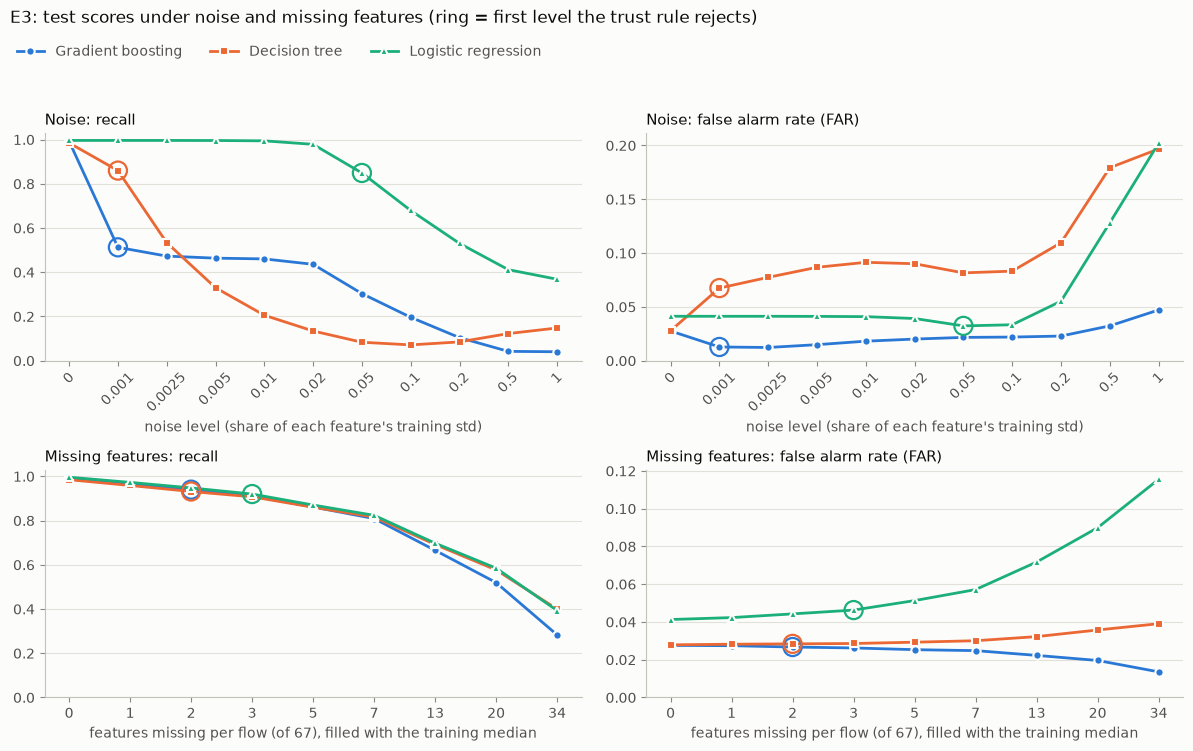

In [45]:
# STEP E3
# Recall and FAR against the level, for noise (top) and missing features (bottom). The levels are spread
# evenly along the x axis (they grow roughly by factors of 2), with their values as labels.
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5), facecolor=SURFACE)
for row, test in enumerate(["noise", "missing"]):
    part_all = robust[robust["test"] == test]
    levels = sorted(part_all["level"].unique())
    xpos = {lvl: i for i, lvl in enumerate(levels)}
    labels = ([f"{l:g}" for l in levels] if test == "noise"
              else [f"{int(round(l * len(FEATURES)))}" for l in levels])
    for col, metric in enumerate(["recall", "far"]):
        ax = axes[row, col]
        style_axes(ax)
        for name in ["boosting", "tree", "logreg"]:
            part = part_all[part_all["model"] == name]
            ax.plot([xpos[l] for l in part["level"]], part[metric], color=MODEL_COLORS[name],
                    marker=MODEL_MARKERS[name], markersize=6, linewidth=2, markeredgecolor=SURFACE,
                    markeredgewidth=1.5, label=MODEL_LABELS[name])
            first = trust.query("test == @test and model == @name")["first_untrusted_level"].iloc[0]
            if pd.notna(first):                       # open ring: first level the rule rejects
                y_first = part.loc[part["level"] == first, metric].iloc[0]
                ax.scatter([xpos[first]], [y_first], s=170, facecolors="none",
                           edgecolors=MODEL_COLORS[name], linewidths=1.6, zorder=4)
        ax.set_xticks(range(len(levels)), labels, rotation=45 if test == "noise" else 0)
        ax.set_ylim(0, 1.03 if metric == "recall" else None)
        ax.set_xlabel("noise level (share of each feature's training std)" if test == "noise"
                      else "features missing per flow (of 67), filled with the training median",
                      color=INK_2)
        ax.set_title(f"{'Noise' if test == 'noise' else 'Missing features'}: "
                     f"{'recall' if metric == 'recall' else 'false alarm rate (FAR)'}",
                     loc="left", fontsize=11, color=INK)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.suptitle("E3: test scores under noise and missing features (ring = first level the trust rule rejects)",
             x=0.01, y=0.995, ha="left", fontsize=12, color=INK)
# Legend on its own line under the title, so it never overlaps the title or a panel.
fig.legend(handles, labels, loc="upper left", ncol=3, frameon=False, labelcolor=INK_2,
           bbox_to_anchor=(0.005, 0.965))
fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.savefig(FIGURES / "E3_robustness.png", dpi=150, facecolor=SURFACE)
plt.show()

<!-- STEP E3 -->
### What broke first, and where we stop trusting the model

| Test | Model | Last level still trusted | First level rejected | Broke on |
|---|---|---|---|---|
| Noise | Gradient boosting | none (fails at the smallest level) | 0.001 (recall 0.51) | recall |
| Noise | Decision tree | none (fails at the smallest level) | 0.001 (recall 0.86, FAR 0.068) | recall and FAR |
| Noise | Logistic regression | 0.02 (recall 0.98) | 0.05 (recall 0.85) | recall |
| Missing | Gradient boosting | 1 feature (recall 0.97) | 2 features (recall 0.94) | recall |
| Missing | Decision tree | 1 feature (recall 0.96) | 2 features (recall 0.93) | recall |
| Missing | Logistic regression | 2 features (recall 0.95) | 3 features (recall 0.92) | recall |

**What broke first: noise, and in particular the two tree models under noise.** Gradient boosting and the
decision tree already fail the rule at the smallest noise we tried, one thousandth of a standard
deviation: gradient boosting then catches only 51% of the attacks. Logistic regression keeps a recall
of 0.98 up to noise level 0.02, twenty times more noise. Missing features hurt all three models gradually
and in the same way: one missing field per flow is tolerated, two or three are not.

**The metric that broke first was recall in every case.** The models do not start raising floods of
false alarms; they quietly stop seeing attacks (only the decision tree also doubles its FAR under noise).
That is the dangerous kind of failure for a SOC: the alert count goes *down*, which looks like good news.

**Where we would stop trusting the models:**
- **Gradient boosting** (the best model on clean data): as soon as the measurements are not exactly the
  values it was trained on, or as soon as **2 or more fields per flow** are missing and filled in. In
  practice it is only usable on data recorded by exactly the same tool, in exactly the same way, as the
  training data.
- **Decision tree**: the same.
- **Logistic regression**: up to noise of about **2% of a standard deviation** and **2 missing fields**
  per flow. It is the most robust of the three, at the price of the highest FAR on clean data (0.041).

**Why** (E1, E2): the tree models' decisions hinge on exact values, the attacker fingerprint
(`Fwd Seg Size Min` = 20, window = 16,383) and the many exact zeros, so tiny changes push flows across
their thresholds. Filling a missing fingerprint field with its median (the benign machines' value)
removes the evidence altogether.

**Limits.** The levels are a grid, so "first rejected level" is only as fine as the grid; one random seed
was used; and real TCP header fields are recorded exactly, so for those fields noise is less realistic
than for timing and rate features. The finding still holds: the most accurate model is also the most
fragile one, and a deployment would need either exact, unchanged measurements or a more robust model.

<!-- STEP E4 -->
## Part E: what could an attacker change?

The discussion has to answer "what would an attacker fake?". An attacker controls only **their own side
of the conversation**: what their machine sends, how fast, and how their operating system is set up.
They do not control what the victim sends back, and changing some things makes the attack slower or
louder. We sort the 15 features that matter most to the black box (D1) into three groups:

- **Free**: the attacker can change it cheaply, without hurting the attack: timing (wait longer between
  packets), the sizes of their own packets (padding), and **their own machine's TCP settings** (one
  system setting).
- **Costly**: possible, but it slows the attack down or makes it louder (more packets or bytes), or the
  attacker controls only part of the feature.
- **Fixed**: the attacker cannot change it: the victim's replies (`Bwd ...`) and flags set by the network
  software of both sides.

The starting point is the proposal in the feature glossary (T4); a few features are re-judged by hand,
with the reason written next to them. Then we measure how much of the model's SHAP weight sits in each
group, and run a quick what-if: what happens if attackers simply copy the TCP settings of the benign
machines?

In [46]:
# STEP E4
# Re-judged by hand (the other features keep the glossary's proposed group and its rule).
GROUP_OVERRIDES = {
    "Fwd Seg Size Min": ("Free", "header size of the attacker's own packets: set by their operating "
                                 "system's TCP options, one setting"),
    "FWD Init Win Bytes": ("Free", "TCP window of the attacker's own machine: one system setting"),
    "Bwd Init Win Bytes": ("Fixed", "TCP window of the victim's machine"),
    "Packet Length Max": ("Costly", "both directions: the attacker can raise it by padding one own packet, "
                                    "but cannot lower the victim's packets"),
    "Packet Length Mean": ("Costly", "both directions: the attacker can shift it with padding, the victim's "
                                     "half stays"),
    "Flow Bytes/s": ("Costly", "both directions: sending slower lowers it, but slows the attack"),
    "Flow Packets/s": ("Costly", "both directions: sending slower lowers it, but slows the attack"),
}
RULE_REASON = {"Free": "timing or the attacker's own packet sizes",
               "Costly": "more own packets or bytes: a louder attack",
               "Fixed": "the victim's replies, flags, or a mix of both sides"}


def attacker_group(feature):
    if feature in GROUP_OVERRIDES:
        return GROUP_OVERRIDES[feature]
    group = GLOSSARY.loc[feature, "group_proposed"]
    return group, RULE_REASON[group]


share = shap_global / shap_global.sum()
groups = pd.DataFrame([{"feature": f, "rank": i + 1, "shap_share": share[f],
                        "direction": GLOSSARY.loc[f, "direction"], "group": attacker_group(f)[0],
                        "reason": attacker_group(f)[1], "meaning": GLOSSARY.loc[f, "meaning"]}
                       for i, f in enumerate(shap_global.index)]).set_index("feature")
top15 = groups.head(15)
top15.to_csv(TABLES / "E4_feature_groups.csv", float_format="%.4f")

weight = pd.DataFrame({"SHAP weight, top 15": top15.groupby("group")["shap_share"].sum(),
                       "SHAP weight, all 67": groups.groupby("group")["shap_share"].sum(),
                       "features in top 15": top15["group"].value_counts()}).reindex(["Free", "Costly", "Fixed"])
print(weight.to_string(formatters={"SHAP weight, top 15": "{:.1%}".format,
                                   "SHAP weight, all 67": "{:.1%}".format}))
top15[["rank", "shap_share", "direction", "group", "reason"]].style.format({"shap_share": "{:.1%}"})

       SHAP weight, top 15 SHAP weight, all 67  features in top 15
group                                                             
Free                 64.1%               69.1%                   3
Costly                4.6%                5.7%                   3
Fixed                22.7%               25.3%                   9


,rank,shap_share,direction,group,reason
feature,,,,,
Fwd Seg Size Min,1,42.0%,forward,Free,"header size of the attacker's own packets: set by their operating system's TCP options, one setting"
FWD Init Win Bytes,2,21.4%,forward,Free,TCP window of the attacker's own machine: one system setting
Bwd Packets/s,3,12.9%,backward,Fixed,"the victim's replies, flags, or a mix of both sides"
Total Length of Bwd Packet,4,3.1%,backward,Fixed,"the victim's replies, flags, or a mix of both sides"
Packet Length Max,5,2.1%,both,Costly,"both directions: the attacker can raise it by padding one own packet, but cannot lower the victim's packets"
Bwd Packet Length Min,6,2.0%,backward,Fixed,"the victim's replies, flags, or a mix of both sides"
Flow Bytes/s,7,1.5%,both,Costly,"both directions: sending slower lowers it, but slows the attack"
Bwd Packet Length Mean,8,1.1%,backward,Fixed,"the victim's replies, flags, or a mix of both sides"
Packet Length Mean,9,1.0%,both,Costly,"both directions: the attacker can shift it with padding, the victim's half stays"


In [47]:
# STEP E4
# What-if: every test attack copies the TCP settings most common among BENIGN training flows
# (everything else unchanged). This is the cheapest possible change: two system settings.
benign_train = X_train[y_train == 0]
BENIGN_TCP = {f: float(benign_train[f].mode().iloc[0]) for f in ["Fwd Seg Size Min", "FWD Init Win Bytes"]}

attacks = X_test[y_test == 1]
disguised = attacks.copy()
for f, value in BENIGN_TCP.items():
    disguised[f] = value

whatif = pd.DataFrame({name: {"recall, attacks as recorded": float(model.predict(attacks).mean()),
                              "recall, attacks with benign TCP settings": float(model.predict(disguised).mean())}
                       for name, model in MODELS.items()}).T
whatif.index.name = "model"
whatif.to_csv(TABLES / "E4_whatif_benign_tcp.csv", float_format="%.4f")
print(f"Benign machines' most common settings: {BENIGN_TCP}")
whatif.round(4)

Benign machines' most common settings: {'Fwd Seg Size Min': 32.0, 'FWD Init Win Bytes': 5792.0}


,"recall, attacks as recorded","recall, attacks with benign TCP settings"
model,,
tree,0.9841,0.0108
logreg,0.9962,0.0661
boosting,0.9923,0.0000


<!-- STEP E4 -->
### What an attacker would fake

| Group | Features in the top 15 | SHAP weight, top 15 | SHAP weight, all 67 features |
|---|---:|---:|---:|
| Free (cheap to change) | 3 | 64.1% | 69.1% |
| Costly (slower, louder, or only partly controllable) | 3 | 4.6% | 5.7% |
| Fixed (cannot change) | 9 | 22.7% | 25.3% |

**More than two thirds of the model's reasoning rests on features the attacker controls cheaply.** The
two most important features, `Fwd Seg Size Min` (42%) and `FWD Init Win Bytes` (21%), are settings of the
attacker's **own** machine. Most of the other top features are Fixed, because they describe the victim's
replies (`Bwd Packets/s`, `Total Length of Bwd Packet`, `Bwd Packet Length Min`, ...), but together they
carry only about a quarter of the weight.

**The what-if shows what that means.** We gave every one of the 16,052 test attacks the TCP settings most
common among benign training flows (`Fwd Seg Size Min` = 32, `FWD Init Win Bytes` = 5,792) and changed
nothing else:

| Model | Recall, attacks as recorded | Recall, attacks with benign TCP settings |
|---|---:|---:|
| Gradient boosting | 0.992 | **0.000** |
| Decision tree | 0.984 | 0.011 |
| Logistic regression | 0.996 | 0.066 |

**Two system settings on the attacker's machine make every attack invisible to gradient boosting**, and
nearly invisible to the other two models, including logistic regression, the most robust model under
noise (E3). The attack itself (the exploit, the fuzzing, the scan) is unchanged; only the machine's
fingerprint is.

**So, what would an attacker fake? Their TCP settings.** It costs nothing, needs no change to the attack,
and on this dataset it defeats all three detectors. Faking the behaviour features would be harder: the
victim's replies cannot be controlled, and slowing down or padding the attack costs time.

**Limits.** This is a what-if on recorded flows, not a full attack: changing the TCP options would also
change related fields such as `Fwd Header Length`, which we left as they were. The optional extra X3 runs
a constrained evasion attack that changes only Free and Costly features step by step. The direction of
the result is clear either way: a detector that is to survive real attackers must not depend on the
attacking machine's TCP fingerprint, for example by training without those features (optional extra X6)
or on traffic from many different machines.

<!-- STEP F1 -->
## Part F: a knowledge-based layer (belief rule base)

A **belief rule base (BRB)** decides with a handful of readable rules instead of hundreds of trees:

> IF `feature 1` is *High* AND `feature 2` is *Low* THEN the risk is Low 10%, Medium 30%, High 60%.

Each input feature gets three **referential values**, Low, Medium and High. A flow's value is matched
against them (a value halfway between Low and Medium is half Low, half Medium), the rules fire according
to how well they match, and **Evidential Reasoning** combines their beliefs into one answer, including an
explicit **Unknown** part when the rules cannot decide. The brief asks for **two features with three
referential values each, so 3 × 3 = 9 rules**. The engine is Lab 3's tested `src/brbes.py`.

**Step F1: which two features?** The brief says: the two most important features from Part D. We go
down the global SHAP ranking (D1, computed on validation flows, so this choice never looks at the test
set) and keep the first two features that can carry three **distinct** referential values. These are
the training data's 5th percentile (Low), median (Medium) and 95th percentile (High). A feature is
skipped if it is a 0/1 flag, or if two of those values coincide and `brbes.make_levels` cannot separate
them (when many flows share one value, it first tries placing Medium and High among the values above
Low).

In [48]:
# STEP F1
if "src" not in sys.path:
    sys.path.insert(0, "src")
import brbes  # noqa: E402  the BRB engine from Lab 3 (src/brbes.py)

rows, TOP2 = [], []
for rank, feature in enumerate(shap_global.index, start=1):
    row = {"rank": rank, "feature": feature, "shap_share": shap_global[feature] / shap_global.sum(),
           "distinct_values": int(X_train[feature].nunique()),
           "percentiles_5_50_95": X_train[feature].quantile([0.05, 0.50, 0.95]).round(2).tolist()}
    if feature in FLAG_COLS:
        row.update(status="skipped", reason="0/1 flag: cannot have three levels")
    else:
        try:
            levels = brbes.make_levels(X_train[feature])
            row.update(status="chosen", reason="three distinct levels", levels=np.round(levels, 2).tolist())
            TOP2.append(feature)
        except ValueError:
            row.update(status="skipped", reason="two of the three levels coincide, even among the values above Low")
    rows.append(row)
    if len(TOP2) == 2:
        break

f1 = pd.DataFrame(rows).set_index("rank")
f1.to_csv(TABLES / "F1_feature_choice.csv", float_format="%.4f")
print(f"TOP2 = {TOP2}")
f1

TOP2 = ['FWD Init Win Bytes', 'Bwd Packets/s']


,feature,shap_share,distinct_values,percentiles_5_50_95,status,reason,levels
rank,,,,,,,
1,Fwd Seg Size Min,0.420203,7,"[8.0, 32.0, 32.0]",skipped,"two of the three levels coincide, even among t...",NaN
2,FWD Init Win Bytes,0.214088,534,"[0.0, 5792.0, 26064.0]",chosen,three distinct levels,"[0.0, 5792.0, 26064.0]"
3,Bwd Packets/s,0.129336,132000,"[5.13, 296.67, 5633.8]",chosen,three distinct levels,"[5.13, 296.67, 5633.8]"


<!-- STEP F1 -->
### The two features for the BRB

| SHAP rank | Feature | Share of SHAP weight | Low / Medium / High (training 5th percentile / median / 95th percentile) |
|---:|---|---:|---|
| 1 | `Fwd Seg Size Min` | 42% | skipped: 8 / 32 / 32, only 7 distinct values, Medium and High coincide |
| 2 | **`FWD Init Win Bytes`** | 21% | **0 / 5,792 / 26,064** bytes |
| 3 | **`Bwd Packets/s`** | 13% | **5.1 / 296.7 / 5,633.8** packets per second |

`TOP2 = ["FWD Init Win Bytes", "Bwd Packets/s"]`.

**Why the most important feature is skipped.** `Fwd Seg Size Min` takes only 7 values, and 32 is both its
median and its 95th percentile (most benign flows have 32). Three distinct reference points cannot be
placed on it, not even among the values above its lowest value, so the next two features in the ranking
are used.

**What the two features mean.**
- **`FWD Init Win Bytes`**: the TCP window the initiating machine announces when it opens the connection,
  a setting of that machine's operating system (the second half of the attacker fingerprint, D1). In the
  E4 groups it is **Free**: the attacker can change it.
- **`Bwd Packets/s`**: how fast the other side sends packets back. It describes the victim's reaction
  (scans and floods get few or no replies) and is **Fixed**: the attacker cannot set it directly.

So the BRB will reason with one fingerprint feature and one behaviour feature.

**A limitation to watch in F2 and F3.** The attacker machines' window, 16,383 bytes, lies between Medium
(5,792) and High (26,064). The BRB reads it as about 48% Medium and 52% High, the same as any other value
near 16,000. Unlike the trees, which test for a narrow interval around 16,383 (B1), the BRB cannot single
out this exact value with these three reference points.

<!-- STEP F2 -->
## Part F: building the BRB

**The 9 rules.** Each feature has three levels, so there is one rule for every combination: IF
`FWD Init Win Bytes` is Low/Medium/High AND `Bwd Packets/s` is Low/Medium/High. In the lecture an expert
writes the rules' beliefs by hand; here they **come from the training data**, as in Lab 3:

1. Each training flow activates the rules according to how well its two values match the levels (a
   flow can be partly in two levels of each feature, so it can activate up to four rules).
2. For each rule, the **support** is how much training data activates it, and the **attack share** is
   the share of attacks among that data.
3. The attack share becomes beliefs over the risk levels Low / Medium / High: a share of 0 means fully
   Low, 0.5 fully Medium, 1 fully High, and values in between are split between the two nearest levels.
4. Rules with little support keep part of their belief as **Unknown**: the beliefs are scaled by
   support / (support + 20), so a rule backed by 20 flows keeps half of its belief Unknown.

**From beliefs to a decision.** For each flow the BRB's combined belief is turned into a risk score, the
**utility**: Low = 0, Medium = 50, High = 100, with the Unknown part counted halfway (the average of
treating it as Low and as High). A flow is called an attack if its utility is at least a **threshold**.
The threshold is chosen on the **validation** set: the value from 0 to 100 (steps of 0.5) with the best
macro-F1.

In [49]:
# STEP F2
levels = [brbes.make_levels(X_train[f]) for f in TOP2]
rb = brbes.build_rule_base(X_train[TOP2], y_train, levels)        # beliefs from the training data

rules = brbes.rules_table(rb)
rules.to_csv(TABLES / "F2_rules.csv", index=False, float_format="%.4f")
print(f"Levels: {TOP2[0]} {np.round(levels[0], 1).tolist()}, {TOP2[1]} {np.round(levels[1], 1).tolist()}")
rules[["rule", "if", "belief_Low", "belief_Medium", "belief_High", "ignorance", "support",
       "attack_share"]].style.format({"belief_Low": "{:.3f}", "belief_Medium": "{:.3f}",
                                      "belief_High": "{:.3f}", "ignorance": "{:.4f}",
                                      "support": "{:,.0f}", "attack_share": "{:.1%}"})

Levels: FWD Init Win Bytes [0.0, 5792.0, 26064.0], Bwd Packets/s [5.1, 296.7, 5633.8]


,rule,if,belief_Low,belief_Medium,belief_High,ignorance,support,attack_share
0,1,IF FWD Init Win Bytes is Low AND Bwd Packets/s is Low,0.029,0.967,0.000,0.0042,"4,686",48.5%
1,2,IF FWD Init Win Bytes is Low AND Bwd Packets/s is Medium,0.996,0.003,0.000,0.0013,"15,332",0.1%
2,3,IF FWD Init Win Bytes is Low AND Bwd Packets/s is High,0.996,0.000,0.000,0.0036,"5,521",0.0%
3,4,IF FWD Init Win Bytes is Medium AND Bwd Packets/s is Low,0.185,0.815,0.000,0.0004,"50,227",40.7%
4,5,IF FWD Init Win Bytes is Medium AND Bwd Packets/s is Medium,0.938,0.062,0.000,0.0004,"46,470",3.1%
5,6,IF FWD Init Win Bytes is Medium AND Bwd Packets/s is High,0.999,0.000,0.000,0.0010,"20,564",0.0%
6,7,IF FWD Init Win Bytes is High AND Bwd Packets/s is Low,0.000,0.227,0.772,0.0008,"25,260",88.6%
7,8,IF FWD Init Win Bytes is High AND Bwd Packets/s is Medium,0.053,0.941,0.000,0.0060,"3,309",47.3%
8,9,IF FWD Init Win Bytes is High AND Bwd Packets/s is High,0.998,0.000,0.000,0.0017,"11,693",0.0%


In [50]:
# STEP F2
# Threshold on the utility, chosen on the VALIDATION set (best macro-F1).
belief_val = brbes.infer(rb, X_val[TOP2])
u_val = brbes.utility(rb, belief_val)[2]                          # average utility, 0..100
BRB_THRESHOLD = cached("F2_brb_threshold", lambda: brbes.choose_threshold(u_val, y_val))

grid = np.arange(0, 100.5, 0.5)
threshold_curve = cached("F2_threshold_curve", lambda: pd.DataFrame(
    [{"threshold": t, **score_proba(y_val, u_val / 100, t / 100)} for t in grid]))
threshold_curve.to_csv(TABLES / "F2_threshold_val.csv", index=False, float_format="%.4f")

print(f"Chosen threshold: utility >= {BRB_THRESHOLD} means attack")
print("Validation scores at that threshold:",
      {k: round(v, 4) for k, v in score_proba(y_val, u_val / 100, BRB_THRESHOLD / 100).items()})
print(f"Unknown part on validation flows: mean {belief_val[:, 3].mean():.4f}, max {belief_val[:, 3].max():.4f}")
print(f"Distinct utility values on validation: {len(np.unique(u_val.round(6))):,}")

Chosen threshold: utility >= 48.5 means attack
Validation scores at that threshold: {'accuracy': 0.9631, 'macro_f1': 0.954, 'recall': 0.9839, 'pr_auc': 0.8946, 'far': 0.0443}
Unknown part on validation flows: mean 0.0008, max 0.0060
Distinct utility values on validation: 46,157


<!-- STEP F2 -->
### Reading the 9 rules

| Rule | `FWD Init Win Bytes` | `Bwd Packets/s` | Attack share in training | Belief Low / Medium / High | Support (flows) |
|---:|---|---|---:|---|---:|
| 1 | Low | Low | 49% | 0.03 / 0.97 / 0 | 4,687 |
| 2 | Low | Medium | 0.2% | 1.00 / 0 / 0 | 15,332 |
| 3 | Low | High | 0.02% | 1.00 / 0 / 0 | 5,521 |
| 4 | Medium | Low | 41% | 0.19 / 0.81 / 0 | 50,227 |
| 5 | Medium | Medium | 3.1% | 0.94 / 0.06 / 0 | 46,470 |
| 6 | Medium | High | 0.01% | 1.00 / 0 / 0 | 20,564 |
| 7 | **High** | **Low** | **89%** | 0 / 0.23 / **0.77** | 25,260 |
| 8 | High | Medium | 47% | 0.05 / 0.94 / 0 | 3,309 |
| 9 | High | High | 0.02% | 1.00 / 0 / 0 | 11,693 |

(The levels: `FWD Init Win Bytes` Low 0, Medium 5,792, High 26,064 bytes; `Bwd Packets/s` Low 5.1,
Medium 296.7, High 5,633.8 packets per second. Beliefs are rounded; the rest of each rule's belief is
Unknown, at most 0.006.)

**Do the rules make sense to a security person? Mostly yes.**
- **A victim that answers quickly means low risk** (rules 3, 6 and 9: almost no attacks, whatever the
  window). Normal services reply briskly. Scans, floods and many exploits get slow, few or no replies.
- **A slow reply rate combined with a large window is the one High-risk rule** (rule 7, 89% attacks).
  The attacker machines announce a window of 16,383 bytes, which falls between Medium and High, and their
  targets reply slowly.
- **A slow reply rate on its own is ambiguous** (rules 1, 4 and 8: 41 to 49% attacks, belief mostly
  Medium). Benign flows can also get slow replies, so the BRB stays undecided there, and says so.

**The decision.** The threshold chosen on validation is a utility of **48.5**, just below Medium (50).
Any flow whose belief is mostly Medium is therefore called an attack: the BRB leans towards catching
attacks rather than avoiding false alarms. On the validation set this gives **macro-F1 0.954, recall
0.984, PR-AUC 0.895 and FAR 0.044**, with two features and nine readable rules, against 0.971 / 0.992 /
0.981 / 0.028 for gradient boosting with 67 features and 100 trees.

**Unknown is tiny here** (mean 0.0008, at most 0.006 on validation flows): every rule is backed by at
least 3,309 training flows, so the data-driven beliefs leave almost nothing unexplained. Unknown becomes
large when an input is missing or a rule has little data behind it; step F4 shows the belief output for
one flow, and the optional extra X7 shows a flow with a missing input.

<!-- STEP F3 -->
## Part F: a fair comparison

Comparing a BRB with two features against gradient boosting with 67 features would be unfair. The brief
asks for **a tree and a forest that see only the same two features**:

- **Decision tree on `TOP2`**: depth chosen on the **validation** set from `[1, 2, 3, 4, 6]` (best
  macro-F1; on a tie the smaller tree). With two features the tree trains in seconds, so each candidate
  is trained on the whole training set.
- **Random forest on `TOP2`**: 100 trees, at least 20 training flows per leaf, seed 42. A forest is
  slow on 67 features (B2), but with two features it is fast.

All three are then scored on the **test** set with the four metrics, next to the full gradient boosting
model (67 features) as a reference. The BRB's ranking score for PR-AUC is its utility; its decision uses
the threshold chosen in F2. Nothing is chosen on the test set.

In [51]:
# STEP F3
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, export_text

# Depth of the 2-feature tree, chosen on validation.
rows = []
for depth in [1, 2, 3, 4, 6]:
    candidate = cached(f"F3_tree2_depth{depth}",
                       lambda: DecisionTreeClassifier(max_depth=depth, random_state=SEED).fit(X_train[TOP2], y_train))
    rows.append({"max_depth": depth, **score(candidate, X_val[TOP2], y_val)})
tree2_search = pd.DataFrame(rows)
tree2_search.to_csv(TABLES / "F3_tree2_depth.csv", index=False, float_format="%.4f")
TREE2_DEPTH = int(tree2_search.loc[tree2_search["macro_f1"].round(4).idxmax(), "max_depth"])
tree2 = cached(f"F3_tree2_depth{TREE2_DEPTH}",
               lambda: DecisionTreeClassifier(max_depth=TREE2_DEPTH, random_state=SEED).fit(X_train[TOP2], y_train))

forest2 = cached("F3_forest2", lambda: RandomForestClassifier(
    n_estimators=100, min_samples_leaf=20, random_state=SEED, n_jobs=-1).fit(X_train[TOP2], y_train))

print(f"2-feature tree: depth {TREE2_DEPTH} chosen on validation, {tree2.get_n_leaves()} leaves")
print(tree2_search.round(4).to_string(index=False))
print("\nThe 2-feature tree's first two levels of questions:")
print(export_text(tree2, feature_names=TOP2, max_depth=2, decimals=1))

2-feature tree: depth 4 chosen on validation, 13 leaves
 max_depth  accuracy  macro_f1  recall  pr_auc    far
         1    0.8926    0.8730  0.9494  0.7030 0.1276
         2    0.9687    0.9610  0.9940  0.8951 0.0403
         3    0.9691    0.9614  0.9940  0.9131 0.0398
         4    0.9693    0.9617  0.9951  0.9168 0.0399
         6    0.9692    0.9616  0.9948  0.9240 0.0399

The 2-feature tree's first two levels of questions:
|--- FWD Init Win Bytes <= 16368.5
|   |--- Bwd Packets/s <= 0.0
|   |   |--- FWD Init Win Bytes <= 517.0
|   |   |   |--- class: 1
|   |   |--- FWD Init Win Bytes >  517.0
|   |   |   |--- class: 0
|   |--- Bwd Packets/s >  0.0
|   |   |--- Bwd Packets/s <= 4.5
|   |   |   |--- truncated branch of depth 2
|   |   |--- Bwd Packets/s >  4.5
|   |   |   |--- truncated branch of depth 2
|--- FWD Init Win Bytes >  16368.5
|   |--- FWD Init Win Bytes <= 16406.5
|   |   |--- Bwd Packets/s <= 18.7
|   |   |   |--- truncated branch of depth 2
|   |   |--- Bwd Packets/s

In [52]:
# STEP F3
# All on the TEST set (and on validation, to compare).
def brb_scores(X, y):
    u = brbes.utility(rb, brbes.infer(rb, X[TOP2]))[2]
    return score_proba(y, u / 100, BRB_THRESHOLD / 100)


comparison = {}
for part, X, y in (("validation", X_val, y_val), ("test", X_test, y_test)):
    comparison[part] = pd.DataFrame({
        "BRB, 2 features, 9 rules": brb_scores(X, y),
        f"decision tree, 2 features (depth {TREE2_DEPTH})": score(tree2, X[TOP2], y),
        "random forest, 2 features (100 trees)": score(forest2, X[TOP2], y),
        "gradient boosting, all 67 features (reference)": score(boost, X, y),
    }).T[["macro_f1", "recall", "pr_auc", "far", "accuracy"]]
f3 = pd.concat(comparison, names=["set", "model"])
f3.to_csv(TABLES / "F3_brb_comparison.csv", float_format="%.4f")
f3.loc["test"].round(4)

,macro_f1,recall,pr_auc,far,accuracy
model,,,,,
"BRB, 2 features, 9 rules",0.9534,0.9819,0.8954,0.0442,0.9627
"decision tree, 2 features (depth 4)",0.9621,0.9958,0.9179,0.0398,0.9696
"random forest, 2 features (100 trees)",0.9621,0.9958,0.9207,0.0397,0.9696
"gradient boosting, all 67 features (reference)",0.9718,0.9923,0.9814,0.0276,0.9776


<!-- STEP F3 -->
### What the fair comparison shows

| Model (test set, 61,021 flows) | Macro-F1 | Recall | PR-AUC | FAR |
|---|---:|---:|---:|---:|
| **BRB, 2 features, 9 rules** | 0.953 | 0.982 | 0.895 | 0.044 |
| Decision tree, 2 features (depth 4) | 0.962 | 0.996 | 0.918 | 0.040 |
| Random forest, 2 features (100 trees) | 0.962 | 0.996 | 0.921 | 0.040 |
| *Gradient boosting, all 67 features (reference)* | *0.972* | *0.992* | *0.981* | *0.028* |

**On the same two features, the BRB is slightly behind the tree and the forest**: 0.009 lower macro-F1,
it catches 98.2% of the attacks instead of 99.6% (about 225 more missed among the 16,052 test attacks),
and raises a few more false alarms (FAR 0.044 against 0.040). Validation and test agree (validation
macro-F1 0.954 against 0.962), so the gap is real, not a test-set accident.

**The forest adds nothing over the tree here.** With only two features, 100 trees find the same
boundaries as one tree of depth 4. Even a tree of depth 2 (three questions) reaches a validation
macro-F1 of 0.961, already above the BRB.

**Why the BRB is behind.** The tree's first two questions are "is `FWD Init Win Bytes` above 16,368.5?"
and "is it at most 16,406.5?": it cuts out exactly the attacker machines' window of 16,383 bytes (F1).
The BRB can only describe a value by its position between three reference points (0, 5,792 and 26,064),
so 16,383 is "about half Medium, half High", like any value near 16,000, and rule 7 has to mix the
attacker window with every other large window. The BRB loses precisely the exact-value shortcut that the
trees exploit, which costs accuracy here but also means it does not rest on one exact number.

**Against the full model**, every 2-feature model is about 0.01 to 0.02 macro-F1 behind gradient
boosting with 67 features, and its PR-AUC is clearly lower (0.90 to 0.92 against 0.98): two features
cannot rank the flows as finely as 67. Step F5 weighs what the BRB gives in return.

<!-- STEP F4 -->
## Part F: the belief output for one flow, step by step

The flow is the **false alarm from D2** (`CASES["mistake"]`): a benign test flow that the gradient
boosting model called an attack with probability 0.999, because it carries the attacker machines' TCP
fingerprint. The BRB shows each step of its reasoning (`brbes.trace`):

1. **Matching degrees**: how much each input belongs to Low, Medium and High.
2. **Firing rules**: which of the 9 rules match, and with what activation weight (the weights add up to 1).
3. **Belief update**: if an input were missing, the rules' beliefs would be scaled down here, and the
   missing part would become Unknown.
4. **Evidential Reasoning**: the combined belief in Low, Medium and High risk, plus **Unknown**, the part
   the rules cannot assign to any level.
5. **Utility and decision**: the risk score (Low 0, Medium 50, High 100, Unknown counted halfway) against
   the threshold 48.5 from F2.

To show what the Unknown part is for, the same flow is traced a second time with one input missing, as if
the sensor had not recorded `Bwd Packets/s`. A random forest cannot do this: it needs a value for every
input, so the missing value would have to be filled in (E2 showed how badly median filling can go).

In [53]:
# STEP F4
flow = X_test[TOP2].iloc[CASES["mistake"]]
print(f"Test flow {CASES['mistake']}: true label {'attack' if y_test.iloc[CASES['mistake']] == 1 else 'benign'}, "
      f"type {type_test.iloc[CASES['mistake']]}; gradient boosting says attack with p = "
      f"{boost.predict_proba(X_test.iloc[[CASES['mistake']]])[0, 1]:.4f}; "
      f"2-feature forest p = {forest2.predict_proba(X_test[TOP2].iloc[[CASES['mistake']]])[0, 1]:.4f}\n")

trace_full = brbes.trace(rb, flow.to_numpy(), threshold=BRB_THRESHOLD)
print("All inputs present:")
print(trace_full)

flow_missing = flow.to_numpy().copy()
flow_missing[TOP2.index("Bwd Packets/s")] = np.nan
trace_missing = brbes.trace(rb, flow_missing, threshold=BRB_THRESHOLD)
print("\nBwd Packets/s missing:")
print(trace_missing)

(TABLES / "F4_trace.txt").write_text(
    f"Test flow {CASES['mistake']} (the D2 false alarm)\n\nAll inputs present:\n{trace_full}\n\n"
    f"Bwd Packets/s missing:\n{trace_missing}\n", encoding="utf-8")

beliefs = pd.DataFrame(np.vstack([brbes.infer(rb, flow.to_numpy().reshape(1, -1)),
                                  brbes.infer(rb, flow_missing.reshape(1, -1))]),
                       columns=["Low", "Medium", "High", "Unknown"],
                       index=["all inputs present", "Bwd Packets/s missing"])
beliefs["utility"] = [float(brbes.utility(rb, beliefs.iloc[[i], :4].to_numpy())[2][0]) for i in range(2)]
beliefs["decision"] = np.where(beliefs["utility"] >= BRB_THRESHOLD, "attack", "benign")
beliefs.to_csv(TABLES / "F4_beliefs.csv", float_format="%.4f")
beliefs.round(4)

Test flow 10048: true label benign, type Benign; gradient boosting says attack with p = 0.9989; 2-feature forest p = 0.9477

All inputs present:
Step 2  matching degrees
  FWD Init Win Bytes = 16383  ->  Low 0.000, Medium 0.478, High 0.522
  Bwd Packets/s = 23.2142  ->  Low 0.938, Medium 0.062, High 0.000
Step 3  firing rules (activation weight)
  rule 4: IF FWD Init Win Bytes is Medium AND Bwd Packets/s is Low  w = 0.448
  rule 5: IF FWD Init Win Bytes is Medium AND Bwd Packets/s is Medium  w = 0.030
  rule 7: IF FWD Init Win Bytes is High AND Bwd Packets/s is Low  w = 0.490
  rule 8: IF FWD Init Win Bytes is High AND Bwd Packets/s is Medium  w = 0.032
Step 4  belief update factor 1.00
Step 5  ER belief  Low 0.0917, Medium 0.5403, High 0.3674, ignorance 0.0006
Utility  min 63.75, max 63.81, avg 63.78
Decision  ATTACK (threshold 48.5)

Bwd Packets/s missing:
Step 2  matching degrees
  FWD Init Win Bytes = 16383  ->  Low 0.000, Medium 0.478, High 0.522
  Bwd Packets/s = missing  ->  Low

,Low,Medium,High,Unknown,utility,decision
all inputs present,0.0917,0.5403,0.3674,0.0006,63.7824,attack
Bwd Packets/s missing,0.3068,0.1940,0.0721,0.4271,38.2633,benign


<!-- STEP F4 -->
### What the belief output shows

| Flow 10,048 (benign) | Low | Medium | High | **Unknown** | Utility (min to max) | Decision |
|---|---:|---:|---:|---:|---|---|
| All inputs present | 0.092 | 0.540 | 0.367 | **0.0006** | 63.8 (63.75 to 63.81) | attack (wrong) |
| `Bwd Packets/s` missing | 0.307 | 0.194 | 0.072 | **0.427** | 38.3 (16.9 to 59.6) | benign |

**Step by step, with all inputs.** The window of 16,383 bytes is 48% Medium and 52% High; the reply rate
of 23 packets per second is 94% Low. Four rules fire, mainly **rule 7** (window High AND replies slow,
weight 0.49, the High-risk rule) and **rule 4** (window Medium AND replies slow, weight 0.45, mostly
Medium). Evidential Reasoning combines them into Medium 0.54, High 0.37, Low 0.09. The utility, 63.8, is
above the threshold of 48.5, so **the BRB makes the same false alarm as gradient boosting**: on these two
features this benign flow looks like the attacks (attacker-like window, slow replies).

**But the BRB says how sure it is, and it is not very sure.** Gradient boosting called this flow an
attack with probability 0.999. The BRB puts most of its belief on *Medium* risk and only 0.37 on *High*,
and an analyst can read why from the two rules that fired. The **Unknown** part is practically 0
(0.0006): both inputs are present and every firing rule is backed by thousands of training flows (F2),
so the rules have no gap in their evidence. Unknown measures missing evidence, not disagreement between
rules; the disagreement shows up as the spread over Low, Medium and High.

**With one input missing, Unknown takes over.** If the sensor did not record `Bwd Packets/s`, only the
window is known. Six rules fire with nearly equal weight, the belief update halves every rule's belief
(one of two inputs missing), and **Unknown rises to 0.43**. The utility is no longer one number but a
range: from **16.9** if all of the Unknown were Low risk to **59.6** if it were all High. The threshold
48.5 lies inside that range, so the honest answer is **"cannot decide on this evidence"**. The average,
38.3, happens to say benign, which is correct for this flow, but that is luck rather than evidence.

**What this shows.** A random forest or gradient boosting model always returns one confident-looking
number and needs every input filled in (E2: median filling silently turned attacks into "normal"). The
BRB can report that it lacks evidence, and how much. A system built on it could send flows whose utility
range spans the threshold to an analyst instead of deciding automatically. Step F5 weighs this against
the BRB's lower accuracy.

<!-- STEP F5 -->
## Part F: what the BRB gives, and what it costs

Before the written comparison, two quick measurements on the test set, with the three 2-feature models
of F3 (BRB, tree, forest):

1. **Noise.** The same Gaussian noise as in E1 (level × the feature's training standard deviation, seed
   42, clipped at 0), added to the two inputs, at levels 0, 0.001, 0.05 and 0.20.
2. **A missing input.** `Bwd Packets/s` is missing for every test flow. The BRB leaves it missing and
   reports Unknown; the tree and the forest need a value, so it is filled with the training median (as in
   E2). For the BRB we also count the flows it cannot decide: those whose utility range (Unknown counted
   as Low up to Unknown counted as High) contains the threshold.

In [54]:
# STEP F5
def brb_predict(X2):
    """BRB decision and utility range for a table with the two TOP2 columns (NaN = missing)."""
    u_min, u_max, u_avg = brbes.utility(rb, brbes.infer(rb, X2[TOP2].to_numpy()))
    return u_min, u_max, u_avg


def noisy_top2(X, level, seed=SEED):
    out = X[TOP2].copy()
    if level > 0:
        rng = np.random.default_rng(seed)
        values = out.to_numpy(dtype=float, copy=True)
        values += rng.standard_normal(values.shape) * (level * TRAIN_STD[TOP2].to_numpy())
        out[TOP2] = np.maximum(values, 0.0)
    return out


def noise_rows():
    rows = []
    for level in [0.0, 0.001, 0.05, 0.20]:
        Xn = noisy_top2(X_test, level)
        _, _, u = brb_predict(Xn)
        for name, s in [("BRB", score_proba(y_test, u / 100, BRB_THRESHOLD / 100)),
                        ("tree, 2 features", score(tree2, Xn, y_test)),
                        ("forest, 2 features", score(forest2, Xn, y_test))]:
            rows.append({"test": f"noise {level:g}", "model": name, **s})
    return rows


# The 100-tree forest predicting the whole test set four times is slow: these rows are cached (H4).
rows = list(cached("F5_noise_rows", noise_rows))

# Bwd Packets/s missing for every test flow.
X_miss = X_test[TOP2].copy()
X_miss["Bwd Packets/s"] = np.nan
u_min, u_max, u_avg = brb_predict(X_miss)
undecided = (u_min < BRB_THRESHOLD) & (u_max >= BRB_THRESHOLD)
rows.append({"test": "Bwd Packets/s missing", "model": "BRB (Unknown, average utility)",
             **score_proba(y_test, u_avg / 100, BRB_THRESHOLD / 100)})
X_fill = X_test[TOP2].copy()
X_fill["Bwd Packets/s"] = TRAIN_MEDIAN["Bwd Packets/s"]
for name, model in [("tree, 2 features (median filled)", tree2), ("forest, 2 features (median filled)", forest2)]:
    rows.append({"test": "Bwd Packets/s missing", "model": name, **score(model, X_fill, y_test)})

f5 = pd.DataFrame(rows)[["test", "model", "macro_f1", "recall", "far", "pr_auc"]]
f5.to_csv(TABLES / "F5_brb_vs_forest_checks.csv", index=False, float_format="%.4f")
print(f"BRB with Bwd Packets/s missing: {undecided.mean():.1%} of test flows undecided "
      f"(utility range contains {BRB_THRESHOLD}); of the test attacks: {undecided[y_test.to_numpy() == 1].mean():.1%}")
f5.round(4)

BRB with Bwd Packets/s missing: 100.0% of test flows undecided (utility range contains 48.5); of the test attacks: 100.0%


,test,model,macro_f1,recall,far,pr_auc
0,noise 0,BRB,0.9534,0.9819,0.0442,0.8954
1,noise 0,"tree, 2 features",0.9621,0.9958,0.0398,0.9179
2,noise 0,"forest, 2 features",0.9621,0.9958,0.0397,0.9207
3,noise 0.001,BRB,0.9534,0.9821,0.0443,0.8835
4,noise 0.001,"tree, 2 features",0.9312,0.8992,0.0365,0.8698
5,noise 0.001,"forest, 2 features",0.9366,0.9157,0.0370,0.9130
6,noise 0.05,BRB,0.8972,0.8210,0.0421,0.8489
7,noise 0.05,"tree, 2 features",0.4721,0.0495,0.0068,0.3914
8,noise 0.05,"forest, 2 features",0.5362,0.1222,0.0097,0.8397
9,noise 0.2,BRB,0.8006,0.5737,0.0331,0.7567


<!-- STEP F5 -->
### Gives and costs, with numbers

| Test set | BRB, 2 features | Tree, 2 features | Forest, 2 features |
|---|---:|---:|---:|
| Macro-F1, clean data (F3) | 0.953 | 0.962 | 0.962 |
| Macro-F1, noise level 0.001 | **0.953** | 0.931 | 0.937 |
| Macro-F1, noise level 0.05 | **0.897** | 0.472 | 0.536 |
| Macro-F1, noise level 0.20 | **0.801** | 0.444 | 0.453 |
| Recall, noise level 0.05 | **0.821** | 0.050 | 0.122 |
| Macro-F1, `Bwd Packets/s` missing (forest and tree: median filled) | 0.424 (all flows undecided) | **0.949** | **0.949** |

**What the BRB gives that the forest does not:**
1. **Nine rules a person can read, check and edit.** Every rule says, in words, which combination of
   window and reply rate means which risk, and how much training data backs it (F2). An expert who
   disagrees with a rule can change its beliefs directly. The forest's 100 trees cannot be read or edited
   like that.
2. **A traceable reason for every decision.** For the D2 false alarm, the trace names the two rules that
   caused it and their weights (F4). The forest only returns a probability.
3. **An honest Unknown.** The BRB reports how much of its belief rests on missing evidence. With one input
   missing, Unknown rises to 0.43 and the utility becomes a range (16.9 to 59.6 for the D2 flow) instead of
   one confident-looking number. The forest has no way to say "I do not know".
4. **Graded confidence.** For the false alarm, gradient boosting said 0.999; the BRB put most of its
   belief on *Medium* risk and only 0.37 on *High* (F4).
5. **Much more robustness to measurement noise.** Because it matches values smoothly against three
   reference points instead of testing exact thresholds, noise barely affects it: at noise level 0.05 it
   still catches 82% of the attacks, while the tree and the forest on the same two features catch 5% and
   12%. Of all the models in this project, it is the one that survives noise best (E3: gradient boosting
   catches 51% already at level 0.001).

**What it costs:**
1. **Accuracy on clean data.** On the same two features it is 0.009 macro-F1 behind the tree and the
   forest, misses about 225 more of the 16,052 test attacks (recall 0.982 against 0.996) and raises more
   false alarms (FAR 0.044 against 0.040). Against gradient boosting with all 67 features it is 0.019
   macro-F1 behind, and its PR-AUC is much lower (0.895 against 0.981) because nine rules rank flows only
   coarsely (F3).
2. **Only two features.** With 3 levels per feature the rules grow as 3 to the power of the number of
   features: 9 rules for two features, 81 for four, 59,049 for ten. A readable BRB therefore has to leave
   almost all of the information out, including the most important feature, `Fwd Seg Size Min`, which
   could not be given three levels at all (F1).
3. **Coarse reference points.** Three levels cannot single out an exact value such as the attacker window
   16,383, which the tree isolates in its first two questions (F3). Whether this is a cost or a benefit
   depends on the view: it costs accuracy here, and it is also why the BRB survives noise.
4. **Choices to make by hand.** The levels (here percentiles), the way rules get their beliefs, the
   handling of Unknown in the utility, and the threshold all have to be chosen; the forest needs almost no
   such choices.
5. **Unknown is honest, but on its own it does not decide.** With `Bwd Packets/s` missing for every flow,
   the BRB calls every one of them undecided (its utility range always contains the threshold), and if
   forced to use its average utility it calls them all benign: recall 0. The tree and the forest, with the
   median filled in, still reach 0.949, because the window alone carries most of the signal and the
   filled value (296.7 packets per second, "Medium") happens to be harmless. In E2 the same median filling
   was disastrous when the filled feature was the fingerprint. The BRB's Unknown is only useful in a system
   that sends undecided flows to an analyst; then the analyst's time is the cost.

**Verdict.** The BRB is not the more accurate detector, but it is the more **honest and robust** one: it
explains each decision in rules, admits missing evidence, and does not collapse under small measurement
errors. It would fit best as a readable second opinion or triage layer next to a more accurate model,
flagging the flows where its rules are unsure, rather than as the only detector.

<!-- STEP G1 -->
## Part G: adaptability, a new attack the model has never seen

Every test so far used attacks of the same kinds as in training. Real attackers change their methods, and
a model that scored well last month can quietly start missing a new kind of attack. Part G imitates
that on our own data.

**Step G1: hide one attack type.** We remove **every Fuzzers flow from the training set** (and only from
the training set) and train the black box again, with the same settings as in B2 (`make_boost()`). This
model, `boost_hidden`, has never seen a Fuzzers flow. Fuzzing means sending large amounts of random or
malformed data to make a program crash or misbehave.

**Why Fuzzers.** It is the third-largest attack type (15,606 training flows), and in a trial on the
**validation** set, before Part G was written, hiding Fuzzers lowered its recall the most of all attack
types (from 0.989 to 0.696; Exploits, Reconnaissance, DoS, Generic and Shellcode stayed at 0.97 or more).
The choice used no test data.

**What stays where.**
- The validation and test sets are unchanged: they still contain their Fuzzers flows (5,202 each), so we
  can measure how well the model recognises the new attack.
- The removed training flows are kept aside as `X_new, y_new`: the pool of flows an analyst could label in
  step G3, when the model is adapted. **Test-set Fuzzers flows are never used for training.**

In [55]:
# STEP G1
HIDDEN = "Fuzzers"
keep = (type_train != HIDDEN).to_numpy()

X_seen, y_seen = X_train[keep], y_train[keep]              # training set without the hidden type
X_new, y_new = X_train[~keep], y_train[~keep]              # the hidden flows: G3 may label some of them

assert len(X_new) == 15_606 and (y_new == 1).all()
assert (type_train[keep] != HIDDEN).all()
assert int((type_test == HIDDEN).sum()) == 5_202 and int((type_val == HIDDEN).sum()) == 5_202
assert not X_new.index.isin(X_test.index).any() and not X_new.index.isin(X_val.index).any()

boost_hidden = cached(f"G1_boost_hidden_{BOOST_TAG}", lambda: make_boost().fit(X_seen, y_seen))

g1 = pd.DataFrame({"training flows": [len(X_train), len(X_seen)],
                   "of which attacks": [int(y_train.sum()), int(y_seen.sum())],
                   "attack types": [type_train[y_train == 1].nunique(), type_train[keep][y_seen == 1].nunique()],
                   "trees": [boost.n_iter_, boost_hidden.n_iter_]},
                  index=["boost (Part B, all types)", f"boost_hidden (without {HIDDEN})"])
g1.to_csv(TABLES / "G1_hidden_training.csv")
print(f"Removed {len(X_new):,} {HIDDEN} flows from training; they stay in validation and test.")
g1

Removed 15,606 Fuzzers flows from training; they stay in validation and test.


,training flows,of which attacks,attack types,trees
"boost (Part B, all types)",183063,48154,9,100
boost_hidden (without Fuzzers),167457,32548,8,100


<!-- STEP G1 -->
### What G1 set up

| Model | Training flows | Attacks among them | Attack types | Trees |
|---|---:|---:|---:|---:|
| `boost` (Part B, all types) | 183,063 | 48,154 | 9 | 100 |
| `boost_hidden` (without Fuzzers) | 167,457 | 32,548 | 8 | 100 |

The 15,606 Fuzzers flows (a third of all training attacks) are gone from the training data; the model
otherwise has exactly the same settings. Step G2 measures on the test set what this costs: recall on all
attacks, and recall on the 5,202 Fuzzers flows alone, which this model has never seen.

<!-- STEP G2 -->
## Part G: what hiding Fuzzers costs

On the **test** set, the Part B model (`boost`, trained with Fuzzers) and `boost_hidden` (trained
without) are compared on:

- **overall recall**: the share of all 16,052 test attacks caught;
- **recall on Fuzzers**: the share of the 5,202 Fuzzers test flows caught, the attack `boost_hidden` has
  never seen;
- recall on the other attack types, the false alarm rate (FAR) and macro-F1.

Two extra views help explain the result and prepare G4 (how to notice a new attack in practice):
how sure each model is about the Fuzzers flows (the share with an attack probability between 0.1 and
0.9), and recall on Fuzzers split by whether the flow carries the attacker fingerprint from D1
(`Fwd Seg Size Min` = 20 and `FWD Init Win Bytes` = 16,383).

In [56]:
# STEP G2
is_hidden = (type_test == HIDDEN).to_numpy()
is_attack = (y_test == 1).to_numpy()
fingerprint = ((X_test["Fwd Seg Size Min"] == 20) & (X_test["FWD Init Win Bytes"] == 16383)).to_numpy()


def hidden_report(model):
    """The Part G numbers for one model on the test set."""
    p = model.predict_proba(X_test)[:, 1]
    pred = (p >= 0.5).astype(int)
    s = score_proba(y_test, p)
    return {"overall_recall": s["recall"],
            "fuzzers_recall": pred[is_hidden].mean(),
            "other_attacks_recall": pred[is_attack & ~is_hidden].mean(),
            "far": s["far"], "macro_f1": s["macro_f1"],
            "fuzzers_uncertain_share": ((p[is_hidden] > 0.1) & (p[is_hidden] < 0.9)).mean(),
            "fuzzers_recall_with_fingerprint": pred[is_hidden & fingerprint].mean(),
            "fuzzers_recall_without_fingerprint": pred[is_hidden & ~fingerprint].mean()}


g2 = pd.DataFrame({"boost (saw Fuzzers)": hidden_report(boost),
                   "boost_hidden (never saw Fuzzers)": hidden_report(boost_hidden)}).T
g2.loc["difference"] = g2.iloc[1] - g2.iloc[0]
g2.index.name = "model (test set)"
g2.to_csv(TABLES / "G2_hidden.csv", float_format="%.4f")
print(f"Fuzzers test flows: {is_hidden.sum():,}; with the attacker fingerprint: "
      f"{int((is_hidden & fingerprint).sum()):,} ({(is_hidden & fingerprint).sum() / is_hidden.sum():.1%})")
g2.round(4)

Fuzzers test flows: 5,202; with the attacker fingerprint: 4,859 (93.4%)


,overall_recall,fuzzers_recall,other_attacks_recall,far,macro_f1,fuzzers_uncertain_share,fuzzers_recall_with_fingerprint,fuzzers_recall_without_fingerprint
model (test set),,,,,,,,
boost (saw Fuzzers),0.9923,0.9875,0.9946,0.0276,0.9718,0.4314,0.9866,1.0000
boost_hidden (never saw Fuzzers),0.8880,0.6876,0.9841,0.0189,0.9429,0.8239,0.6719,0.9096
difference,-0.1043,-0.2999,-0.0105,-0.0087,-0.0289,0.3925,-0.3147,-0.0904


<!-- STEP G2 -->
### What the hidden attack costs

| Test set | `boost` (saw Fuzzers) | `boost_hidden` (never saw Fuzzers) | Difference |
|---|---:|---:|---:|
| **Recall on Fuzzers** (5,202 flows) | **0.988** | **0.688** | **−0.300** |
| Overall recall (16,052 attacks) | 0.992 | 0.888 | −0.104 |
| Recall on the other attack types | 0.995 | 0.984 | −0.010 |
| False alarm rate (FAR) | 0.028 | 0.019 | −0.009 |
| Macro-F1 | 0.972 | 0.943 | −0.029 |
| Fuzzers flows with attack probability between 0.1 and 0.9 | 43% | 82% | +39 points |

**The new attack costs almost a third of its detections.** The model that never saw Fuzzers catches 69% of
them instead of 99%: about 1,560 more fuzzing flows get through. Because Fuzzers is a large share of all
attacks, overall recall falls from 0.99 to 0.89. The model did not get worse at what it knew: recall on
the other eight attack types barely moves (0.995 to 0.984). As the brief puts it, the world moved and the
model stayed still.

**Why it still catches 69%.** Fuzzers share traits with the attacks the model has seen, above all the
attacker machines (D1): 93% of the Fuzzers test flows carry the attacker fingerprint. But the fingerprint
alone is not enough: the hidden model catches only 67% of the Fuzzers *with* the fingerprint. It has
learned the fingerprint *together with* the behaviour of the known attacks, and fuzzing behaves
differently, so many fingerprinted Fuzzers flows look benign to it. (The 343 Fuzzers flows without the
fingerprint are caught at 91%, but they are too few to read much into.)

**The dangerous part: the dashboard looks better.** With the hidden attack, the false alarm rate *falls*
(0.028 to 0.019), because the model now calls fewer flows attacks. Nothing in the alert count signals that
a new attack is getting through. A team watching only the number of alerts would see fewer alarms and
think things had improved.

**But the model is visibly less sure.** For 82% of the Fuzzers flows the hidden model's attack probability
lies between 0.1 and 0.9, against 43% for the model that saw them. A rising share of uncertain predictions
is a signal that does not need labels, and step G4 uses it.

<!-- STEP G3 -->
## Part G: adapting with a few labels

**The scenario.** An analyst notices the new attack and labels a small number of its flows: **50**, or
**100**. We add only those flows to the reduced training set (`X_seen`), retrain the black box with the
same settings, and measure the G2 numbers again on the test set.

**Where the labelled flows come from.** From `X_new`, the 15,606 Fuzzers flows removed from the
**training** set in G1. The test set's Fuzzers flows are never used for training.

**Three draws each.** Which 50 or 100 flows the analyst happens to label matters, so each size is
repeated with 3 random draws (seeds 0, 1 and 2), and we report the mean, the lowest and the highest
result. 50 flows are 0.03% of the 167,507 training flows, a very small addition.

In [57]:
# STEP G3
def adapt_table():
    runs = []
    for n in [50, 100]:
        for seed in [0, 1, 2]:
            labelled = X_new.sample(n, random_state=seed)               # flows an analyst labels
            X_adapt = pd.concat([X_seen, labelled])
            y_adapt = pd.concat([y_seen, y_new.loc[labelled.index]])
            model = cached(f"G3_n{n}_seed{seed}_{BOOST_TAG}", lambda: make_boost().fit(X_adapt, y_adapt))
            runs.append({"labels_added": n, "seed": seed, **hidden_report(model)})
    return pd.DataFrame(runs)


# Six models scored on the whole test set: the table is cached (H4).
adapt_runs = cached(f"G3_adapt_runs_{BOOST_TAG}", adapt_table)
adapt_runs.to_csv(TABLES / "G3_adapt_runs.csv", index=False, float_format="%.4f")

cols = ["fuzzers_recall", "overall_recall", "other_attacks_recall", "far", "macro_f1",
        "fuzzers_uncertain_share"]
summary = adapt_runs.groupby("labels_added")[cols].agg(["mean", "min", "max"])
reference = pd.DataFrame({"seen (boost, all 15,606 Fuzzers)": hidden_report(boost),
                          "hidden (boost_hidden, 0 labels)": hidden_report(boost_hidden)}).T[cols]
g3 = pd.concat([reference,
                adapt_runs.groupby("labels_added")[cols].mean().rename(index=lambda n: f"adapted, +{n} labels (mean of 3)")])
g3.index.name = "model (test set)"
g3.to_csv(TABLES / "G3_adapt.csv", float_format="%.4f")
print("Per run:")
print(adapt_runs[["labels_added", "seed", "fuzzers_recall", "overall_recall", "far"]].round(4).to_string(index=False))
print("\nMean, min and max over the 3 draws:")
print(summary[["fuzzers_recall", "overall_recall", "far"]].round(4).to_string())
g3.round(4)

Per run:
 labels_added  seed  fuzzers_recall  overall_recall    far
           50     0          0.6915          0.8885 0.0191
           50     1          0.6997          0.8908 0.0191
           50     2          0.6901          0.8884 0.0187
          100     0          0.7028          0.8926 0.0195
          100     1          0.7026          0.8921 0.0190
          100     2          0.7115          0.8947 0.0190

Mean, min and max over the 3 draws:
             fuzzers_recall                 overall_recall                     far                
                       mean     min     max           mean     min     max    mean     min     max
labels_added                                                                                      
50                   0.6938  0.6901  0.6997         0.8892  0.8884  0.8908  0.0189  0.0187  0.0191
100                  0.7056  0.7026  0.7115         0.8931  0.8921  0.8947  0.0192  0.0190  0.0195


,fuzzers_recall,overall_recall,other_attacks_recall,far,macro_f1,fuzzers_uncertain_share
model (test set),,,,,,
"seen (boost, all 15,606 Fuzzers)",0.9875,0.9923,0.9946,0.0276,0.9718,0.4314
"hidden (boost_hidden, 0 labels)",0.6876,0.8880,0.9841,0.0189,0.9429,0.8239
"adapted, +50 labels (mean of 3)",0.6938,0.8892,0.9829,0.0189,0.9433,0.8268
"adapted, +100 labels (mean of 3)",0.7056,0.8931,0.9830,0.0192,0.9446,0.8324


<!-- STEP G3 -->
### A variant: more weight to the new flows

50 or 100 flows among 167,000 barely change what the model learns. A common remedy is to give the newly
labelled flows a larger **weight** in training, so that each counts as several flows. We try two fixed
weights, **10 and 100**, with the same draws as above.

This is a sensitivity check, not a tuned setting: choosing the weight on the validation set would use
Fuzzers labels the analyst does not have, and choosing it on the test set is not allowed. Both weights
are therefore reported side by side, without picking a winner.

In [58]:
# STEP G3
def weighted_table():
    weighted = []
    for weight in [10, 100]:
        for n in [50, 100]:
            for seed in [0, 1, 2]:
                labelled = X_new.sample(n, random_state=seed)           # the same draws as above
                X_adapt = pd.concat([X_seen, labelled])
                y_adapt = pd.concat([y_seen, y_new.loc[labelled.index]])
                w = np.concatenate([np.ones(len(X_seen)), np.full(n, float(weight))])
                model = cached(f"G3_w{weight}_n{n}_seed{seed}_{BOOST_TAG}",
                               lambda: make_boost().fit(X_adapt, y_adapt, sample_weight=w))
                weighted.append({"weight": weight, "labels_added": n, "seed": seed, **hidden_report(model)})
    return pd.DataFrame(weighted)


weighted_runs = cached(f"G3_weighted_runs_{BOOST_TAG}", weighted_table)
weighted_runs.to_csv(TABLES / "G3_adapt_weighted_runs.csv", index=False, float_format="%.4f")
weighted_summary = (pd.concat([adapt_runs.assign(weight=1), weighted_runs])
                    .groupby(["weight", "labels_added"])[["fuzzers_recall", "overall_recall", "far", "macro_f1"]]
                    .agg(["mean", "min", "max"]))
weighted_summary.to_csv(TABLES / "G3_adapt_summary.csv", float_format="%.4f")
weighted_summary[["fuzzers_recall", "far"]].round(4)

fuzzers_recall                     far                
                              mean     min     max    mean     min     max
weight labels_added                                                       
1      50                   0.6938  0.6901  0.6997  0.0189  0.0187  0.0191
       100                  0.7056  0.7026  0.7115  0.0192  0.0190  0.0195
10     50                   0.7288  0.7176  0.7382  0.0194  0.0192  0.0195
       100                  0.7762  0.7662  0.7916  0.0198  0.0197  0.0201
100    50                   0.8137  0.8024  0.8222  0.0210  0.0205  0.0216
       100                  0.8453  0.8328  0.8543  0.0221  0.0217  0.0224

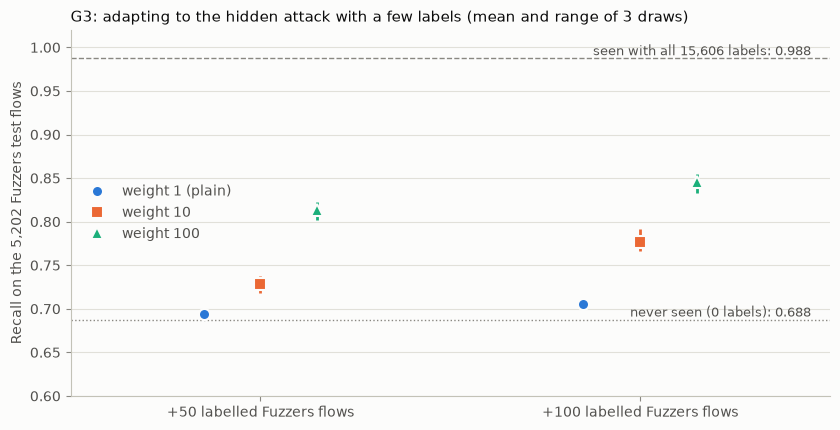

In [59]:
# STEP G3
# Figure: Fuzzers recall on the test set, from "never seen" to "seen with all labels". Dots are the
# mean of the 3 draws, the bars span the lowest and highest draw.
import matplotlib.pyplot as plt

SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
WEIGHT_STYLE = {1: ("#2a78d6", "o", "weight 1 (plain)"), 10: ("#eb6834", "s", "weight 10"),
                100: ("#1baf7a", "^", "weight 100")}
both = pd.concat([adapt_runs.assign(weight=1), weighted_runs])

fig, ax = plt.subplots(figsize=(8.5, 4.4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
seen, hidden = hidden_report(boost)["fuzzers_recall"], hidden_report(boost_hidden)["fuzzers_recall"]
ax.axhline(seen, color=MUTED, linestyle="--", linewidth=1)
ax.text(2.45, seen, f"seen with all 15,606 labels: {seen:.3f}", va="bottom", ha="right", color=INK_2, fontsize=9)
ax.axhline(hidden, color=MUTED, linestyle=":", linewidth=1)
ax.text(2.45, hidden, f"never seen (0 labels): {hidden:.3f}", va="bottom", ha="right", color=INK_2, fontsize=9)
for offset, weight in zip([-0.15, 0.0, 0.15], [1, 10, 100]):
    colour, marker, label = WEIGHT_STYLE[weight]
    for x, n in zip([1, 2], [50, 100]):
        r = both[(both["weight"] == weight) & (both["labels_added"] == n)]["fuzzers_recall"]
        ax.vlines(x + offset, r.min(), r.max(), color=colour, linewidth=2)
        ax.plot(x + offset, r.mean(), marker=marker, color=colour, markersize=8, markeredgecolor=SURFACE,
                markeredgewidth=1.5, linestyle="none", label=label if n == 50 else None)
ax.set_xticks([1, 2], ["+50 labelled Fuzzers flows", "+100 labelled Fuzzers flows"])
ax.set_xlim(0.5, 2.5)
ax.set_ylim(0.6, 1.02)
ax.set_ylabel("Recall on the 5,202 Fuzzers test flows", color=INK_2)
ax.set_title("G3: adapting to the hidden attack with a few labels (mean and range of 3 draws)",
             loc="left", fontsize=11, color=INK)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
ax.tick_params(colors=MUTED, labelcolor=INK_2)
ax.legend(loc="center left", frameon=False, labelcolor=INK_2)
fig.tight_layout()
fig.savefig(FIGURES / "G3_adapt.png", dpi=150, facecolor=SURFACE)
plt.show()

<!-- STEP G3 -->
### What adapting achieved

| Test set, mean of 3 draws (lowest to highest) | Recall on Fuzzers | Overall recall | FAR |
|---|---:|---:|---:|
| Never seen (0 labels, G2) | 0.688 | 0.888 | 0.019 |
| +50 labels | 0.694 (0.690 to 0.700) | 0.889 | 0.019 |
| +100 labels | 0.706 (0.703 to 0.712) | 0.893 | 0.019 |
| +50 labels, weight 10 | 0.729 (0.718 to 0.738) | 0.901 | 0.019 |
| +100 labels, weight 10 | 0.776 (0.766 to 0.792) | 0.917 | 0.020 |
| +50 labels, weight 100 | 0.814 (0.802 to 0.822) | 0.929 | 0.021 |
| +100 labels, weight 100 | **0.845** (0.833 to 0.854) | **0.940** | 0.022 |
| Seen with all 15,606 Fuzzers labels (B2) | 0.988 | 0.992 | 0.028 |

**Added as ordinary training flows, 50 or 100 labels barely help**: recall on Fuzzers rises from 0.688
to 0.694 and 0.706. Among 167,000 training flows, 100 new ones hardly change what the model learns.

**Given more weight, the same labels help clearly.** With each new flow counted 100 times, 100 labels
raise recall on Fuzzers to 0.845 (about 820 more fuzzing flows caught than without labels) and overall
recall to 0.940, while the false alarm rate rises only slightly (0.019 to 0.022, still below the
original model's 0.028). More labels and more weight both help, and the three draws give similar results,
so which flows the analyst labels matters little.

**But a few labels do not close the gap.** Even the best variant still misses 15% of the Fuzzers flows,
against 1% for the model trained with all of them. And the weights were not tuned (that would need
labels the analyst does not have), so 100 is a sensible guess, not an optimum. The optional extra X4 would
show how many labels are needed to come close to 0.988.

<!-- STEP G4 -->
## Part G: what we would do

**Were a few labels enough? No, but they were a good start.** Added as ordinary training flows, 50 or
100 labelled Fuzzers flows barely helped (recall on Fuzzers 0.688 to 0.706). Weighted 100 times, the same
100 labels raised it to 0.845, still well short of the 0.988 reached with all 15,606 labels, so we would
use a few weighted labels as a quick first fix and keep labelling until recall stops improving. **How would
we notice a new attack when nobody tells us?** Not from the alert count: when Fuzzers were unknown, the
false alarm rate *fell* (0.028 to 0.019) and the model raised fewer alerts, which looks like good news.
The useful signal is the model's own uncertainty, which needs no labels: the share of Fuzzers flows with
an attack probability between 0.1 and 0.9 jumped from 43% to 82%. In a real system we would therefore
watch the share of uncertain predictions and compare today's feature distributions with the training
data, have analysts label a small random sample of flows every week (including flows the model calls
benign), send uncertain flows (or BRB flows whose utility range spans the threshold, F4) to an analyst,
and retrain on a regular schedule.